# INTERP

## General

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import seaborn as sns
import os
from matplotlib import gridspec

if os.path.exists('output/ism/') is False:
    os.makedirs('output/ism/')

def visualize_crispr_data(ism_path, influence_path, 
                          ism_crop_min=None, ism_crop_max=None, 
                          inf_crop_min=None, inf_crop_max=None, 
                          delta=None, i=None):
    
    # --- Helper Function for Drawing Logos ---
    def draw_single_char(ax, char, x_pos, y_pos, height, letters, color, zorder=1):
        path = letters[char]
        trans = Affine2D().scale(0.7, height).translate(x_pos - 0.35, y_pos)
        patch = PathPatch(path, facecolor=color, edgecolor='none', 
                          linewidth=0, transform=trans + ax.transData, zorder=zorder)
        ax.add_patch(patch)

    def draw_logo_core(ax, df, x_col='Pos', cols=['> A', '> C', '> G', '> T'], is_ref=False):
        letters = {}
        for char in ['A', 'C', 'G', 'T']:
            tp = TextPath((0, 0), char, size=1)
            bbox = tp.get_extents()
            trans = Affine2D().translate(-bbox.x0, -bbox.y0).scale(1/bbox.width, 1/bbox.height)
            letters[char] = tp.transformed(trans)

        colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
        ref_col = next((c for c in ['WT', 'Ref', 'Base', 'Reference'] if c in df.columns), None)

        for _, row in df.iterrows():
            x_pos = row[x_col]
            wt_char = row[ref_col] if ref_col else None
            
            if is_ref and wt_char:
                # Reference row: scale height to 1 for a natural look
                draw_single_char(ax, wt_char, x_pos, 0, 1, letters, colors.get(wt_char, 'gray'))
            elif not is_ref:
                scores = {c[-1]: row[c] for c in cols}
                pos_scores = sorted({k: v for k, v in scores.items() if v >= 0}.items(), key=lambda x: x[1])
                neg_scores = sorted({k: v for k, v in scores.items() if v < 0}.items(), key=lambda x: abs(x[1]))
                
                def plot_stack(stack_scores, y_start):
                    curr_y = y_start
                    for char, h in stack_scores:
                        if abs(h) < 1e-6: continue
                        draw_single_char(ax, char, x_pos, curr_y, h, letters, colors[char])
                        curr_y += h
                plot_stack(pos_scores, 0)
                plot_stack(neg_scores, 0)

        ax.set_xlim(df[x_col].min() - 0.5, df[x_col].max() + 0.5)
        if is_ref:
            ax.set_ylim(0, 1)
            ax.set_yticks([]) 
            for spine in ax.spines.values():
                spine.set_visible(False)
        ax.autoscale_view()

    # --- 1. Process ISM ---
    print(f"Processing ISM file: {ism_path}")
    df_ism = pd.read_csv(ism_path)
    score_cols = ['> A', '> C', '> G', '> T']
    
    means = df_ism[score_cols].mean(axis=1)
    df_norm = df_ism.copy()
    for col in score_cols:
        df_norm[col] = df_ism[col] - means

    if ism_crop_min is not None and ism_crop_max is not None:
        mask_min = df_norm['Pos'] >= ism_crop_min
        mask_max = df_norm['Pos'] < ism_crop_max
        if mask_min.any() and mask_max.any():
            start_row = df_norm[mask_min].index[0]
            end_row = df_norm[mask_max].index[-1] + 1
            df_norm = df_norm.iloc[start_row:end_row]
    
    # Setup Figure with GridSpec - Height ratio [0.5, 4] flattens the reference row
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.3, 2.28], hspace=0.05)
    
    ax_ref = fig.add_subplot(gs[0])
    ax_ism = fig.add_subplot(gs[1])

    draw_logo_core(ax_ref, df_norm, is_ref=True)
    draw_logo_core(ax_ism, df_norm, is_ref=False)
    
    # Label for Reference row - Horizontal and bold
    ax_ref.set_ylabel("Ref.", rotation=0, fontsize=20, labelpad=40, va='center')
    ax_ref.set_xticks([])
    
    # Baseline for scores
    ax_ism.axhline(0, color='black', linewidth=0.8, zorder=0)
    
    # Cut site indicator
    cut_pos = 46.5
    ax_ism.axvline(x=cut_pos, color='black', linestyle='--', linewidth=2, label='Cut Site')
    
    ax_ism.set_xlabel("Position", fontsize=20)
    ax_ism.set_ylabel("ISM score", fontsize=20)
    
    plt.savefig(f'output/ism/ism_logo_delta_{delta}_run_{i}.svg', bbox_inches='tight')
    plt.show()
    plt.close()
    
    # --- 2. Process Influence Map (Heatmap) ---
    print(f"Processing Influence file: {influence_path}")
    df_inf = pd.read_csv(influence_path)
    if inf_crop_min is not None and inf_crop_max is not None:
        df_inf = df_inf.iloc[inf_crop_min:inf_crop_max, inf_crop_min:inf_crop_max]
    
    grid_kws = {"height_ratios": (.083, .917), "hspace": .3}
    f, (ax_cbar, ax_heatmap) = plt.subplots(2, gridspec_kw=grid_kws, figsize=(10, 6))
    sns.heatmap(df_inf, ax=ax_heatmap, cbar_ax=ax_cbar, cmap='coolwarm', center=0, 
                xticklabels=True, yticklabels=True,
                cbar_kws={'label': 'Pairwise interaction score', 'orientation': 'horizontal'})
    
    ax_cbar.set_xlabel('Pairwise interaction score', fontsize=30, labelpad=10)
    ax_cbar.xaxis.set_label_position('top') 
    ax_cbar.tick_params(labelsize=14)

    def format_ticks(ax_target, axis_type='x'):
        ax_target.tick_params(axis=axis_type, labelsize=18)
        labels = ax_target.get_xticklabels() if axis_type == 'x' else ax_target.get_yticklabels()
        for n, label in enumerate(labels):
            try:
                val = int(label.get_text())
                if val % 5 != 0: label.set_visible(False)
            except ValueError:
                if n % 5 != 0: label.set_visible(False)

    format_ticks(ax_heatmap, 'x')
    format_ticks(ax_heatmap, 'y')
    ax_heatmap.tick_params(axis='both', which='major', length=4)
    plt.tight_layout()
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}.svg', bbox_inches='tight')
    plt.show()
    plt.close()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import seaborn as sns
import os

if os.path.exists('output/ism/') is False:
    os.makedirs('output/ism/')

def visualize_crispr_data_wide(ism_path, influence_path, 
                          ism_crop_min=None, ism_crop_max=None, 
                          inf_crop_min=None, inf_crop_max=None, 
                          delta=None, i=None):
    
    # --- Helper Function for Drawing Logos ---
    def draw_logo(ax, df, x_col='Pos', cols=['> A', '> C', '> G', '> T']):
        letters = {}
        for char in ['A', 'C', 'G', 'T']:
            tp = TextPath((0, 0), char, size=1)
            bbox = tp.get_extents()
            trans = Affine2D().translate(-bbox.x0, -bbox.y0).scale(1/bbox.width, 1/bbox.height)
            letters[char] = tp.transformed(trans)

        colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
        ref_col = next((c for c in ['WT', 'Ref', 'Base', 'Reference'] if c in df.columns), None)

        for idx, row in df.iterrows():
            x_pos = row[x_col]
            scores = {c[-1]: row[c] for c in cols}
            wt_char = row[ref_col] if ref_col else None
            
            pos_scores = sorted({k: v for k, v in scores.items() if v >= 0}.items(), key=lambda x: x[1])
            neg_scores = sorted({k: v for k, v in scores.items() if v < 0}.items(), key=lambda x: abs(x[1]))
            
            def plot_stack(stack_scores, y_start):
                curr_y = y_start
                for char, h in stack_scores:
                    if abs(h) < 1e-6: continue
                    if wt_char and char == wt_char:
                        linewidth = 1.0; edgecolor = 'black'; zorder = 10
                    else:
                        linewidth = 0; edgecolor = 'none'; zorder = 1
                    path = letters[char]
                    # Original 0.7 scale and 0.35 offset
                    trans = Affine2D().scale(0.7, h).translate(x_pos - 0.35, curr_y)
                    patch = PathPatch(path, facecolor=colors[char], edgecolor=edgecolor, linewidth=linewidth, transform=trans + ax.transData, zorder=zorder)
                    ax.add_patch(patch)
                    curr_y += h
            plot_stack(pos_scores, 0)
            plot_stack(neg_scores, 0)
                
        ax.set_xlim(df[x_col].min() - 0.5, df[x_col].max() + 0.5)
        ax.autoscale_view()

    # --- 1. Process ISM ---
    print(f"Processing ISM: {ism_path}")
    df_ism = pd.read_csv(ism_path)
    score_cols = ['> A', '> C', '> G', '> T']
    means = df_ism[score_cols].mean(axis=1)
    df_norm = df_ism.copy()
    for col in score_cols:
        df_norm[col] = df_ism[col] - means

    # Determine visible range
    if ism_crop_min is not None and ism_crop_max is not None:
        mask = (df_norm['Pos'] >= ism_crop_min) & (df_norm['Pos'] < ism_crop_max)
        df_logo = df_norm[mask].copy()
    else:
        df_logo = df_norm.copy()

    visible_pos = df_logo['Pos'].astype(int).tolist()
        
    # LOGO FIGURE: Original 20x6
    fig, ax = plt.subplots(figsize=(20, 6)) 
    draw_logo(ax, df_logo)
    
    ax.axvline(x=46.5, color='black', linestyle='--', linewidth=2)
    
    # BIGGER FONTS (Original)
    ax.set_xlabel("Position", fontsize=22, fontweight='bold')
    ax.set_ylabel("ISM score", fontsize=22, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    plt.tight_layout()
    plt.savefig(f'output/ism/ism_logo_delta_{delta}_run_{i}_wide.pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    
    # --- 2. Process Influence Map ---
    print(f"Processing Influence: {influence_path}")
    df_inf = pd.read_csv(influence_path)
    
    # Align matrix to biological positions
    if "Unnamed" in df_inf.columns[0] or df_inf.columns[0] == "":
        df_inf = df_inf.set_index(df_inf.columns[0])
    
    # Cast headers to int for label-based reindexing
    df_inf.columns = df_inf.columns.astype(float).astype(int)
    df_inf.index = df_inf.index.astype(float).astype(int)
    
    # CROP THE MATRIX: Use reindex to match the visible logo exactly
    df_inf_cropped = df_inf.reindex(index=visible_pos, columns=visible_pos)

    # HEATMAP FIGURE: Original 12x12
    grid_kws = {"height_ratios": (.05, .95), "hspace": .3}
    f, (ax_cbar, ax_heatmap) = plt.subplots(2, gridspec_kw=grid_kws, figsize=(12, 12))
    
    sns.heatmap(df_inf_cropped, ax=ax_heatmap, cbar_ax=ax_cbar, 
                cmap='coolwarm', center=0, 
                xticklabels=True, yticklabels=True,
                cbar_kws={'label': 'Pairwise interaction score', 'orientation': 'horizontal'})
    
    # BIGGER FONTS (Original)
    ax_heatmap.set_xlabel('Position', fontsize=22, fontweight='bold', labelpad=15)
    ax_heatmap.set_ylabel('Position', fontsize=22, fontweight='bold', labelpad=15)
    
    ax_cbar.set_xlabel('Pairwise interaction score', fontsize=20, fontweight='bold', labelpad=10)
    ax_cbar.xaxis.set_label_position('top') 
    ax_cbar.tick_params(labelsize=16)

    def format_ticks(ax_target, axis_type='x'):
        ax_target.tick_params(axis=axis_type, labelsize=18) 
        labels = ax_target.get_xticklabels() if axis_type == 'x' else ax_target.get_yticklabels()
        for n, label in enumerate(labels):
            try:
                val = int(float(label.get_text()))
                if val % 5 != 0: label.set_visible(False)
            except:
                if n % 5 != 0: label.set_visible(False)

    format_ticks(ax_heatmap, 'x')
    format_ticks(ax_heatmap, 'y')
    ax_heatmap.tick_params(axis='both', which='major', length=6)
    
    plt.tight_layout()
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}_wide.pdf', bbox_inches='tight')
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}_wide.svg', bbox_inches='tight')
    plt.show()
    plt.close()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import seaborn as sns
import os
from matplotlib.colors import LinearSegmentedColormap

if os.path.exists('output/ism/') is False:
    os.makedirs('output/ism/')

def visualize_crispr_combined_aligned(ism_path, influence_path, 
                                      ism_crop_min=None, ism_crop_max=None, 
                                      delta=None, i=None):
    
    # --- 1. Load and Process Data ---
    df_ism = pd.read_csv(ism_path)
    score_cols = ['> A', '> C', '> G', '> T']
    means = df_ism[score_cols].mean(axis=1)
    df_norm = df_ism.copy()
    for col in score_cols:
        df_norm[col] = df_ism[col] - means

    if ism_crop_min is not None and ism_crop_max is not None:
        mask = (df_norm['Pos'] >= ism_crop_min) & (df_norm['Pos'] < ism_crop_max)
        df_logo = df_norm[mask].copy()
    else:
        df_logo = df_norm.copy()

    visible_pos = df_logo['Pos'].astype(int).tolist()
    
    df_inf = pd.read_csv(influence_path)
    if "Unnamed" in df_inf.columns[0] or df_inf.columns[0] == "":
        df_inf = df_inf.set_index(df_inf.columns[0])
    
    df_inf.columns = df_inf.columns.astype(float).astype(int)
    df_inf.index = df_inf.index.astype(float).astype(int)
    df_inf_cropped = df_inf.reindex(index=visible_pos, columns=visible_pos)

    # --- 2. Build Unified Plot ---
    fig = plt.figure(figsize=(20, 20))
    
    # Updated GridSpec: 7 rows to allow distinct gaps
    # Row 1 (0.003): Teeny gap between Ref and Logo
    # Row 3 (0.05): Original distance between Logo and Heatmap
    gs = fig.add_gridspec(7, 1, height_ratios=[0.015, 0.003, 0.15, 0.005, 0.62, 0.1, 0.04], hspace=0)
    
    ax_ref = fig.add_subplot(gs[0]) 
    ax_logo = fig.add_subplot(gs[2], sharex=ax_ref) 
    ax_heatmap = fig.add_subplot(gs[4], sharex=ax_logo)
    ax_cbar = fig.add_subplot(gs[6])

    # --- 3. Draw Logo with Positive and Negative Stacks ---
    def draw_logo_aligned(ax_ref, ax_logo, df, visible_pos_list):
        letters = {}
        for char in ['A', 'C', 'G', 'T']:
            tp = TextPath((0, 0), char, size=1)
            bbox = tp.get_extents()
            trans = Affine2D().translate(-bbox.x0, -bbox.y0).scale(1/bbox.width, 1/bbox.height)
            letters[char] = tp.transformed(trans)

        colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
        ref_col = next((c for c in ['WT', 'Ref', 'Base', 'Reference'] if c in df.columns), None)
        pos_to_idx = {pos: idx for idx, pos in enumerate(visible_pos_list)}

        for _, row in df.iterrows():
            x_idx = pos_to_idx[int(row['Pos'])]
            scores = {c[-1]: row[c] for c in score_cols}
            wt_char = row[ref_col] if ref_col else None
            
            if wt_char:
                trans_ref = Affine2D().scale(0.85, 1.0).translate(x_idx + 0.075, 0)
                patch_ref = PathPatch(letters[wt_char], facecolor=colors.get(wt_char, 'gray'), edgecolor='none', transform=trans_ref + ax_ref.transData, zorder=10)
                ax_ref.add_patch(patch_ref)

            pos_scores = sorted({k: v for k, v in scores.items() if v >= 0}.items(), key=lambda x: x[1])
            neg_scores = sorted({k: v for k, v in scores.items() if v < 0}.items(), key=lambda x: abs(x[1]))
            
            def plot_stack(stack_scores, y_start):
                curr_y = y_start
                for char, h in stack_scores:
                    if abs(h) < 1e-6: continue
                    lw = 1.2 if wt_char and char == wt_char else 0
                    ec = 'none'
                    trans = Affine2D().scale(0.85, h).translate(x_idx + 0.075, curr_y)
                    patch = PathPatch(letters[char], facecolor=colors[char], edgecolor=ec, linewidth=lw, transform=trans + ax_logo.transData, zorder=10)
                    ax_logo.add_patch(patch)
                    curr_y += h

            plot_stack(pos_scores, 0)
            plot_stack(neg_scores, 0)

    draw_logo_aligned(ax_ref, ax_logo, df_logo, visible_pos)
    
    biological_cut_site = 46.5
    relative_cut_site = biological_cut_site - visible_pos[0] + 0.5
    
    ax_logo.axvline(x=relative_cut_site, color='black', linestyle='--', linewidth=3)
    ax_logo.axhline(0, color='black', linewidth=1, alpha=0.7)
    
    y_max = df_logo[score_cols].apply(lambda x: x[x > 0].sum(), axis=1).max()
    y_min = df_logo[score_cols].apply(lambda x: x[x < 0].sum(), axis=1).min()
    padding = max(abs(y_max), abs(y_min)) * 0.1
    ax_logo.set_ylim(y_min - padding, y_max + padding)

    # Format ax_ref (Reference row)
    ax_ref.set_ylim(0, 1)
    ax_ref.set_yticks([])
    ax_ref.set_ylabel("Ref.", rotation=0, fontsize=22, fontweight='bold', labelpad=40, va='center')
    ax_ref.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    for spine in ax_ref.spines.values(): spine.set_visible(False)

    ax_logo.set_ylabel("ISM score", fontsize=22, fontweight='bold')
    ax_logo.tick_params(axis='y', labelsize=18)
    ax_logo.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # --- 4. Draw Heatmap ---
    colors_cmap = ["#FFFFFF", "red"] 
    custom_cmap = LinearSegmentedColormap.from_list("white_red", colors_cmap)
    v_max = df_inf_cropped.max().max()

    sns.heatmap(df_inf_cropped, ax=ax_heatmap, cbar_ax=ax_cbar, 
                cmap=custom_cmap, 
                vmin=0, vmax=v_max,
                xticklabels=True, yticklabels=True,
                cbar_kws={'orientation': 'horizontal'})
    
    ax_heatmap.axvline(x=relative_cut_site, color='black', linestyle='--', linewidth=3)
    ax_heatmap.set_xlabel('Position', fontsize=22, fontweight='bold', labelpad=15)
    ax_heatmap.set_ylabel('Position', fontsize=22, fontweight='bold', labelpad=15)
    
    ax_cbar.set_xlabel('Pairwise interaction score', fontsize=22, fontweight='bold', labelpad=15)
    ax_cbar.tick_params(labelsize=18)

    # --- 5. Ticks and Formatting ---
    ax_heatmap.set_xlim(0, len(visible_pos))
    
    def format_ticks(ax_target):
        ax_target.tick_params(axis='both', labelsize=18, length=6)
        for axis_name in ['x', 'y']:
            labels = ax_target.get_xticklabels() if axis_name == 'x' else ax_target.get_yticklabels()
            for label in labels:
                try:
                    val = int(float(label.get_text()))
                    if val % 5 != 0: label.set_visible(False)
                except: pass

    format_ticks(ax_heatmap)

    plt.subplots_adjust(bottom=0.15) 
    
    plt.savefig(f'output/ism/combined_aligned_v2_delta_{delta}_run_{i}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_1.csv


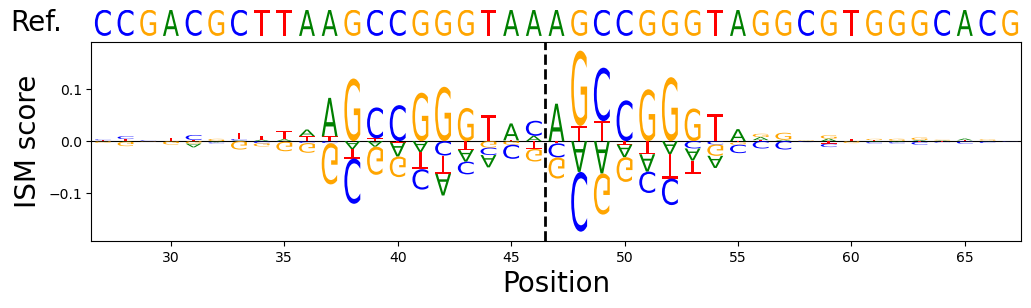

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_30412\906599447.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


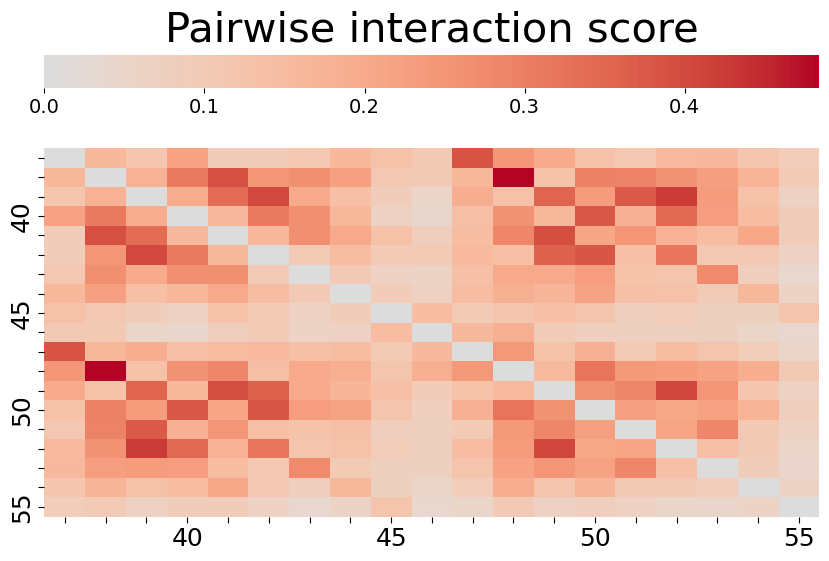

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_2.csv


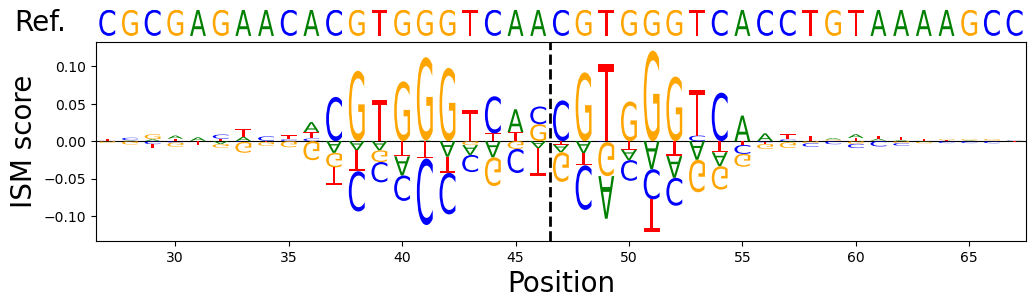

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_30412\906599447.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


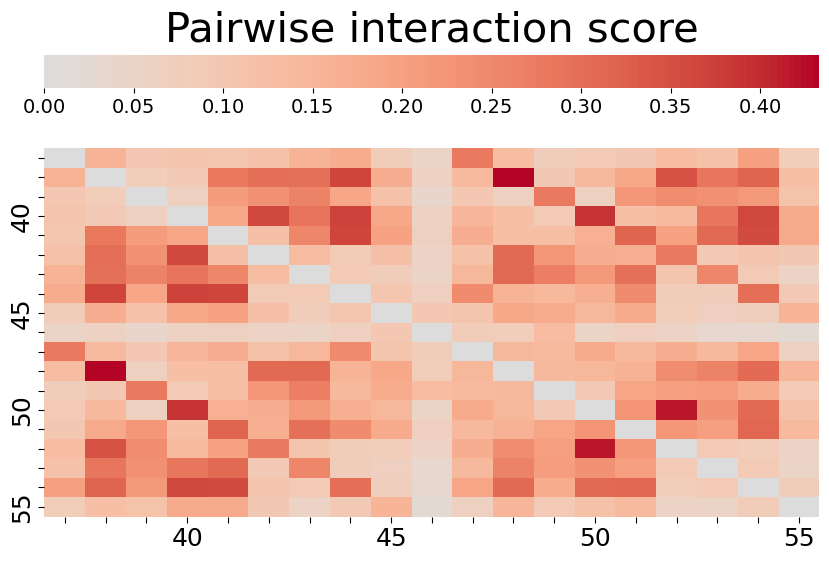

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_3.csv


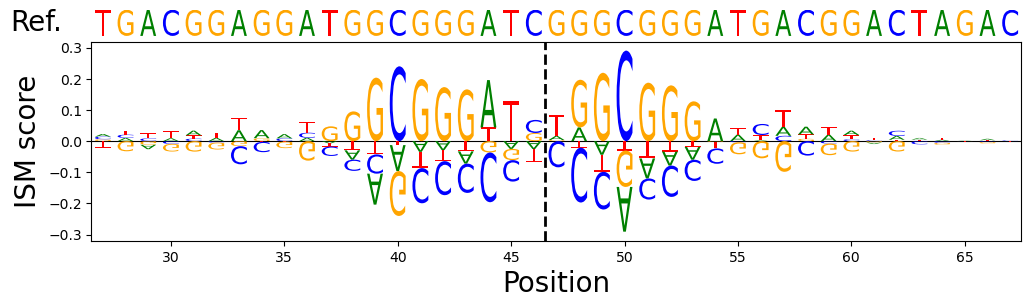

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_30412\906599447.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


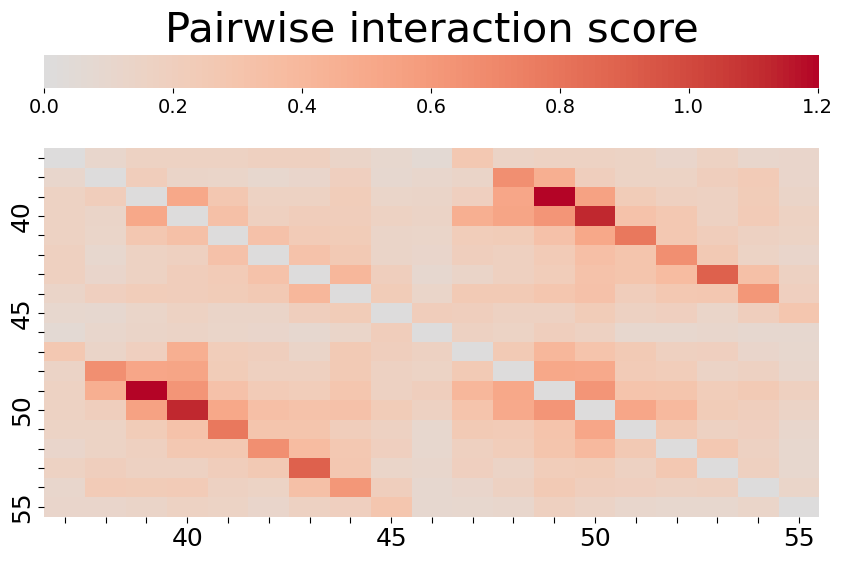

ISM and Influence Map Visualization Run: 1


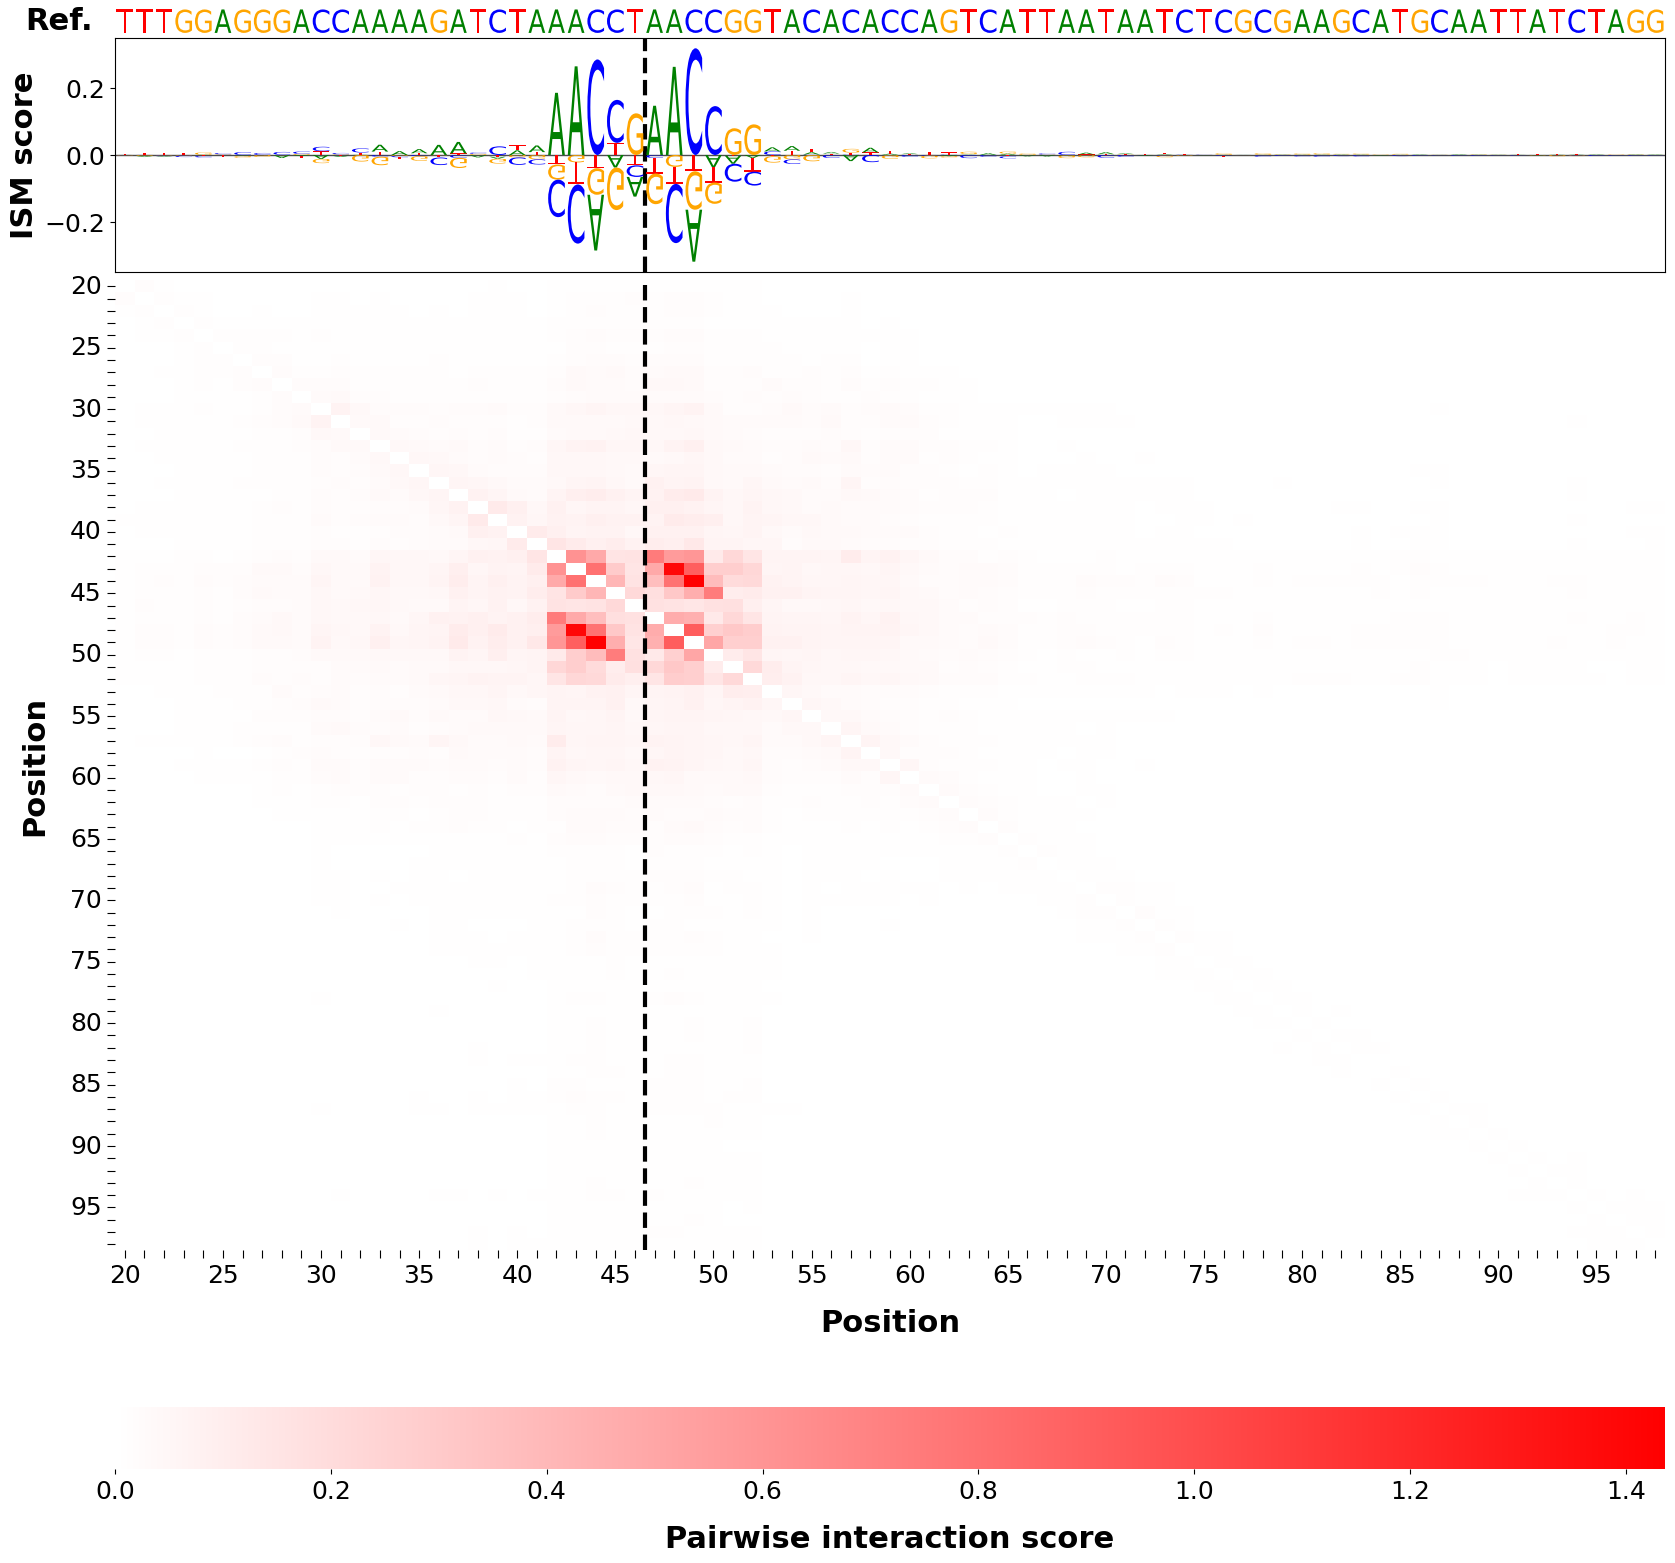

ISM and Influence Map Visualization Run: 2


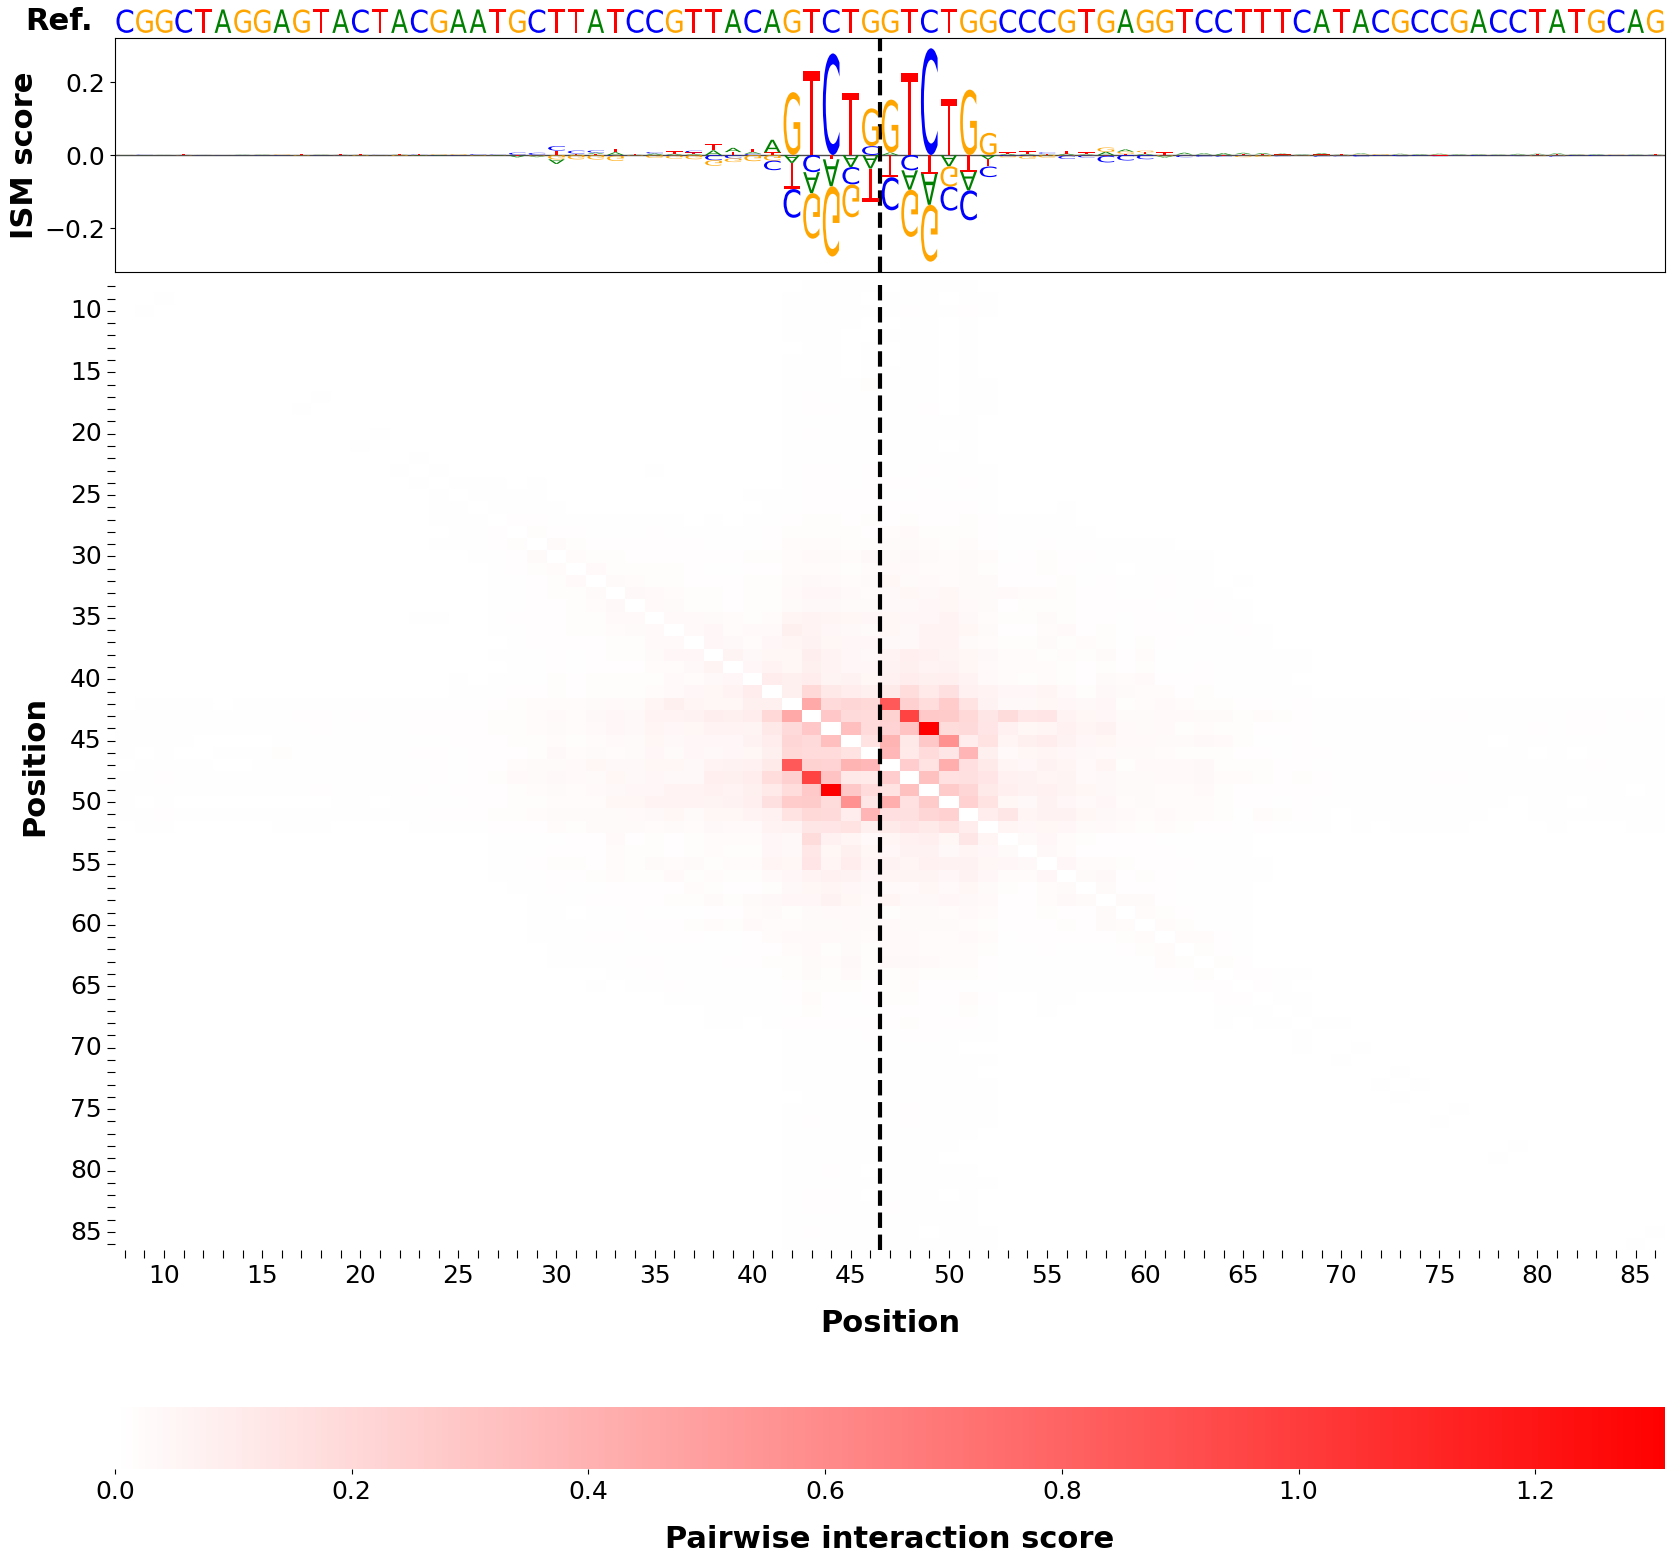

ISM and Influence Map Visualization Run: 3


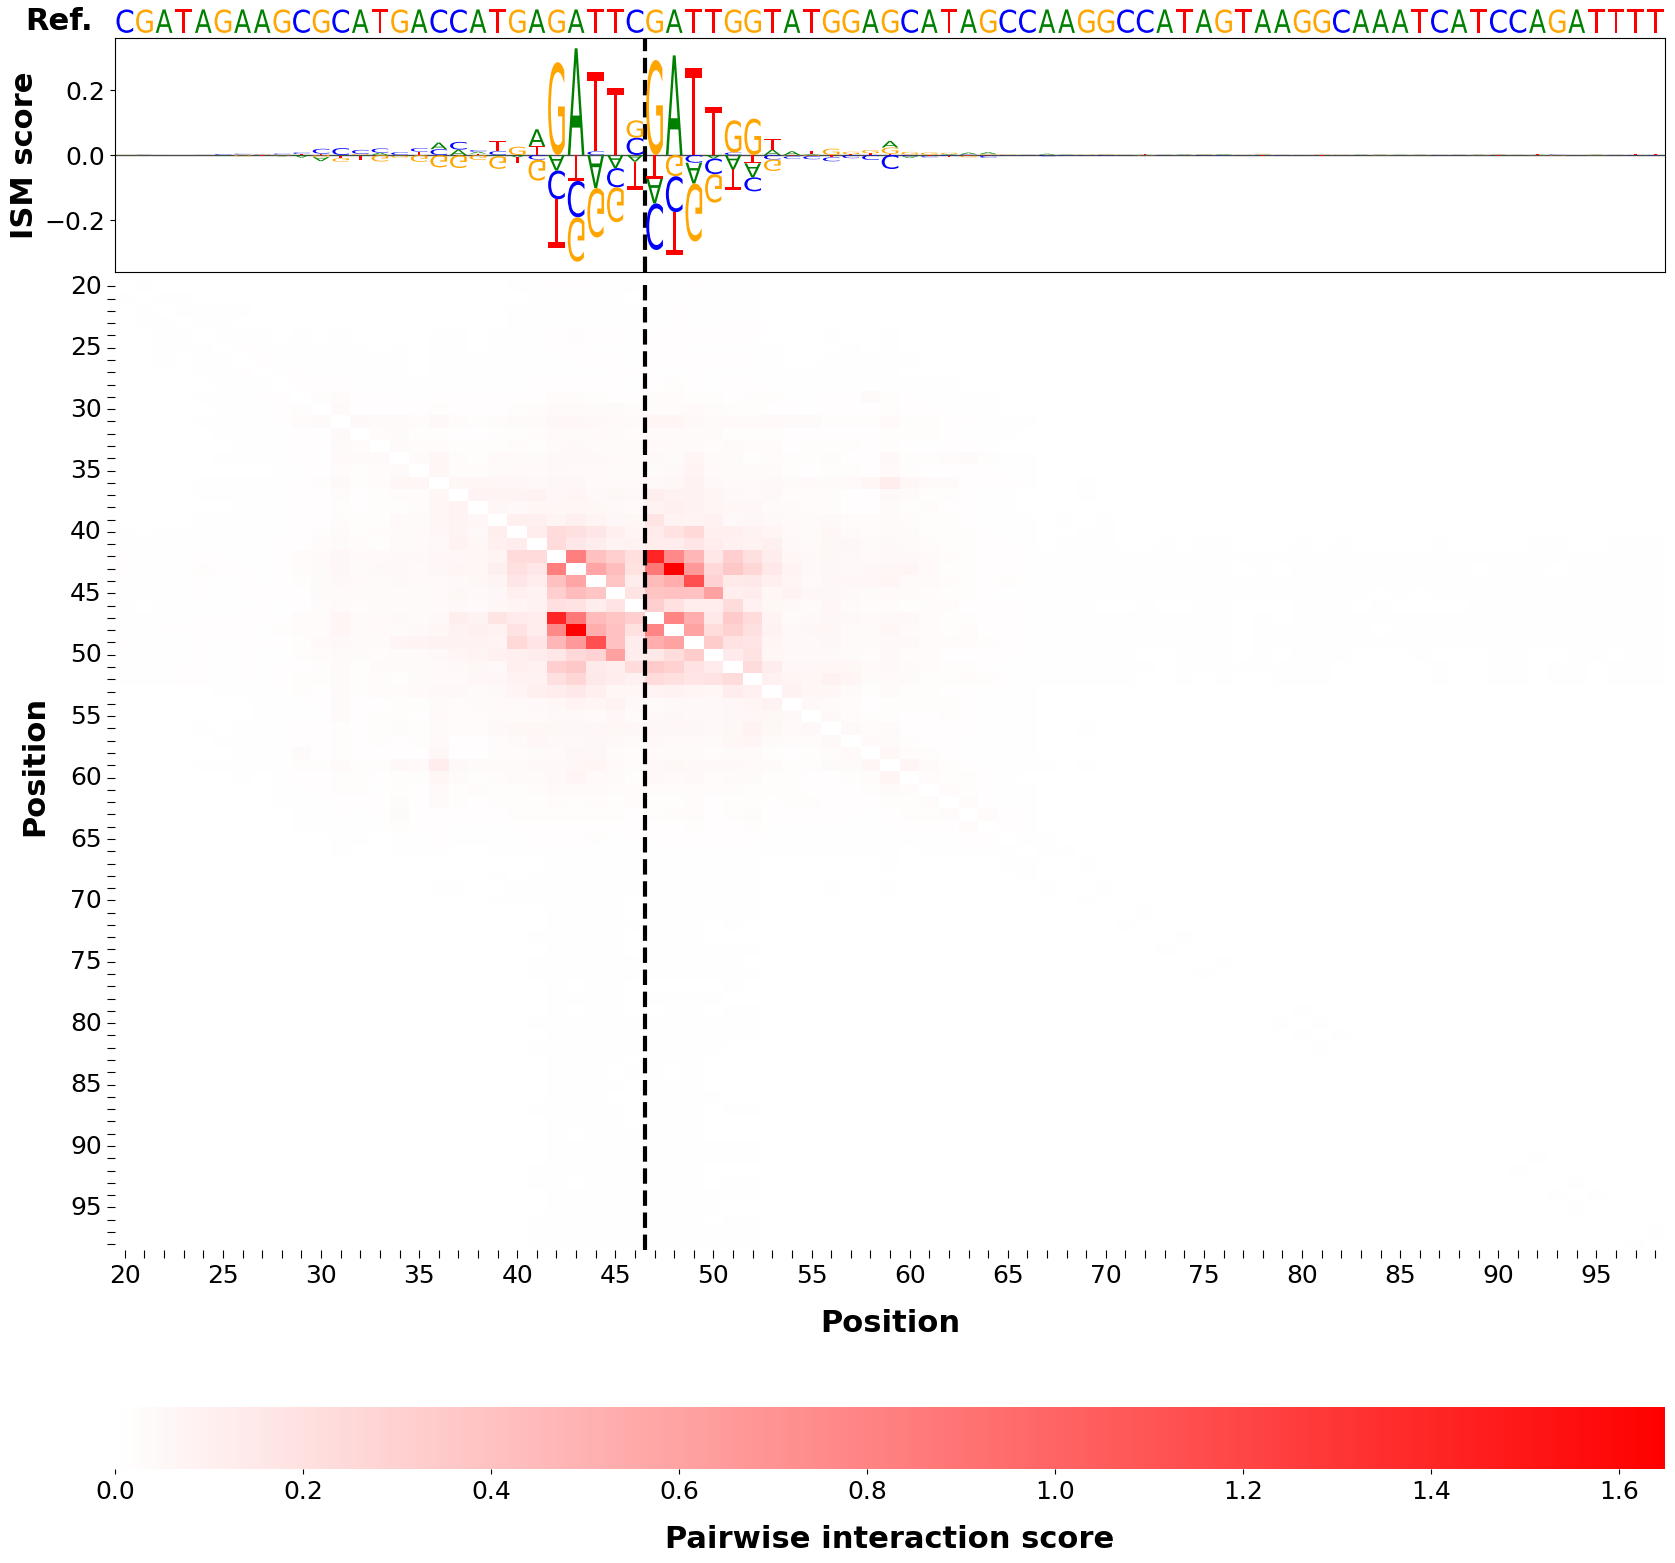

ISM and Influence Map Visualization Run: 1


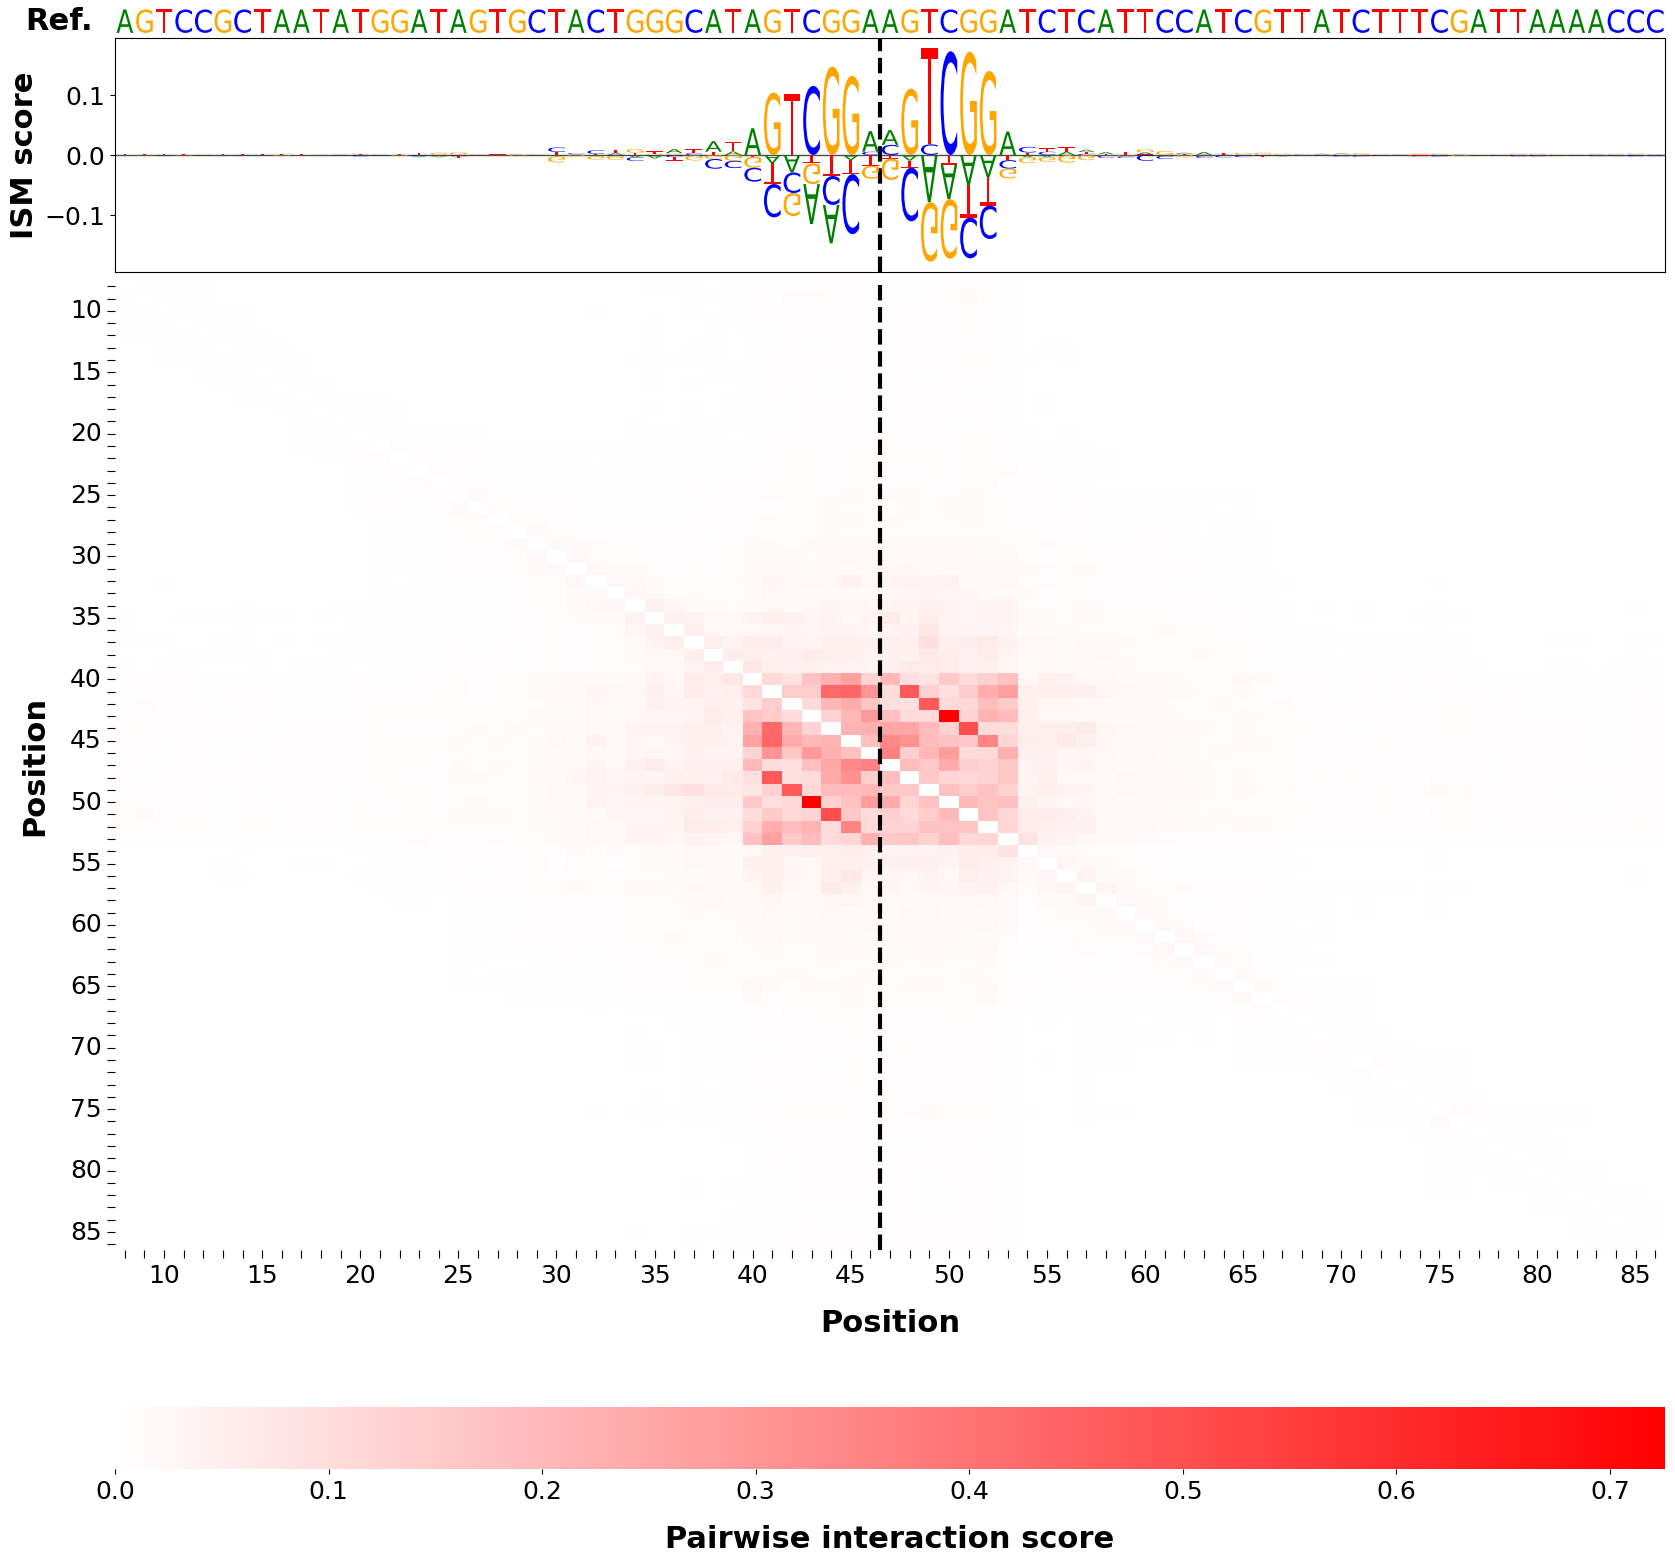

ISM and Influence Map Visualization Run: 2


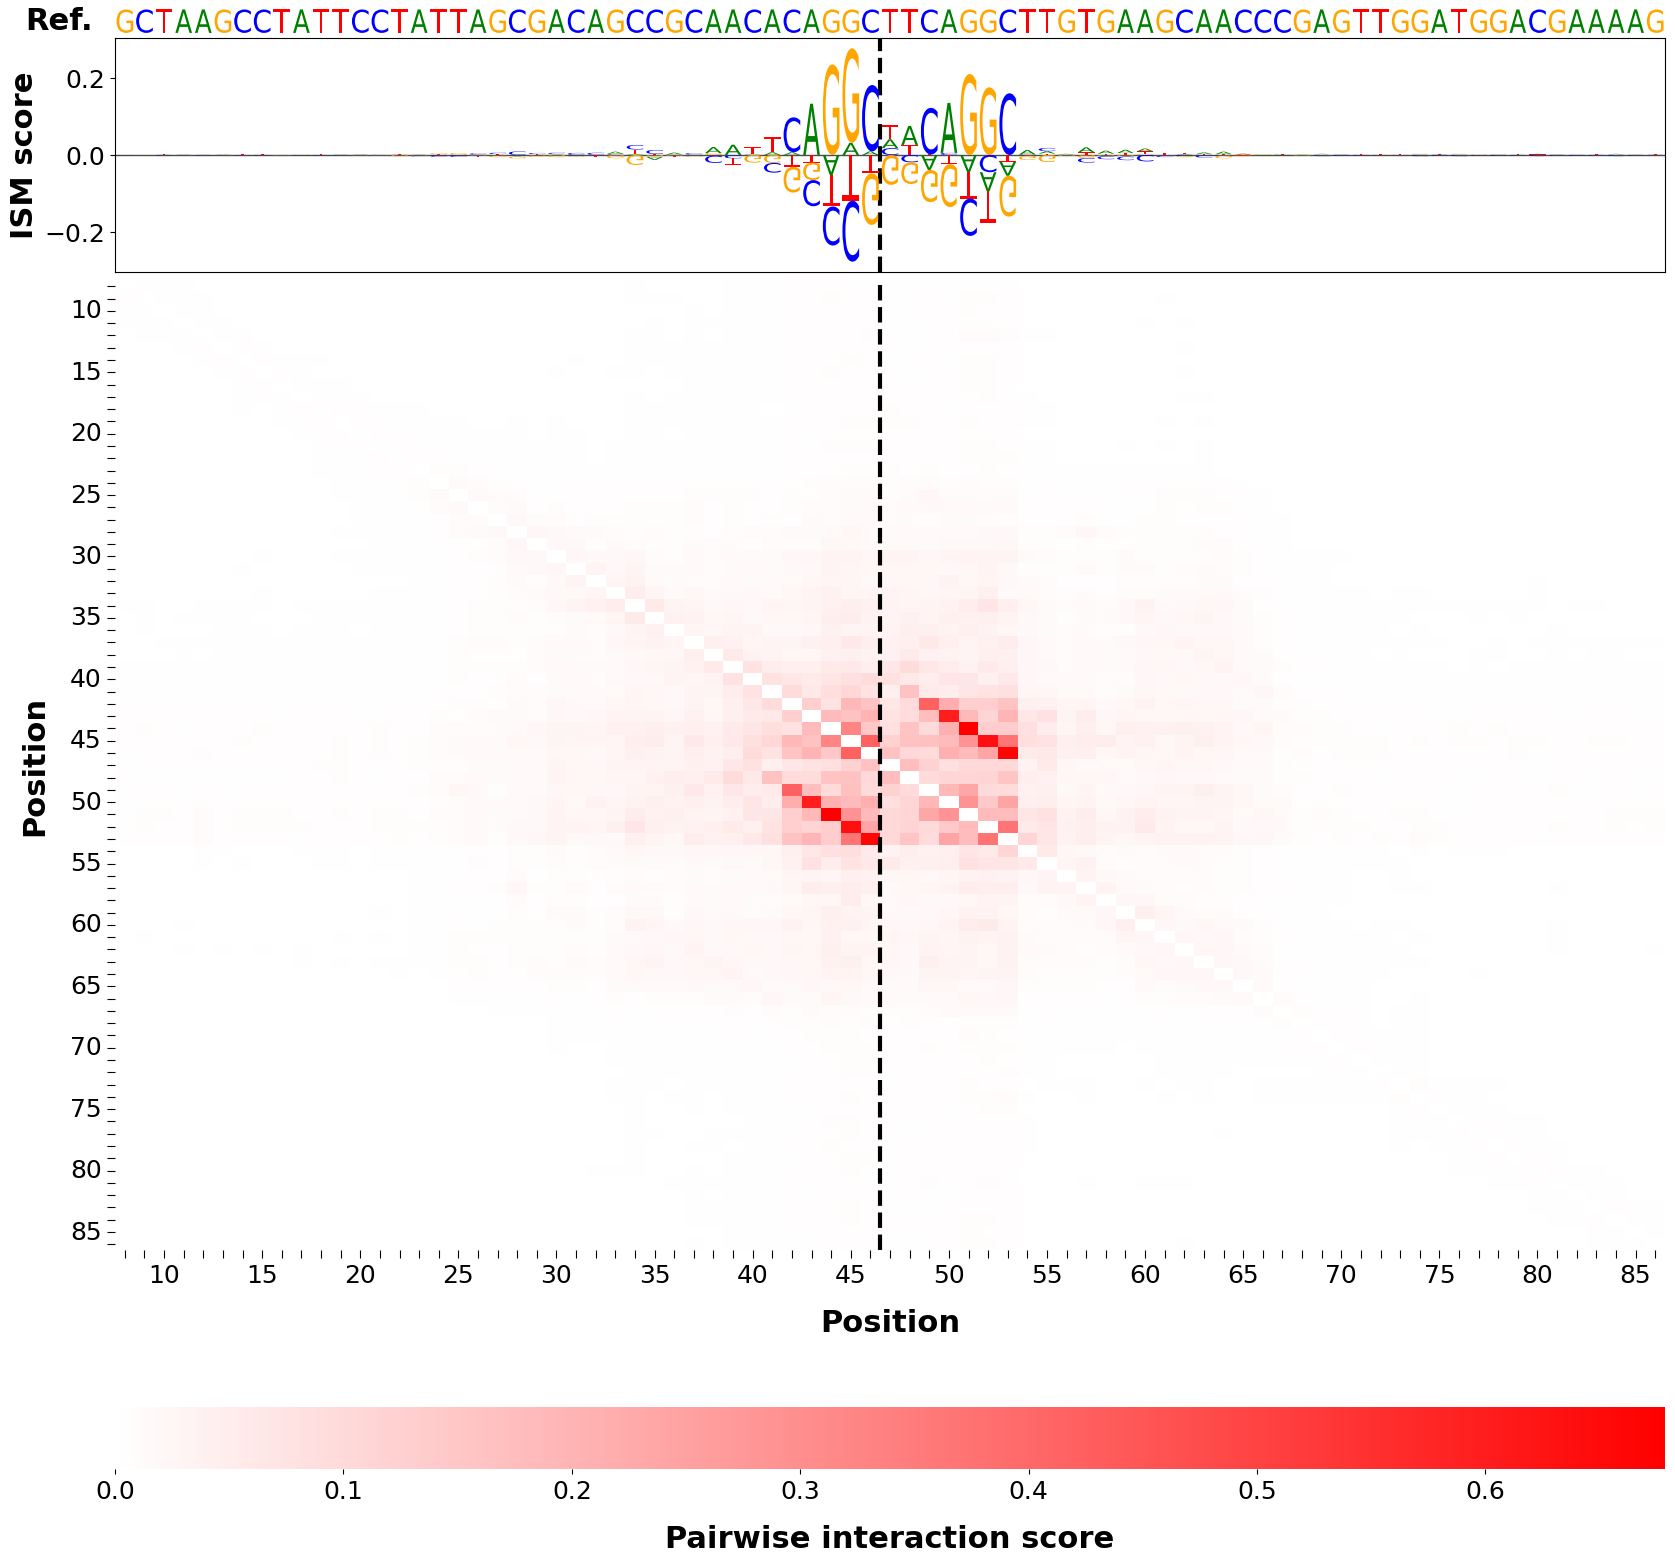

ISM and Influence Map Visualization Run: 3


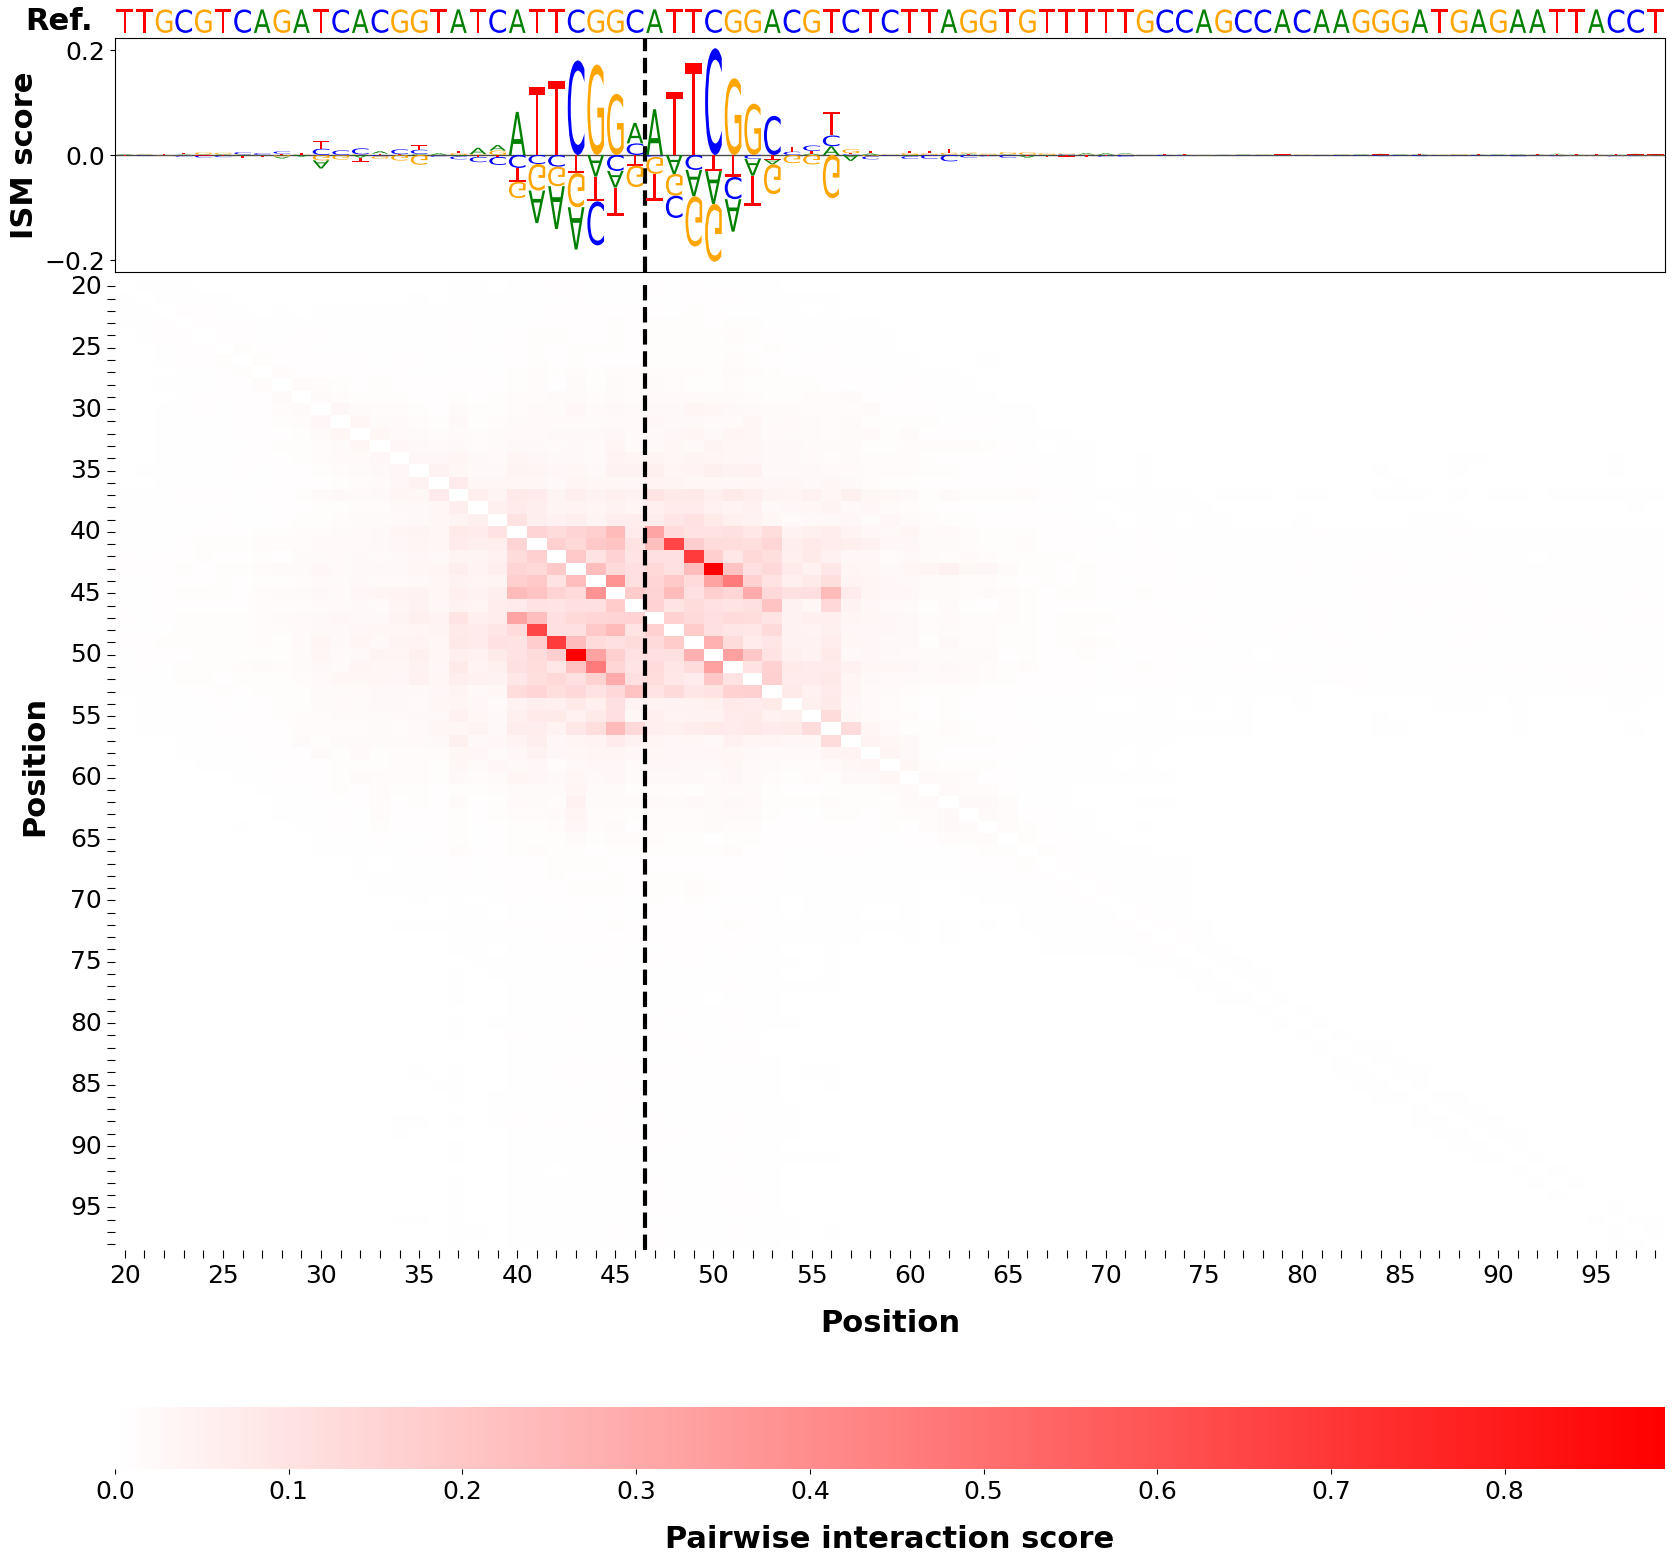

ISM and Influence Map Visualization Run: 1


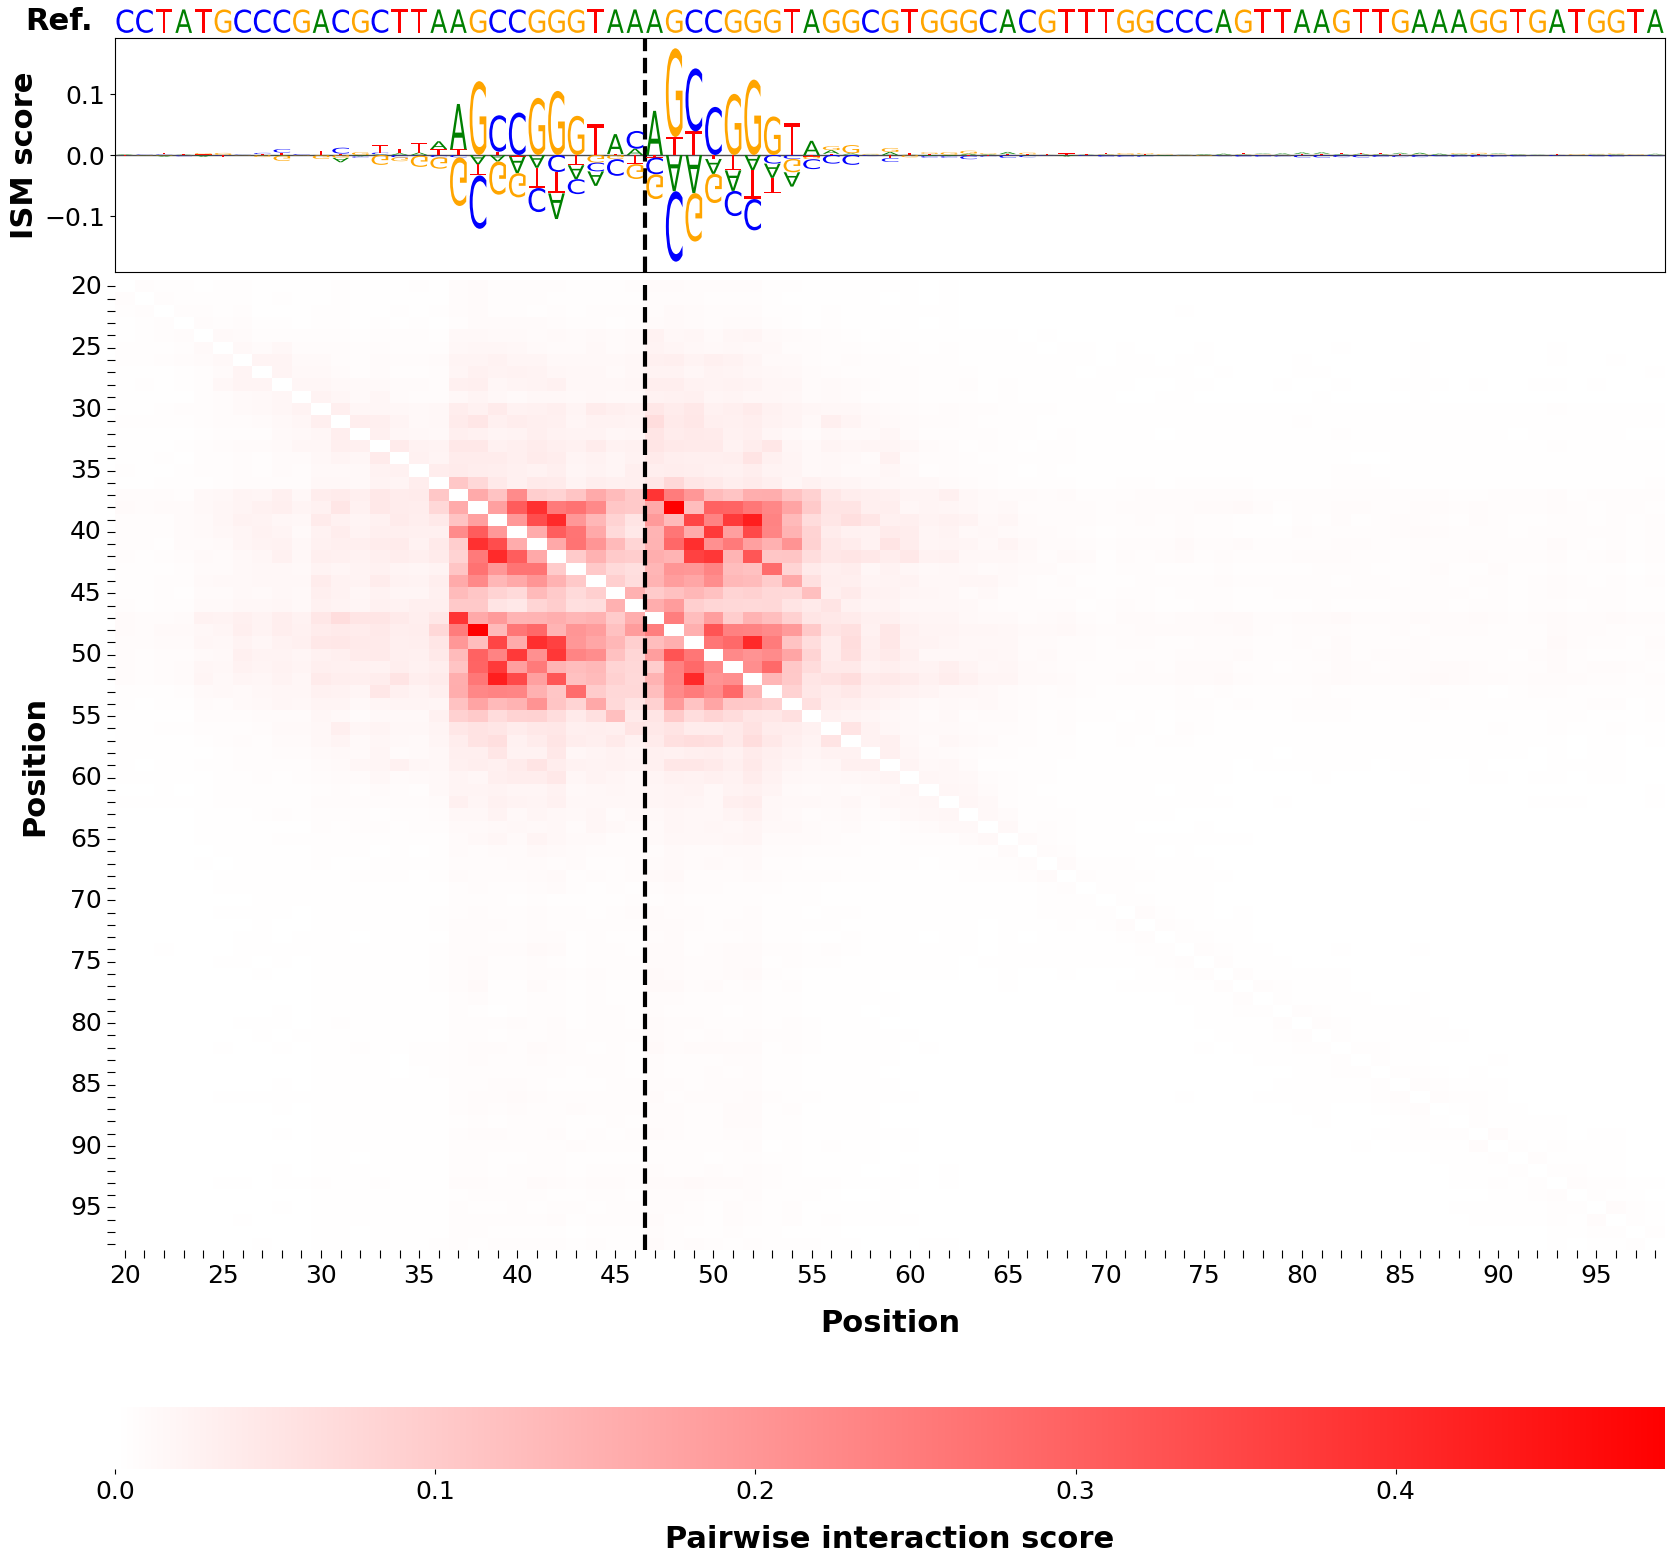

ISM and Influence Map Visualization Run: 2


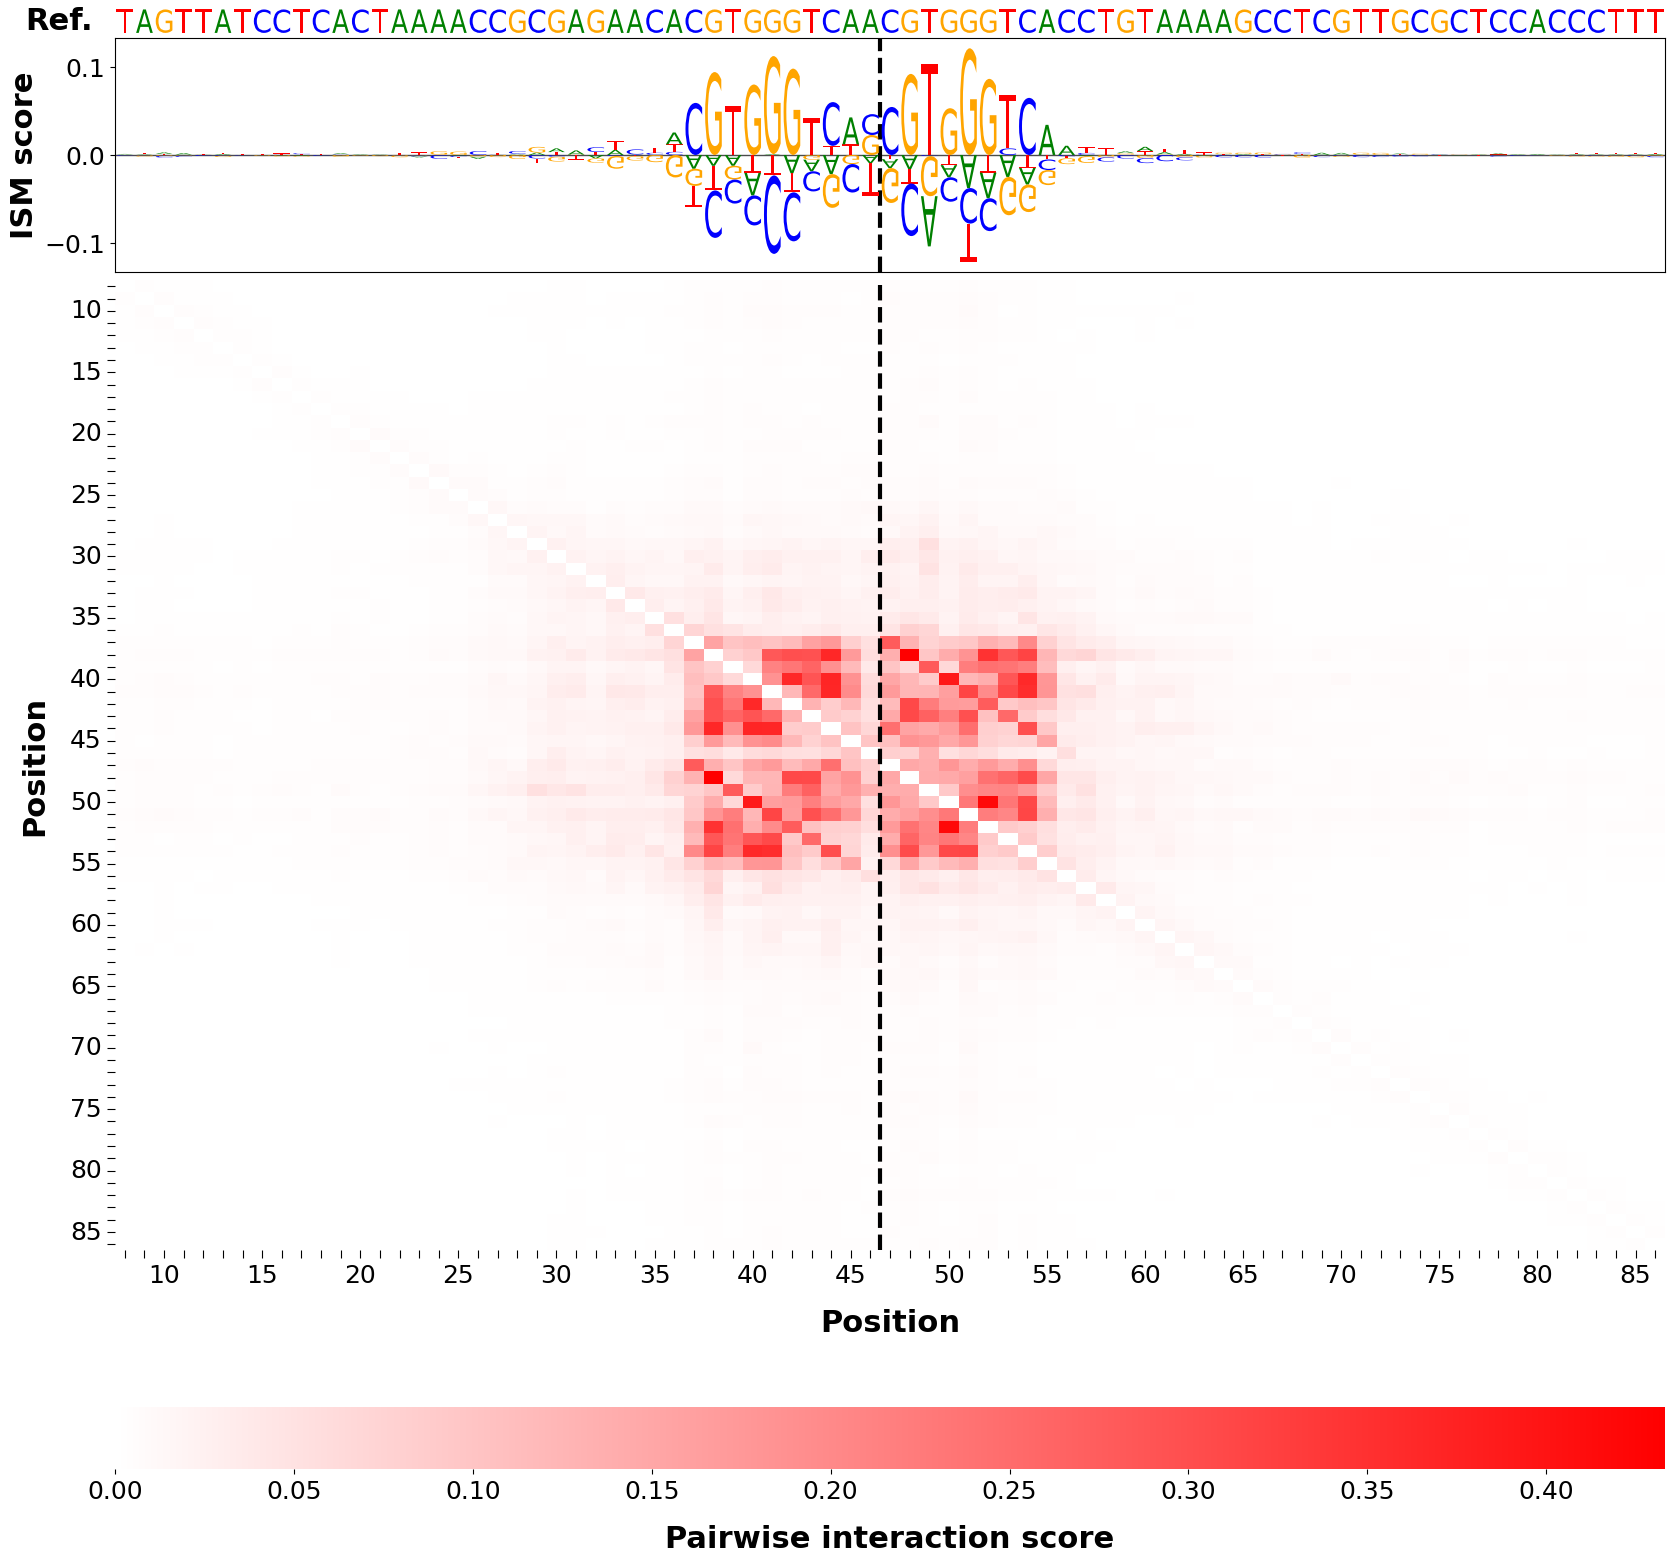

ISM and Influence Map Visualization Run: 3


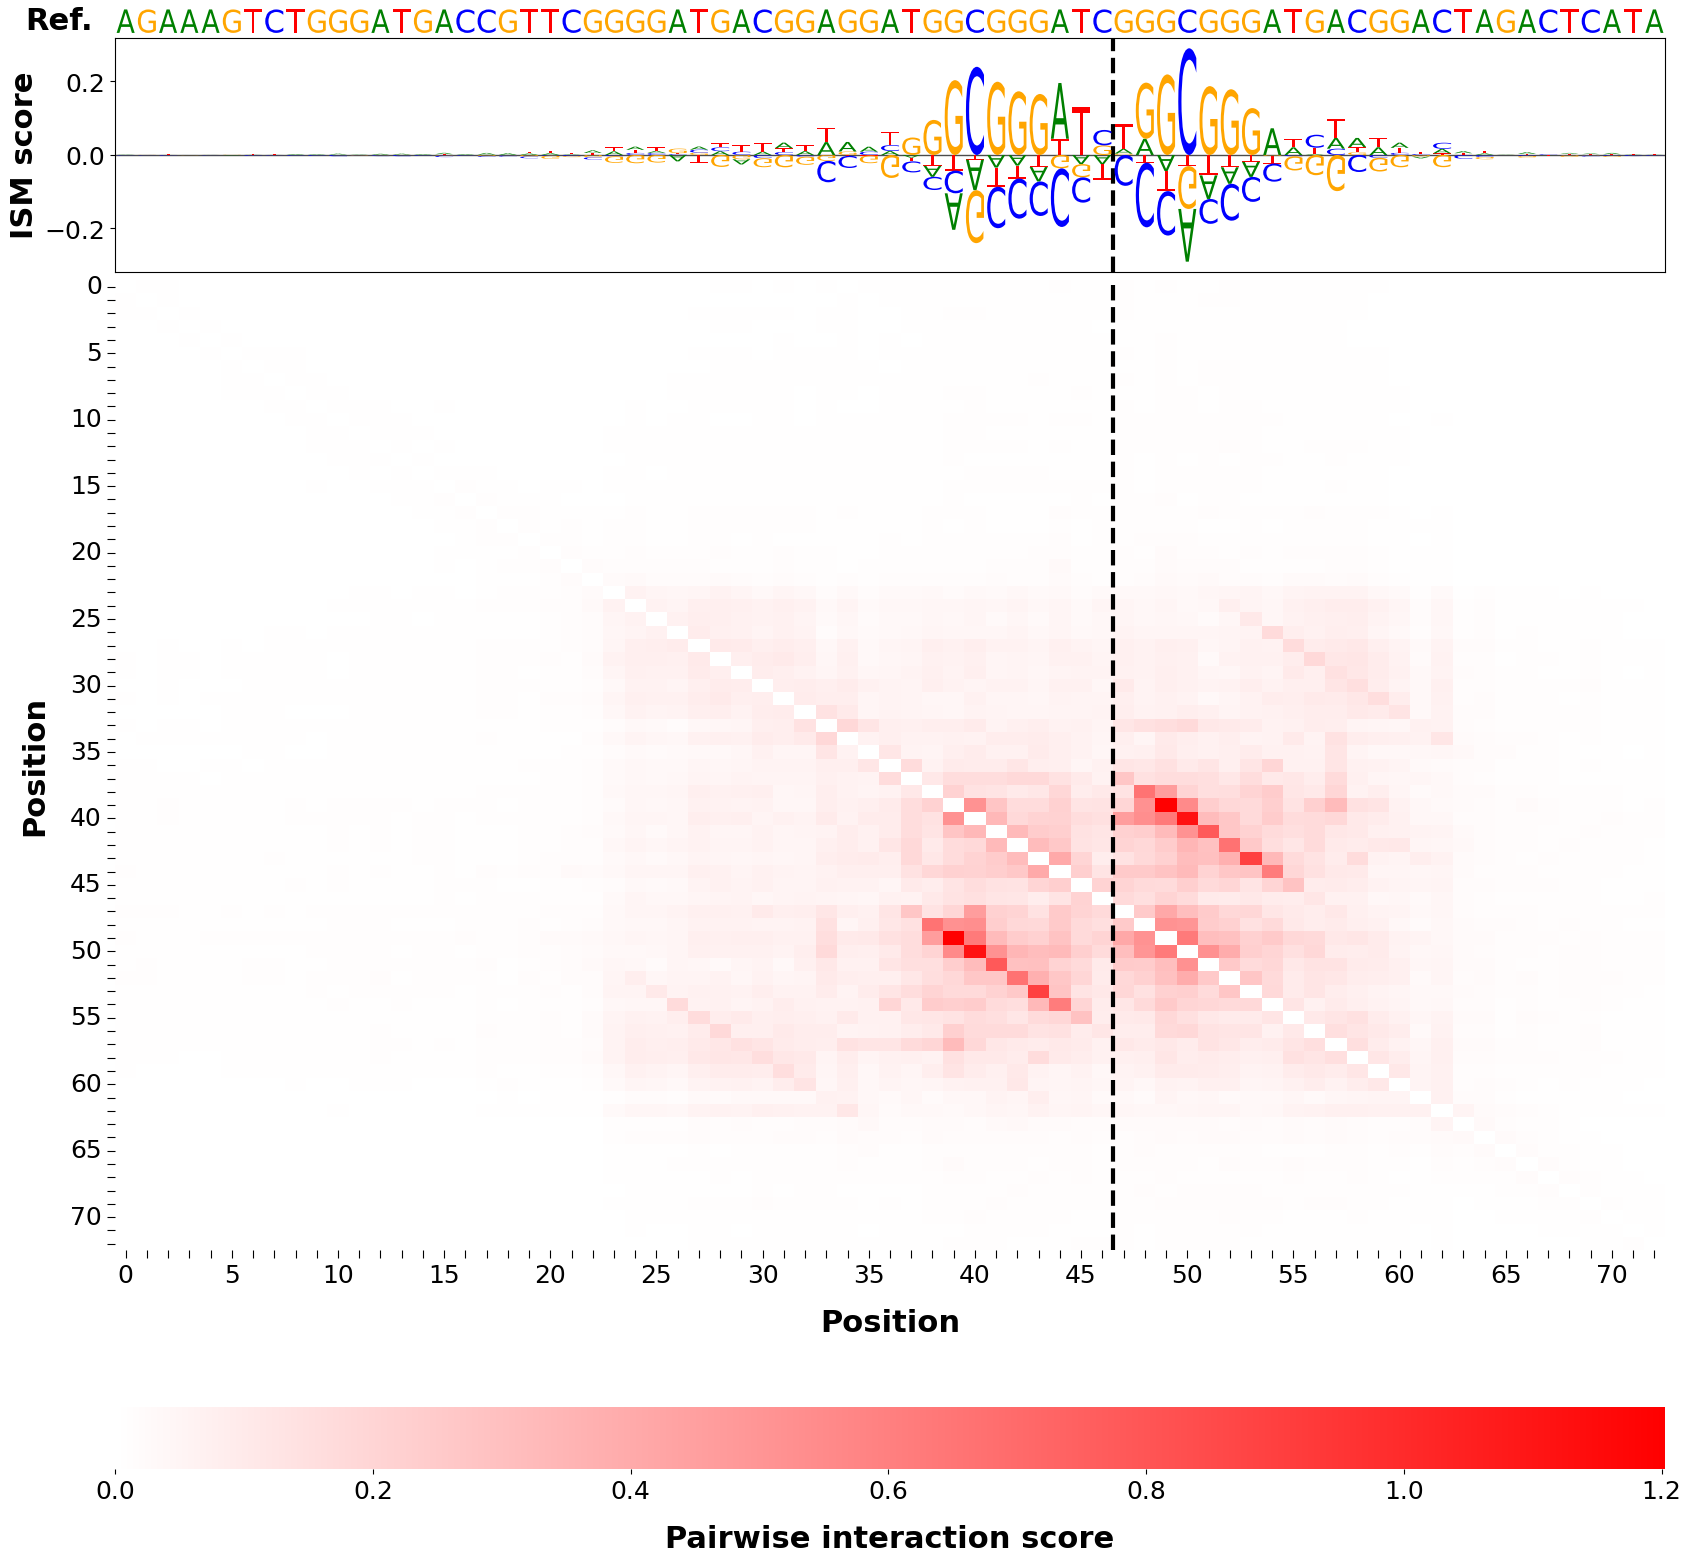

ISM and Influence Map Visualization Run: 1


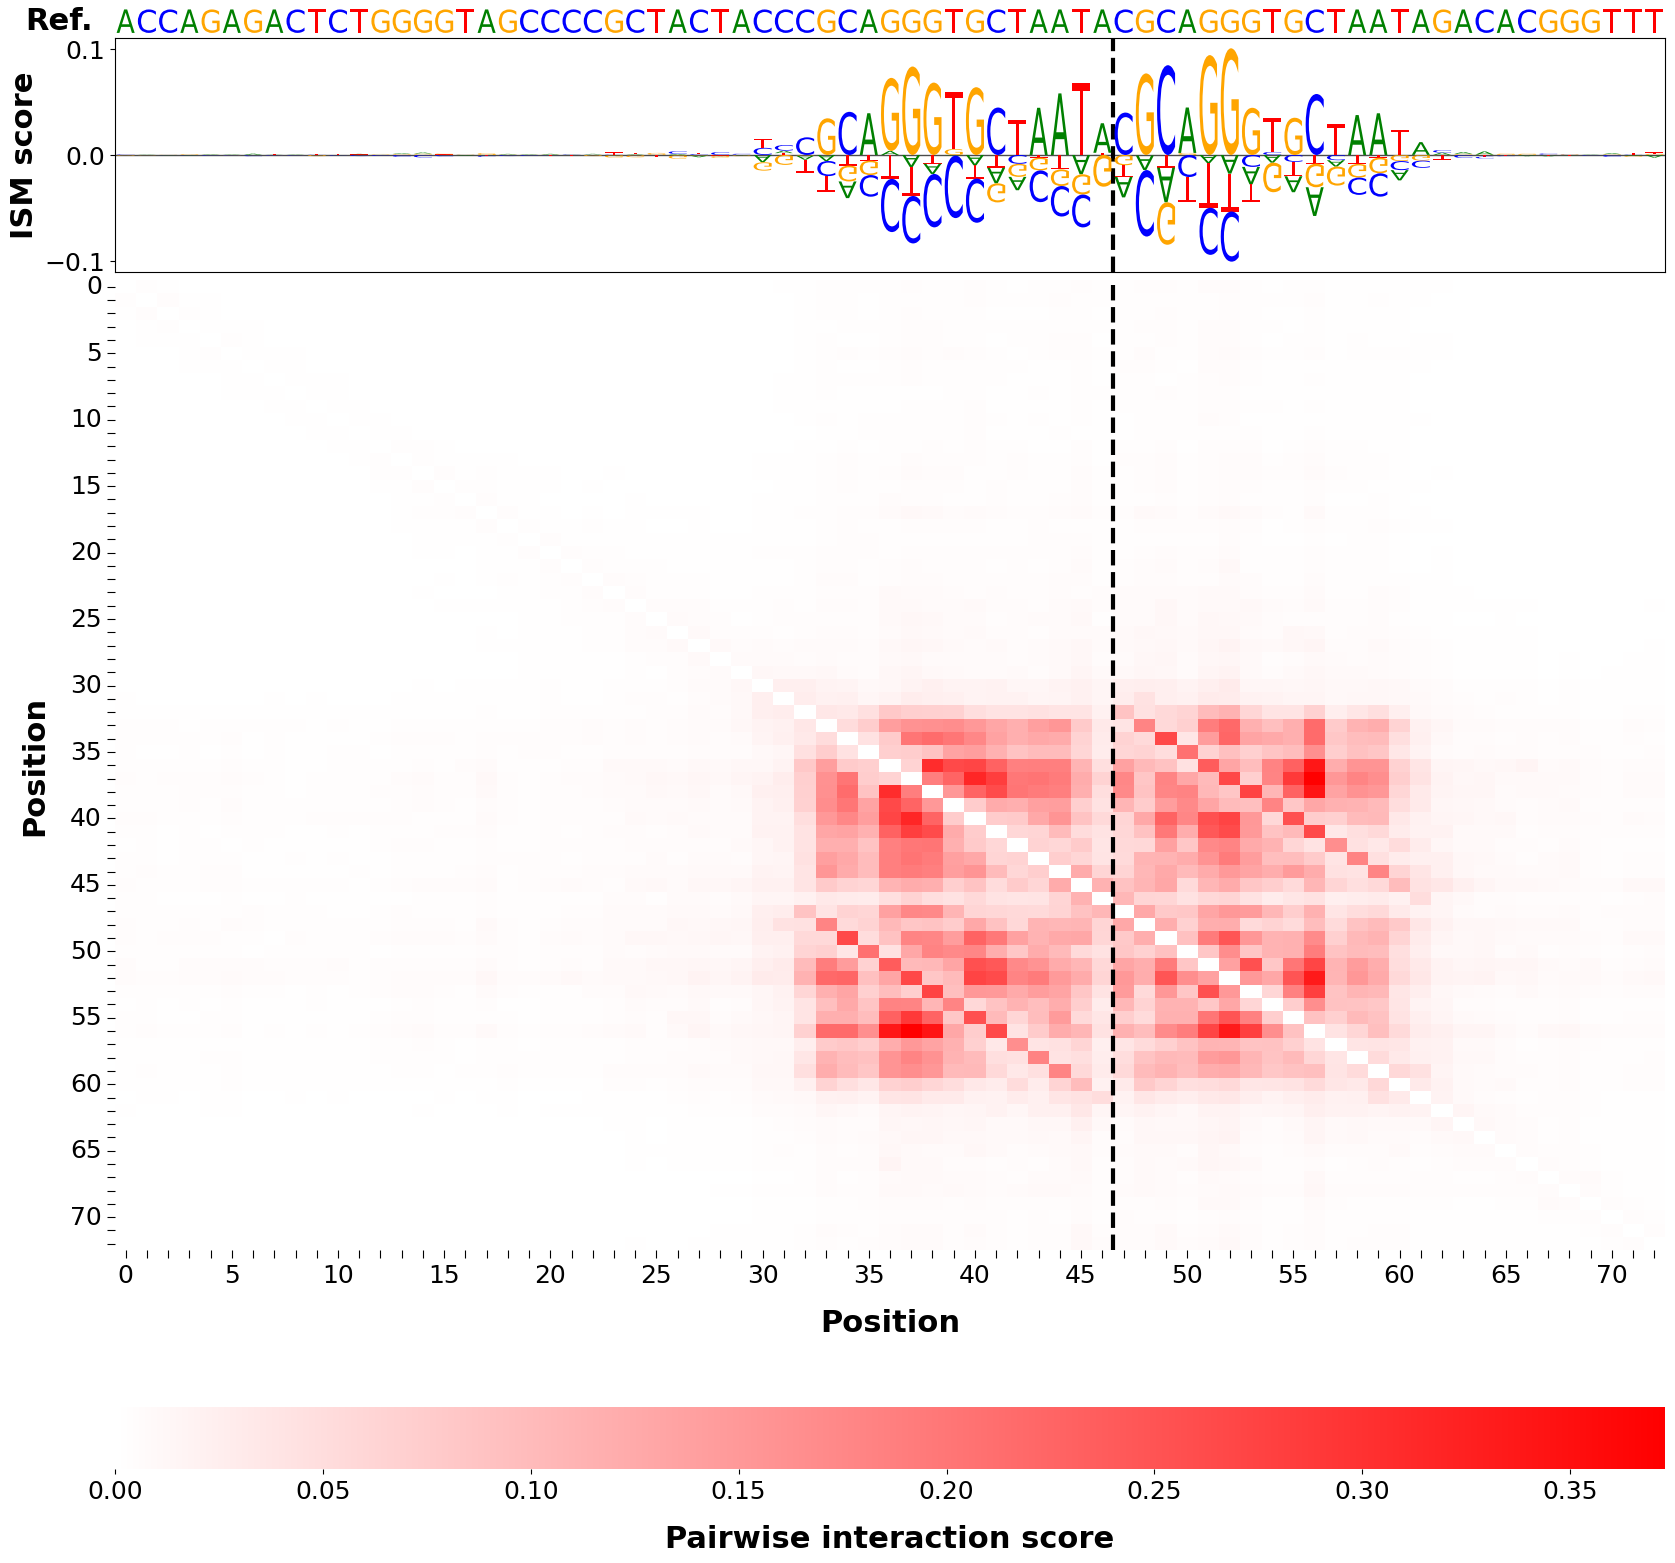

ISM and Influence Map Visualization Run: 2


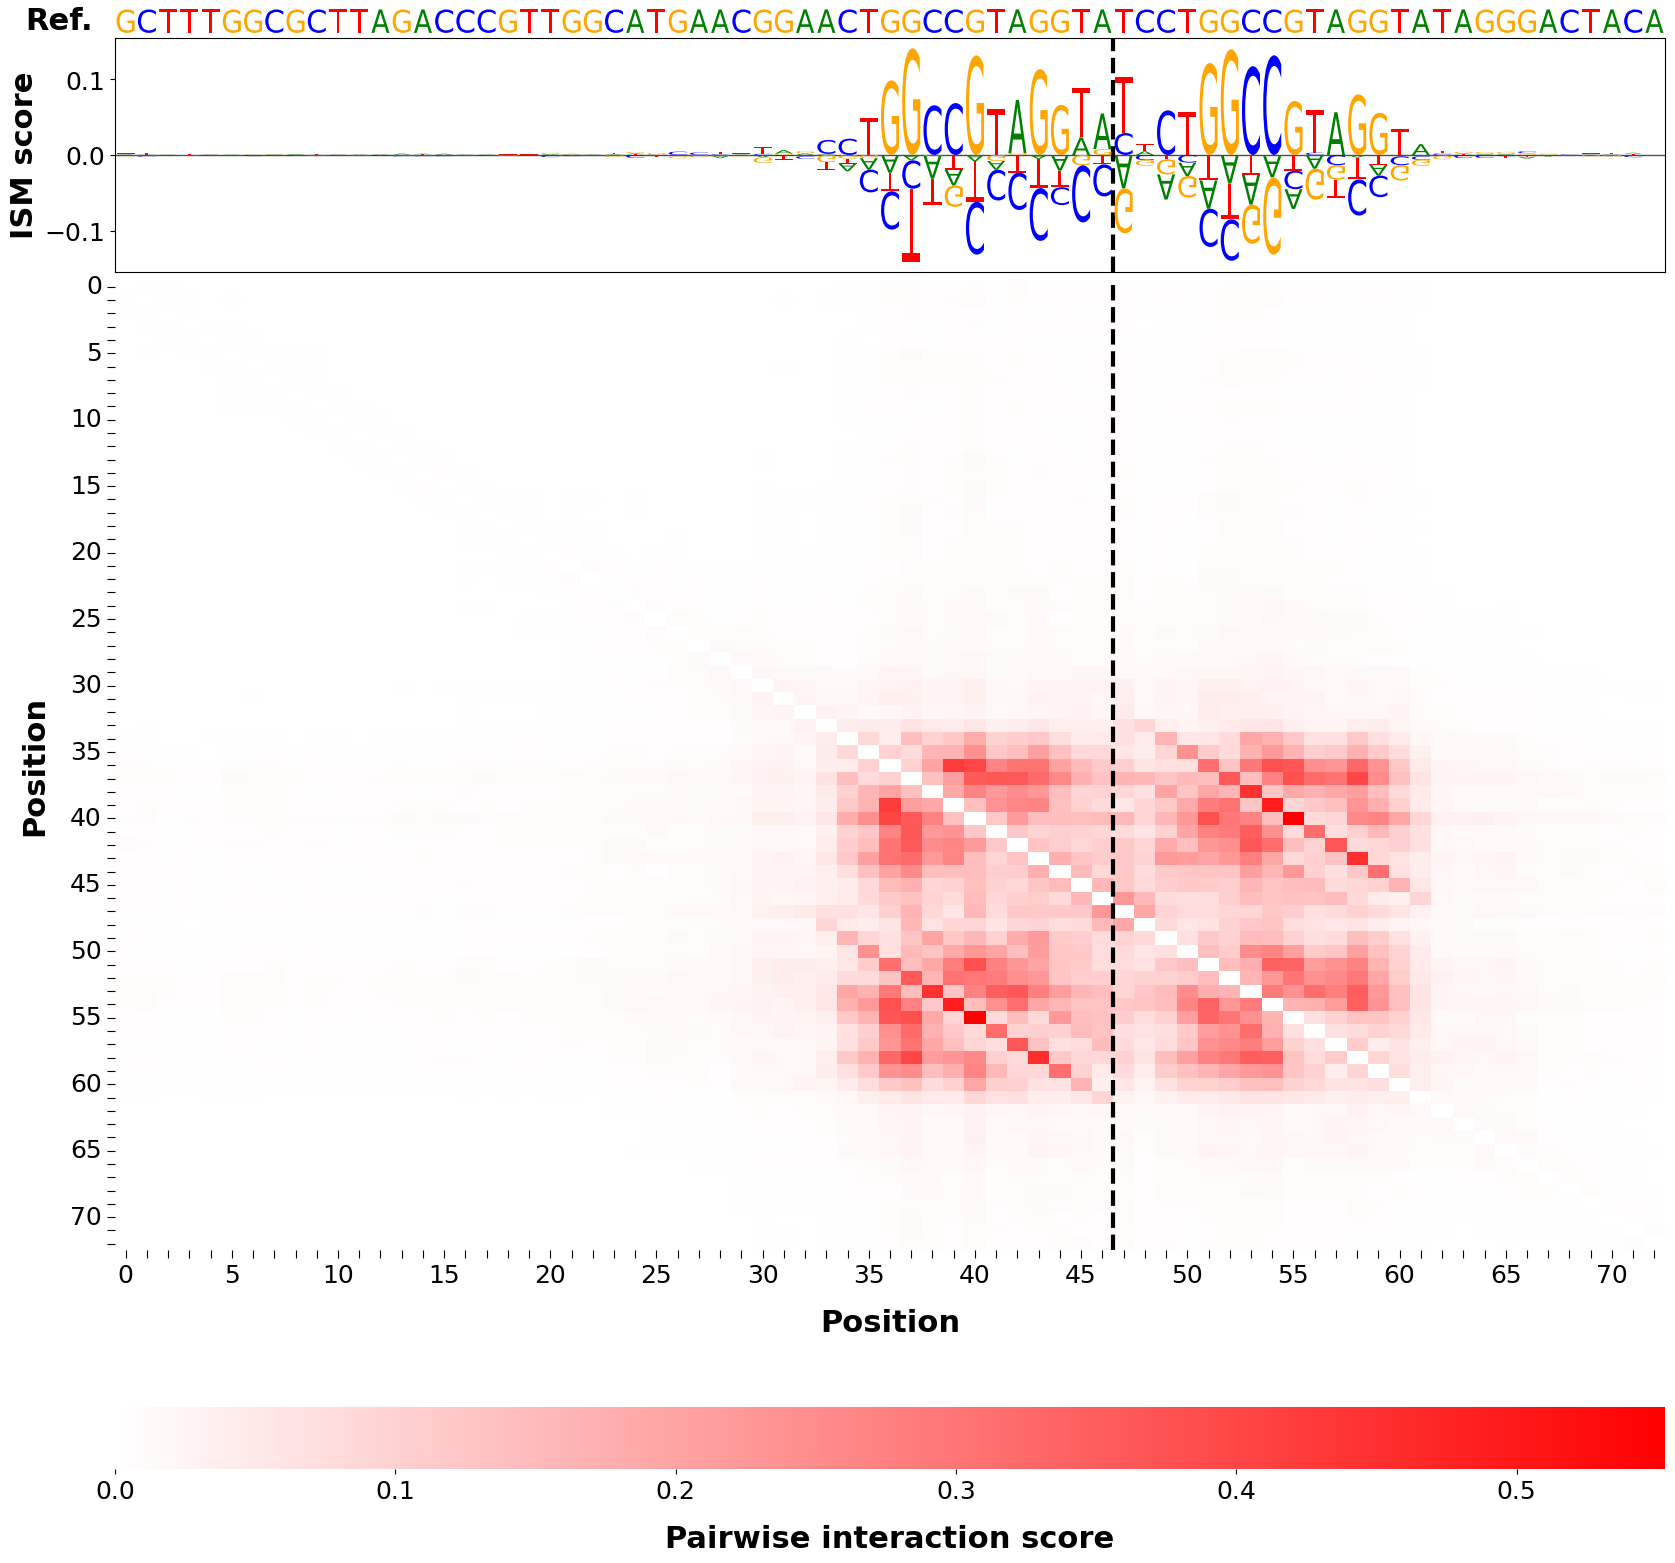

ISM and Influence Map Visualization Run: 3


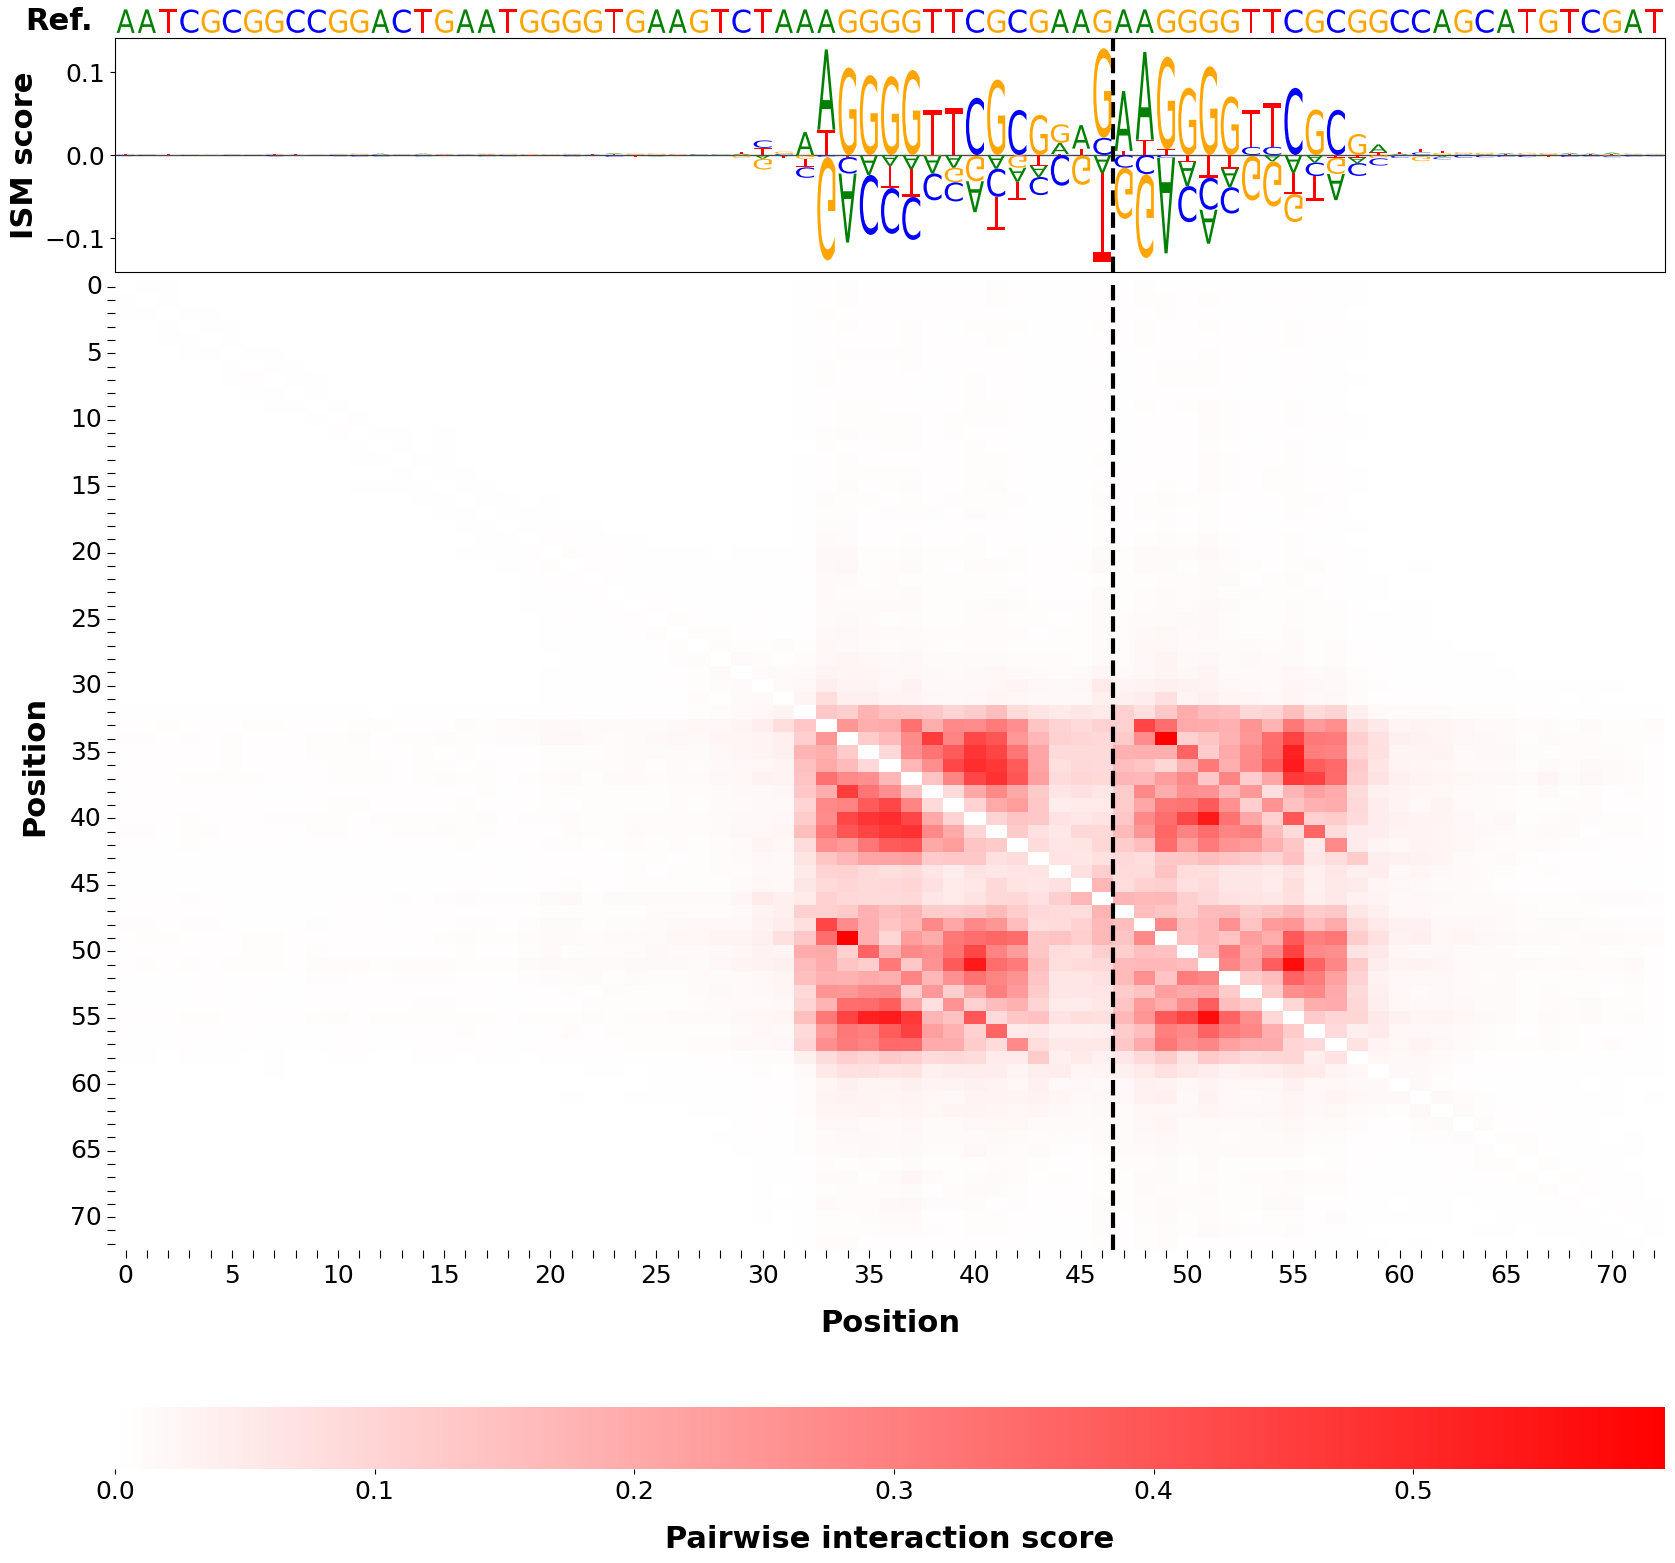

ISM and Influence Map Visualization Run: 1


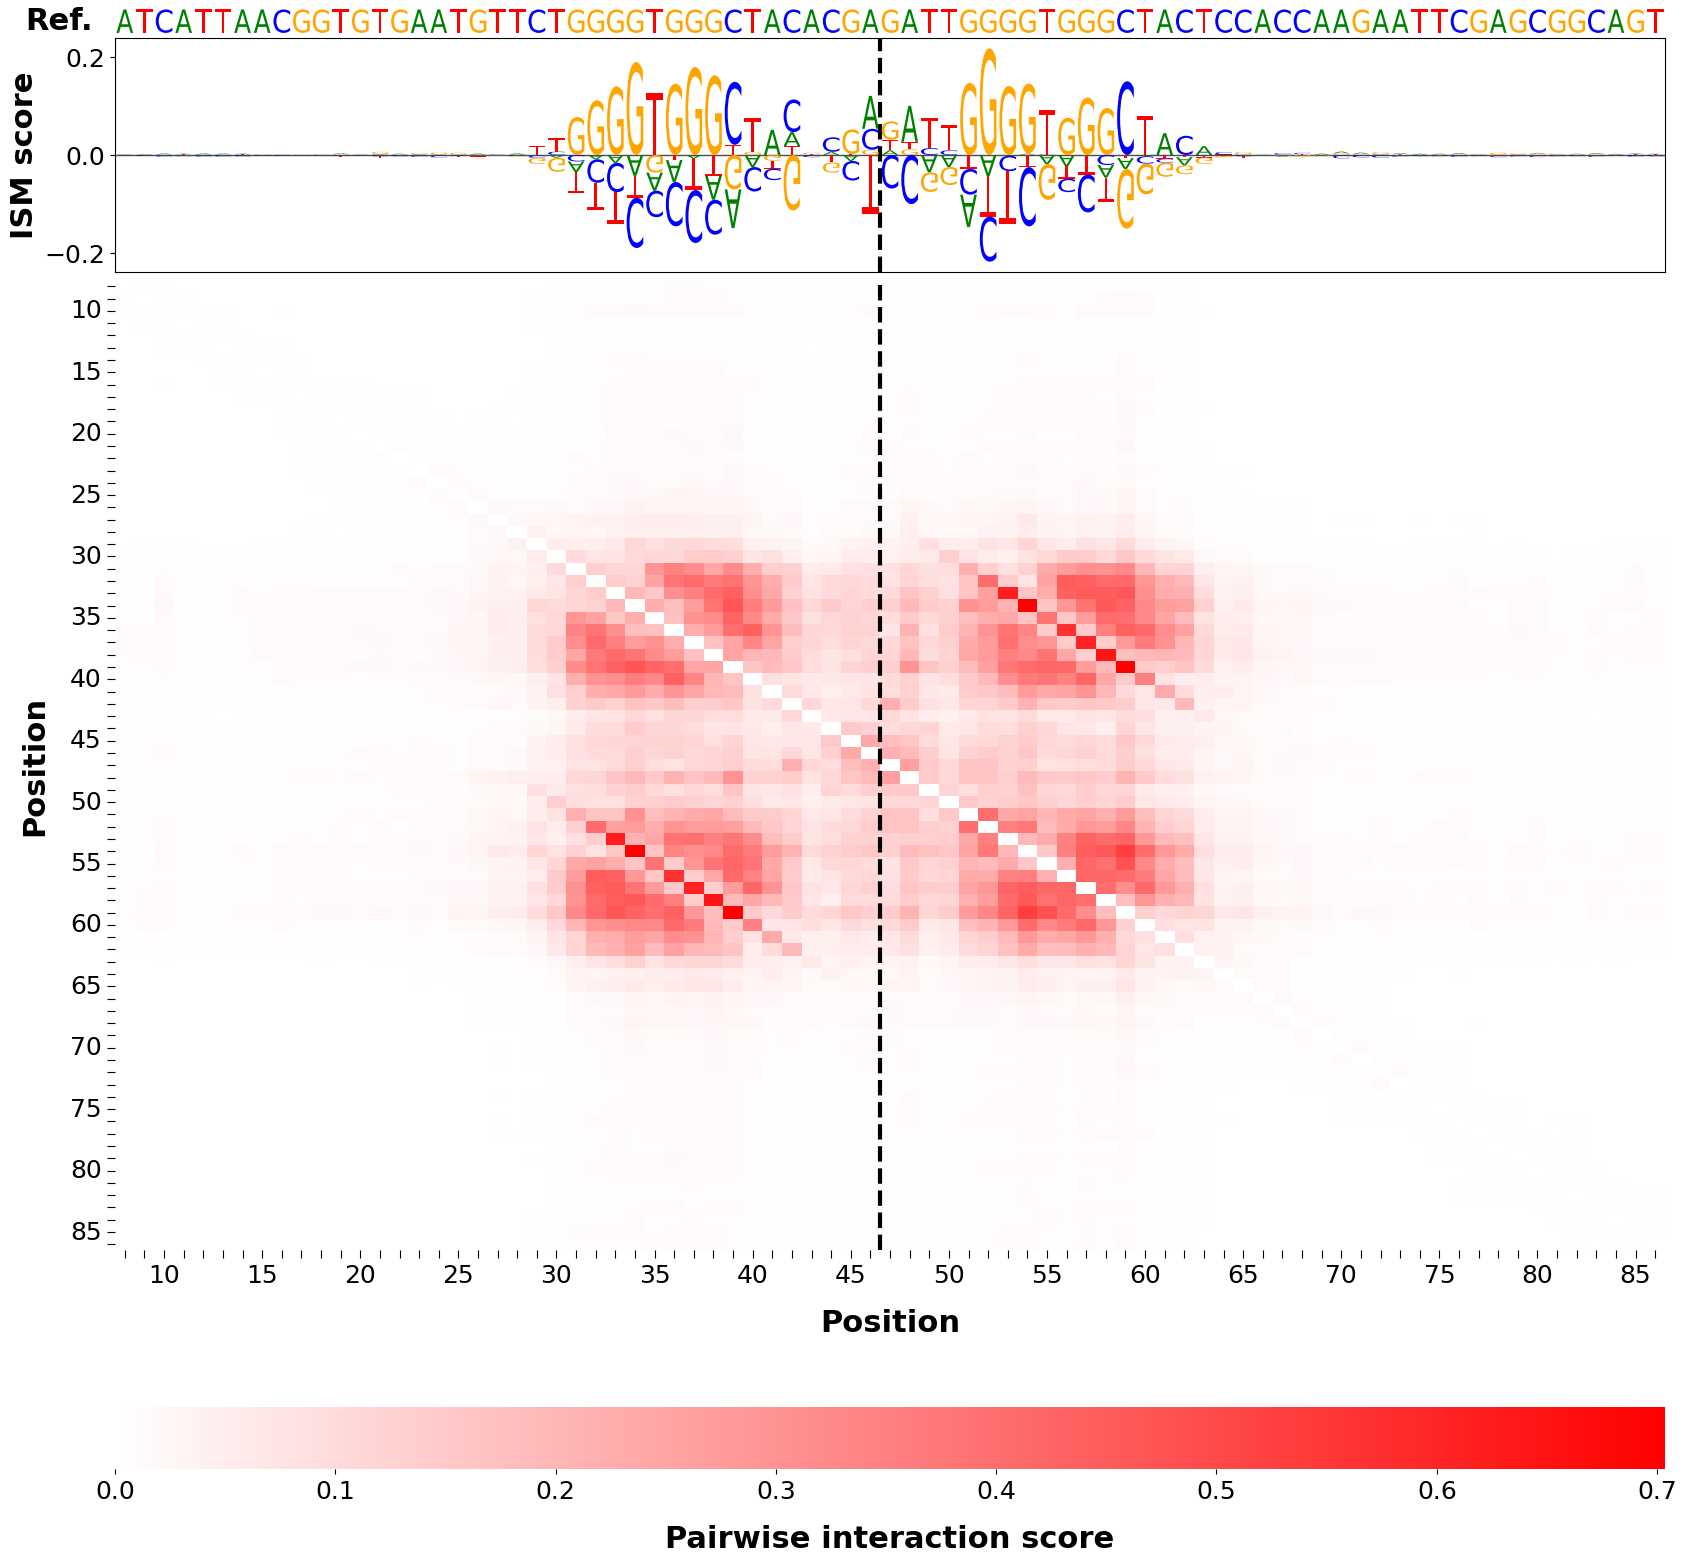

ISM and Influence Map Visualization Run: 2


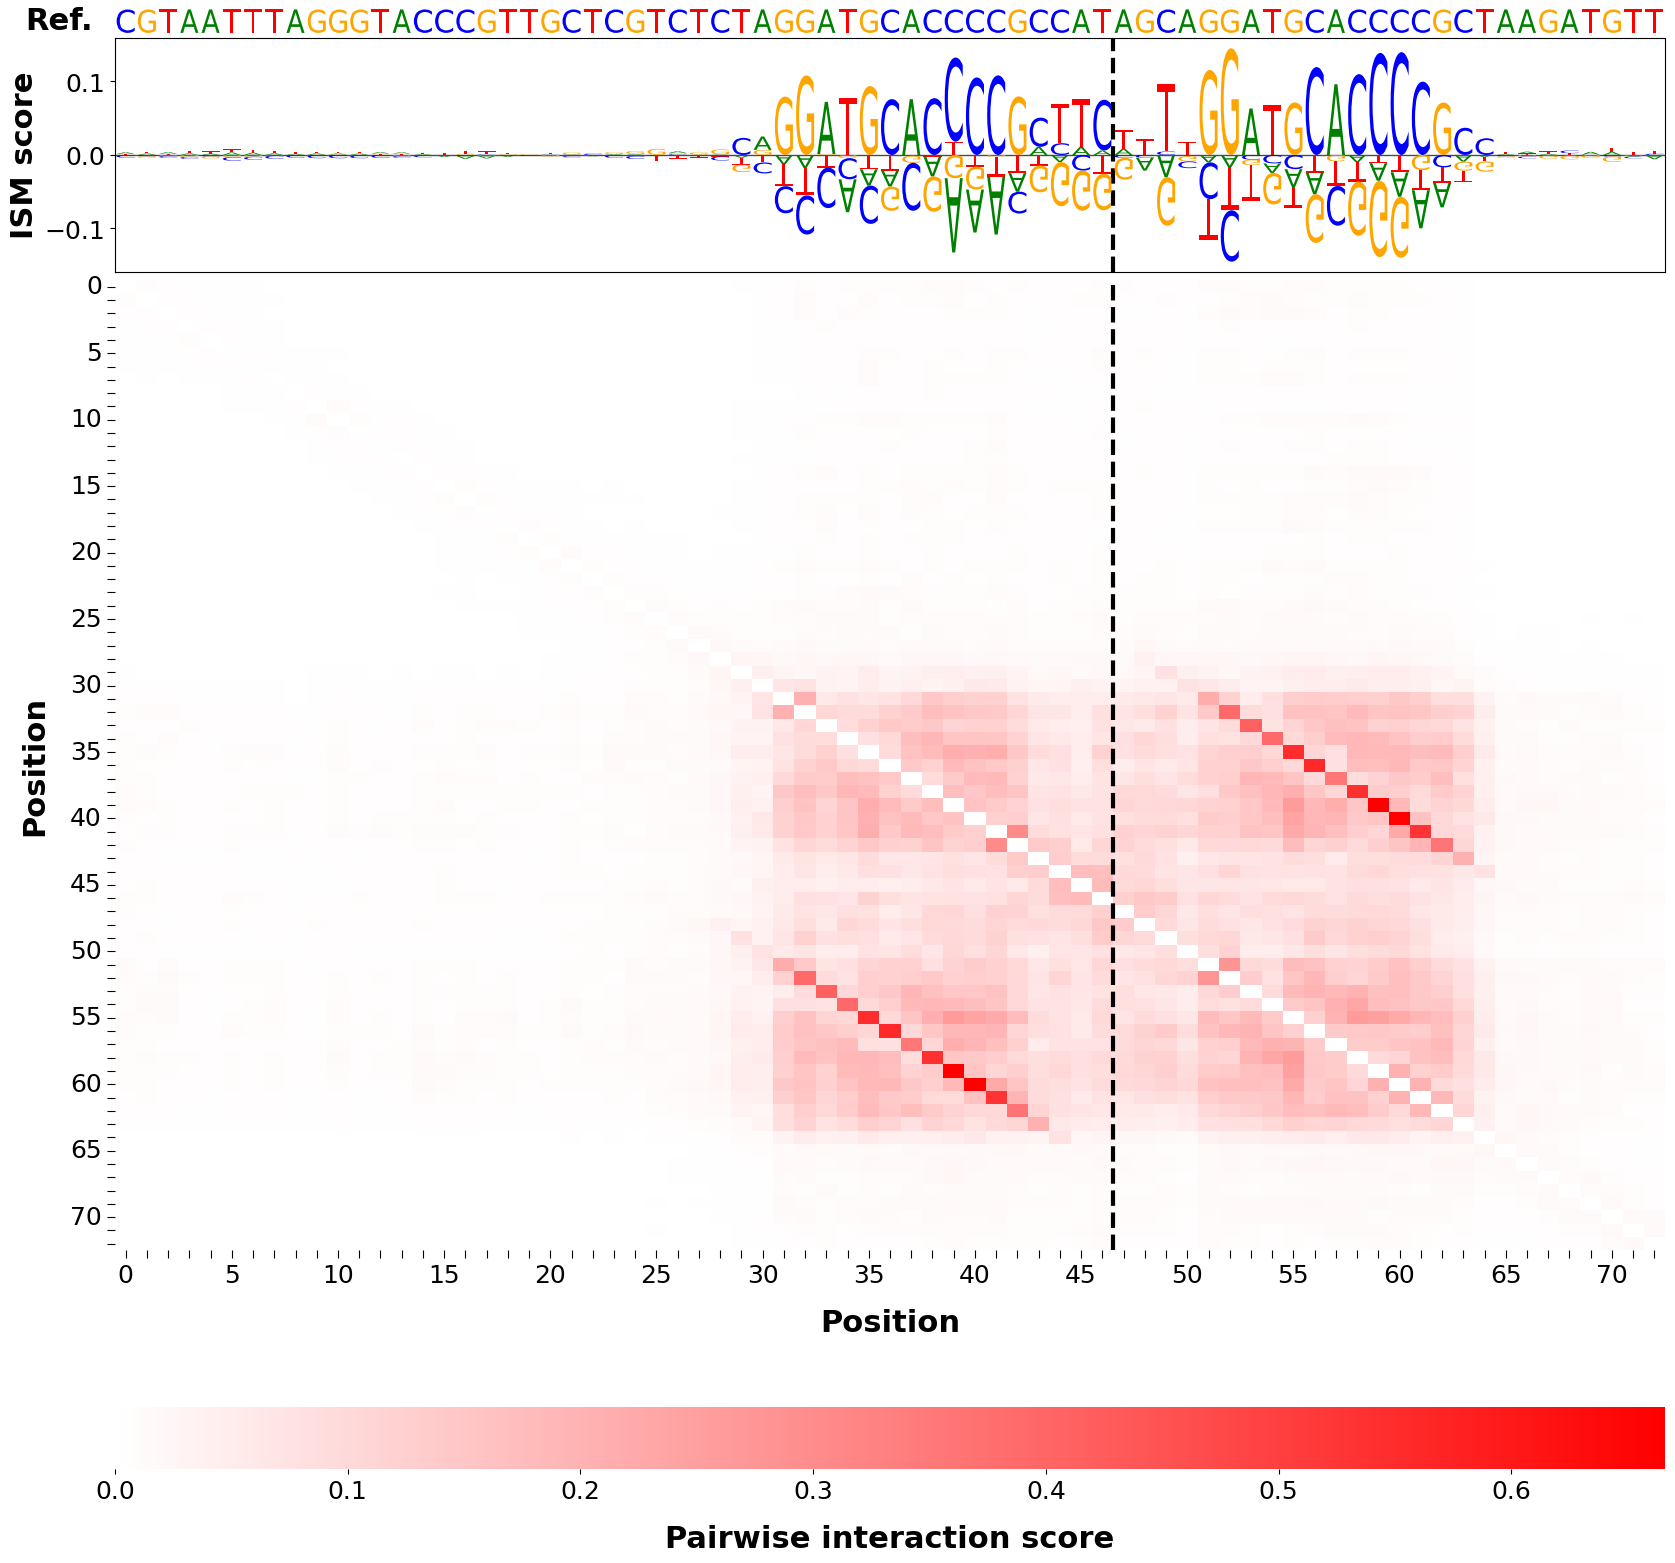

ISM and Influence Map Visualization Run: 3


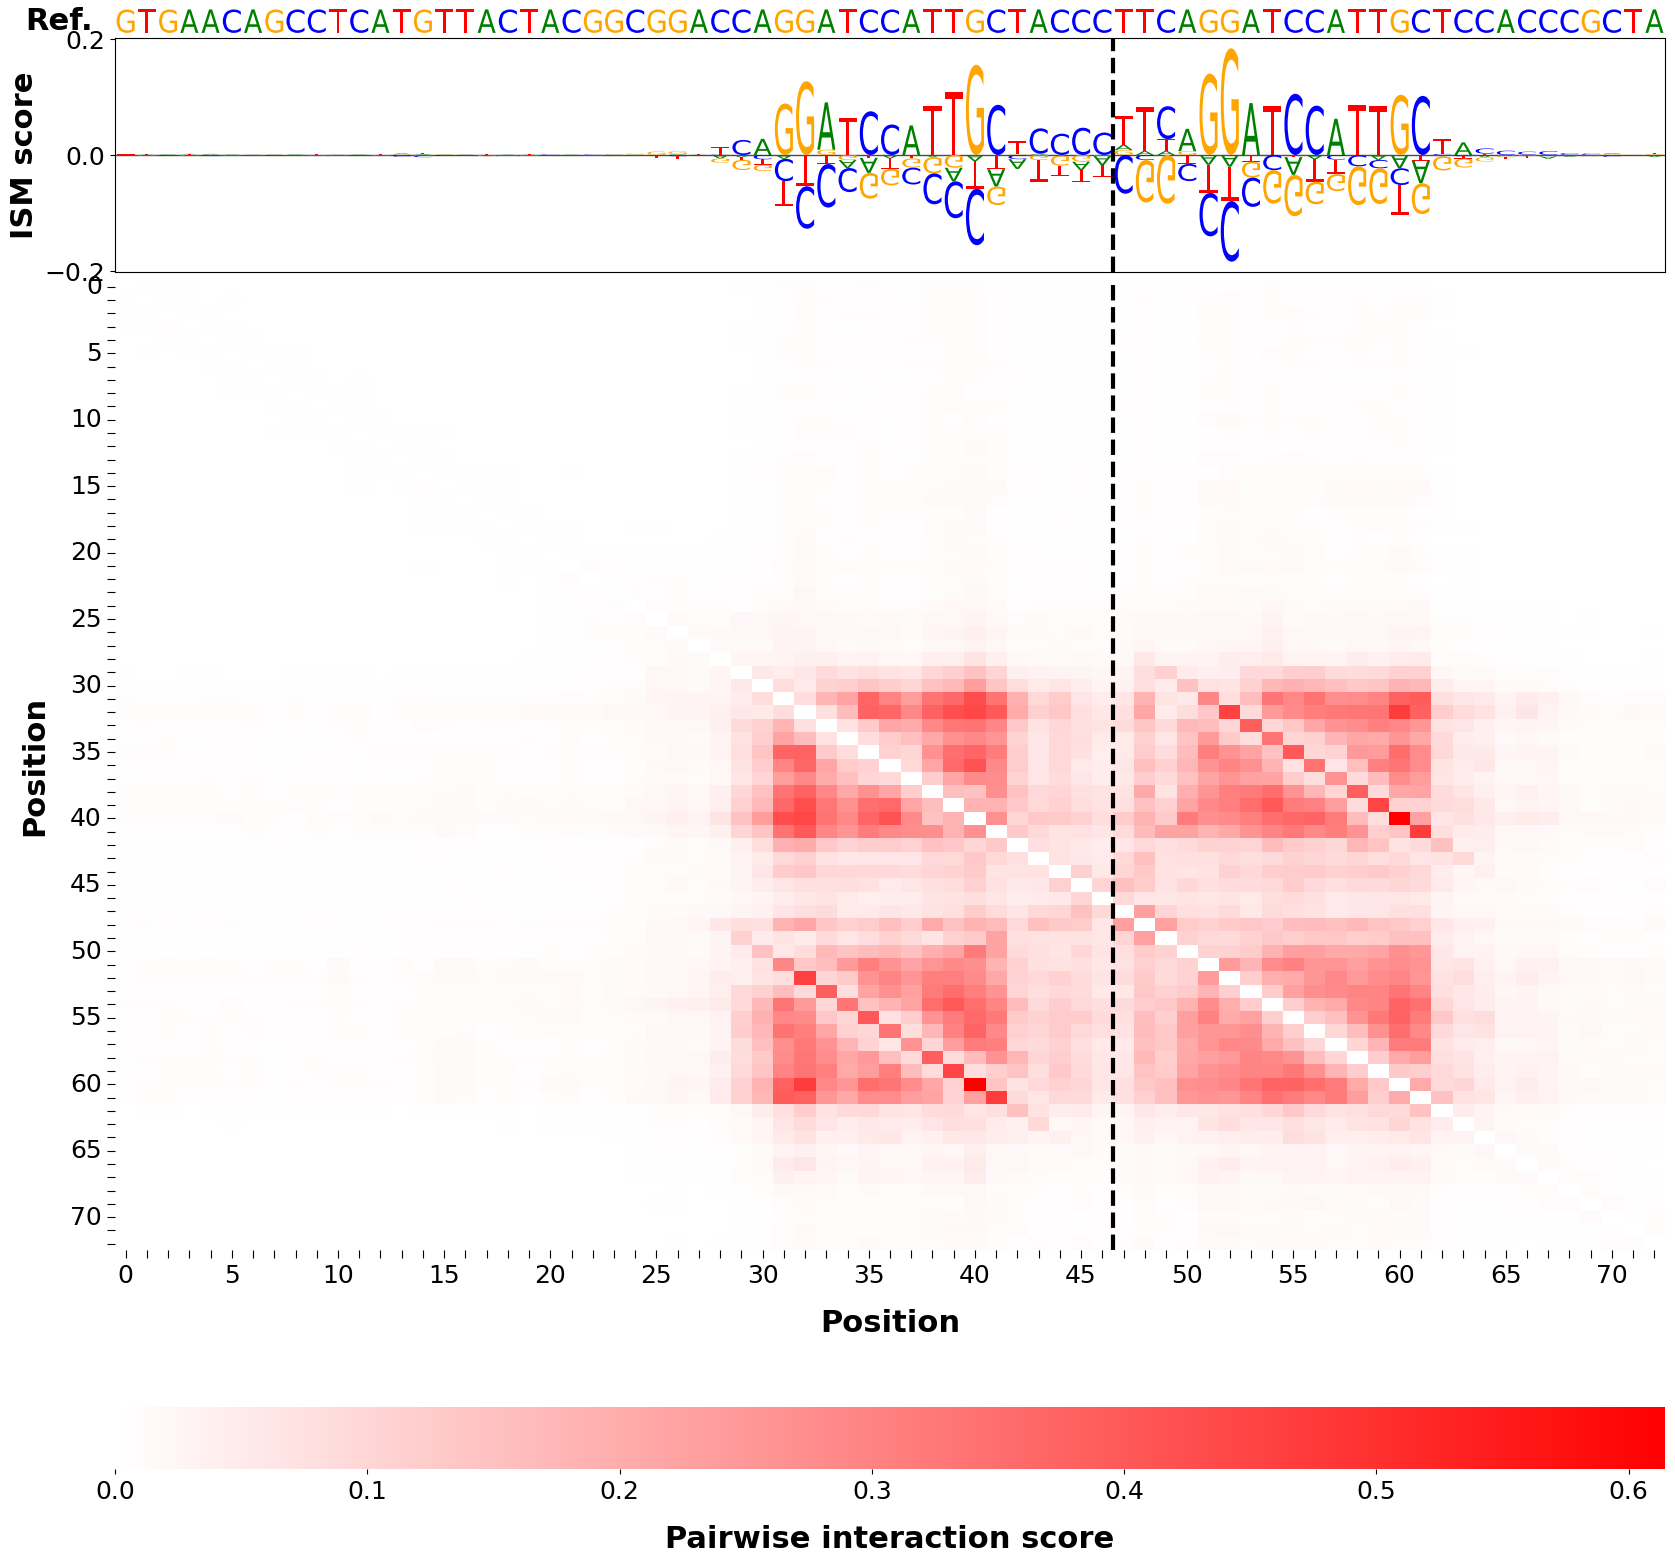

In [8]:
for i in range(1, 4):
    print("ISM and Influence Map Visualization Run:", i)
    # Replace these filenames with your actual local paths
    ism_file = f"ISM/ism_FORECasT K562_delta_-10_{i}.csv"
    inf_file = f"ISM/influence_map_FORECasT K562_delta_-10_rank_{i}.csv"

    visualize_crispr_data(ism_file, inf_file, ism_crop_min=27, ism_crop_max=68, inf_crop_min=37, inf_crop_max=56, delta=-10, i=i)

for delta in [-5, -7, -10, -15, -20]:
    for i in range(1, 4):
        print("ISM and Influence Map Visualization Run:", i)
        # Replace these filenames with your actual local paths
        ism_file = f"ISM/ism_FORECasT K562_delta_{delta}_{i}.csv"
        inf_file = f"ISM/influence_map_FORECasT K562_delta_{delta}_rank_{i}.csv"
        visualize_crispr_combined_aligned(ism_file, inf_file, ism_crop_min=None, ism_crop_max=None, delta=delta, i=i)

        #visualize_crispr_data_wide(ism_file, inf_file, ism_crop_min=None, ism_crop_max=None, inf_crop_min=None, inf_crop_max=None, delta=delta, i=i)



## Sweeps

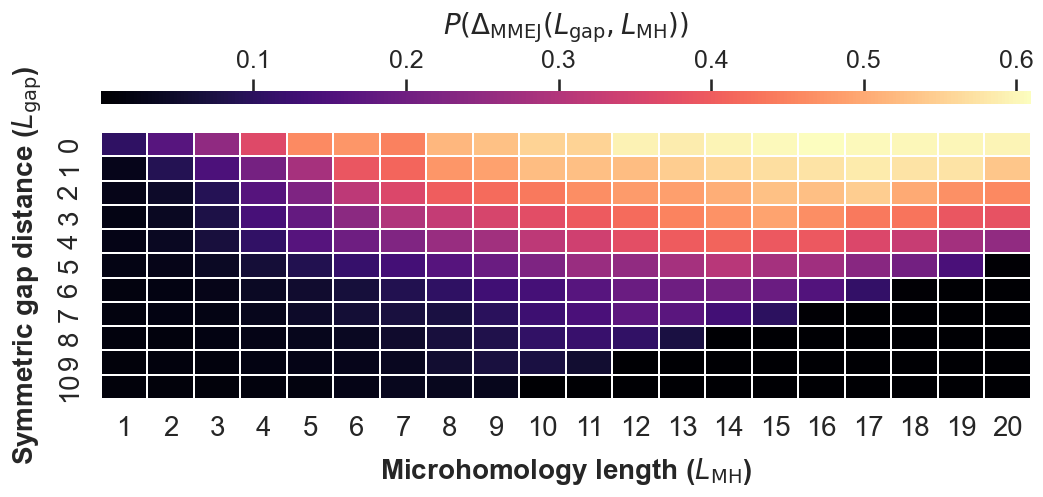

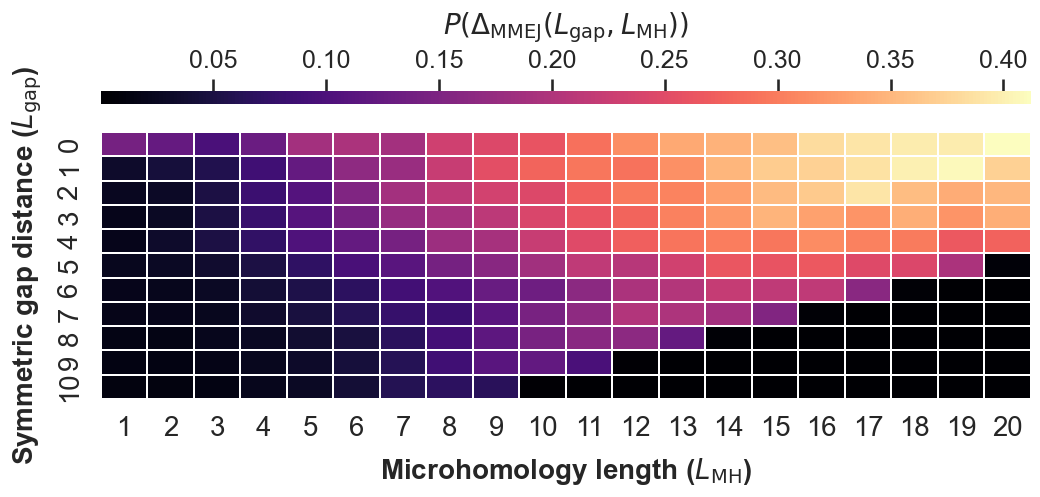

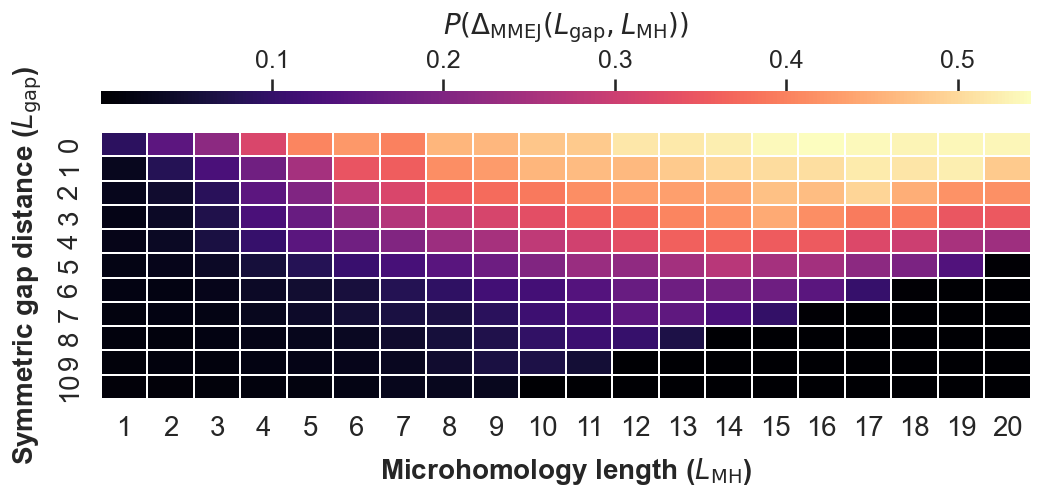

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_mmej_heatmap(path = None, output_path = None):

    # 1. Load the data
    df = pd.read_csv(path, index_col=0)

    # Set global styles
    sns.set_style("white")
    sns.set_context("talk", font_scale=1.2)

    # 2. Plotting - Using GridSpec for the "layered" approach
    # Reduced height to 5 to make it shorter top-to-bottom
    fig = plt.figure(figsize=(12, 4))
    gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 1], hspace=0.2)
    
    ax_cbar = fig.add_subplot(gs[0])
    ax = fig.add_subplot(gs[1])

    # Clean labels
    x_labels = [x.split('_')[1] for x in df.columns]
    y_labels = [x.split('_')[1] for x in df.index]

    # Create the heatmap
    heatmap = sns.heatmap(
        df, 
        annot=False, 
        cmap='magma', 
        xticklabels=x_labels, 
        yticklabels=y_labels,
        linewidths=0.01,
        linecolor='white',
        square=False,     # Ensures cells are rectangles
        cbar_ax=ax_cbar,  # Uses the top layer axis
        cbar_kws={'orientation': 'horizontal'},
        ax=ax
    )

    # Access the colorbar to style it
    cbar = ax.collections[0].colorbar

    # Axis labels
    ax.set_xlabel(r'Microhomology length ($L_{\text{MH}}$)', fontsize=20, fontweight='bold', labelpad=10)
    ax.set_ylabel(r'Symmetric gap distance ($L_{\text{gap}}$)', fontsize=20, fontweight='bold', labelpad=10)

    # Colorbar label and styling
    colorbar_label = r'$P(\Delta_{\text{MMEJ}}(L_{\text{gap}},L_{\text{MH}}))$'
    
    # Position labels and ticks on top for the layered style
    ax_cbar.xaxis.set_ticks_position('top')
    ax_cbar.xaxis.set_label_position('top')
    
    cbar.set_label(colorbar_label, fontsize=20, fontweight='bold', labelpad=12)
    cbar.ax.tick_params(labelsize=18) 

    # Save and show
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()

plot_mmej_heatmap(path = "TRD/mh_sweep_matrix_ds0.csv", output_path = "output/mmej_sweep_aligned_ds0.pdf" )
plot_mmej_heatmap(path = "TRD/mh_sweep_matrix_ds9.csv", output_path = "output/mmej_sweep_aligned_ds9.pdf" )
plot_mmej_heatmap(path = "TRD/mh_sweep_matrix_ds10.csv", output_path = "output/mmej_sweep_aligned_ds10.pdf" )

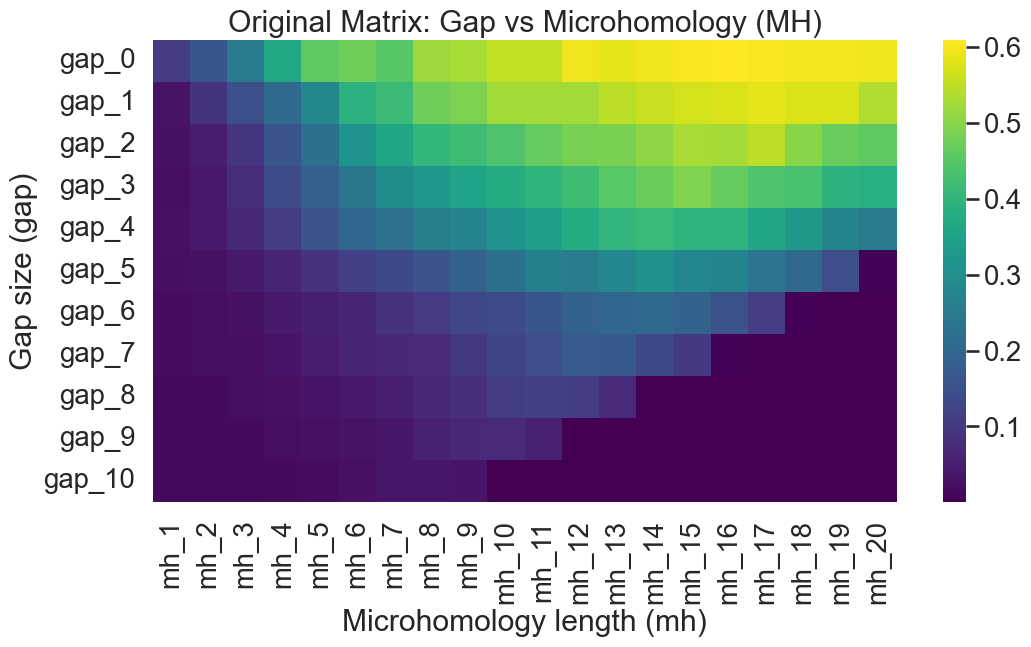

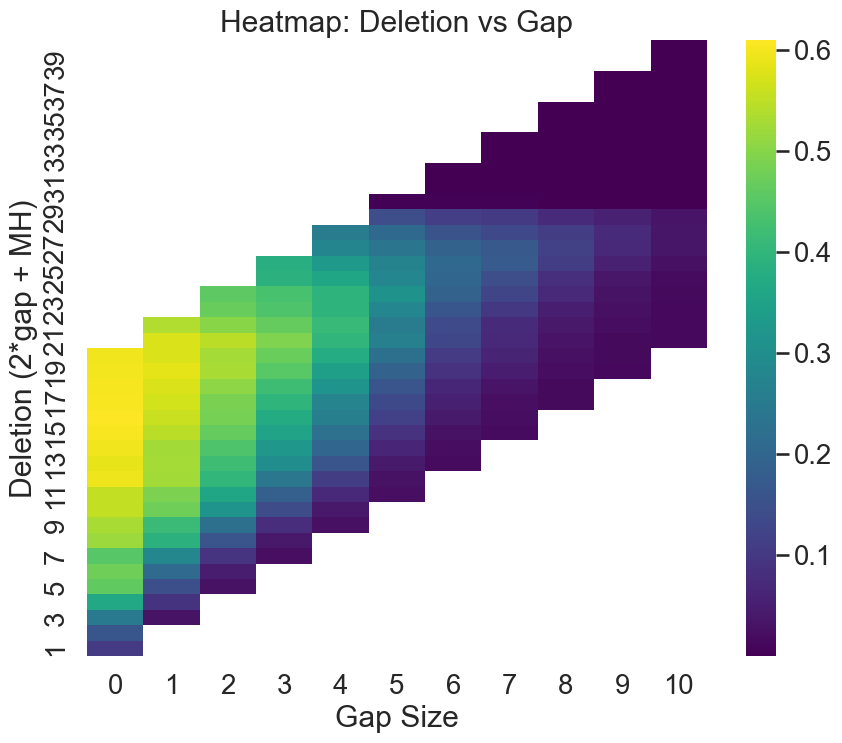

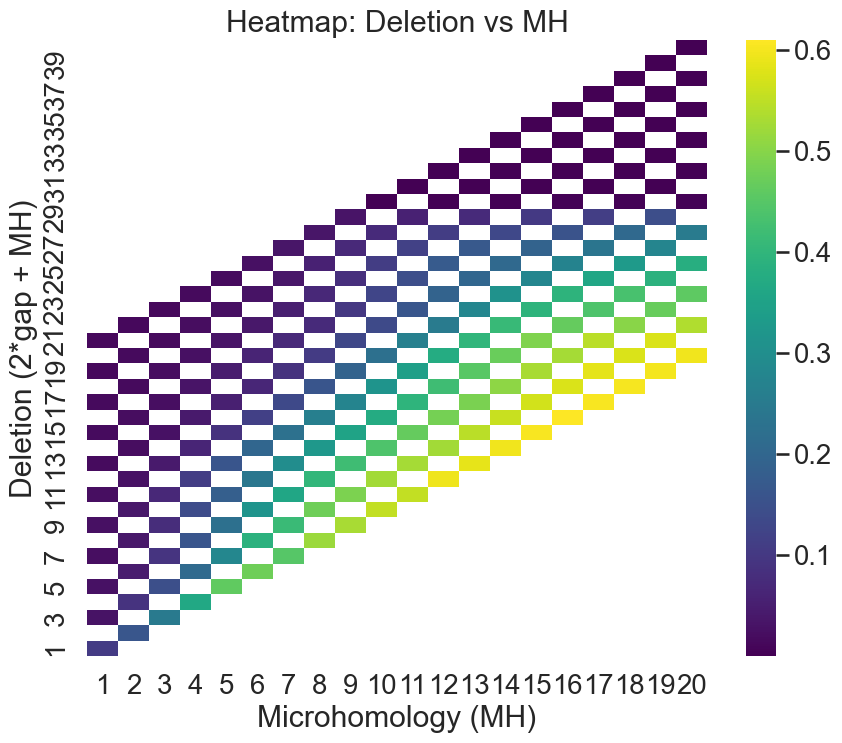

Processing complete. Files 'output/original_matrix.pdf', 'output/deletion_vs_gap.pdf', and 'output/deletion_vs_mh.pdf' have been created.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# The file has 'gap_X' as index and 'mh_X' as columns
df = pd.read_csv('TRD/mh_sweep_matrix_ds0.csv', index_col=0)

# 2. Plot the original matrix
plt.figure(figsize=(12, 6))
sns.heatmap(df, annot=False, cmap='viridis')
plt.title('Original Matrix: Gap vs Microhomology (MH)')
plt.xlabel('Microhomology length (mh)')
plt.ylabel('Gap size (gap)')
plt.savefig('output/original_matrix.pdf')
plt.show()
plt.close()

# 3. Data Transformation & Calculation
# Clean index and column names to be numeric (removing 'gap_' and 'mh_' prefixes)
df.index = [int(x.split('_')[1]) for x in df.index]
df.columns = [int(x.split('_')[1]) for x in df.columns]

# Reshape (melt) the matrix into a long-form table for calculations
df_long = df.reset_index().melt(id_vars='index', var_name='mh', value_name='value')
df_long.rename(columns={'index': 'gap'}, inplace=True)

# Calculate deletion length: deletion = gap * 2 + MH
df_long['deletion'] = df_long['gap'] * 2 + df_long['mh']

# 4. Plot Matrix: Deletion vs Gap
# Pivot the long-form data back into a matrix format
pivot_del_gap = df_long.pivot(index='deletion', columns='gap', values='value')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_del_gap, cmap='viridis')
plt.title('Heatmap: Deletion vs Gap')
plt.xlabel('Gap Size')
plt.ylabel('Deletion (2*gap + MH)')
plt.gca().invert_yaxis() # Invert y-axis so deletion size increases upwards
plt.savefig('output/deletion_vs_gap.pdf')
plt.show()
plt.close()

# 5. Plot Matrix: Deletion vs MH
pivot_del_mh = df_long.pivot(index='deletion', columns='mh', values='value')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_del_mh, cmap='viridis')
plt.title('Heatmap: Deletion vs MH')
plt.xlabel('Microhomology (MH)')
plt.ylabel('Deletion (2*gap + MH)')
plt.gca().invert_yaxis()
plt.savefig('output/deletion_vs_mh.pdf')
plt.show()
plt.close()

print("Processing complete. Files 'output/original_matrix.pdf', 'output/deletion_vs_gap.pdf', and 'output/deletion_vs_mh.pdf' have been created.")

# Heatmap

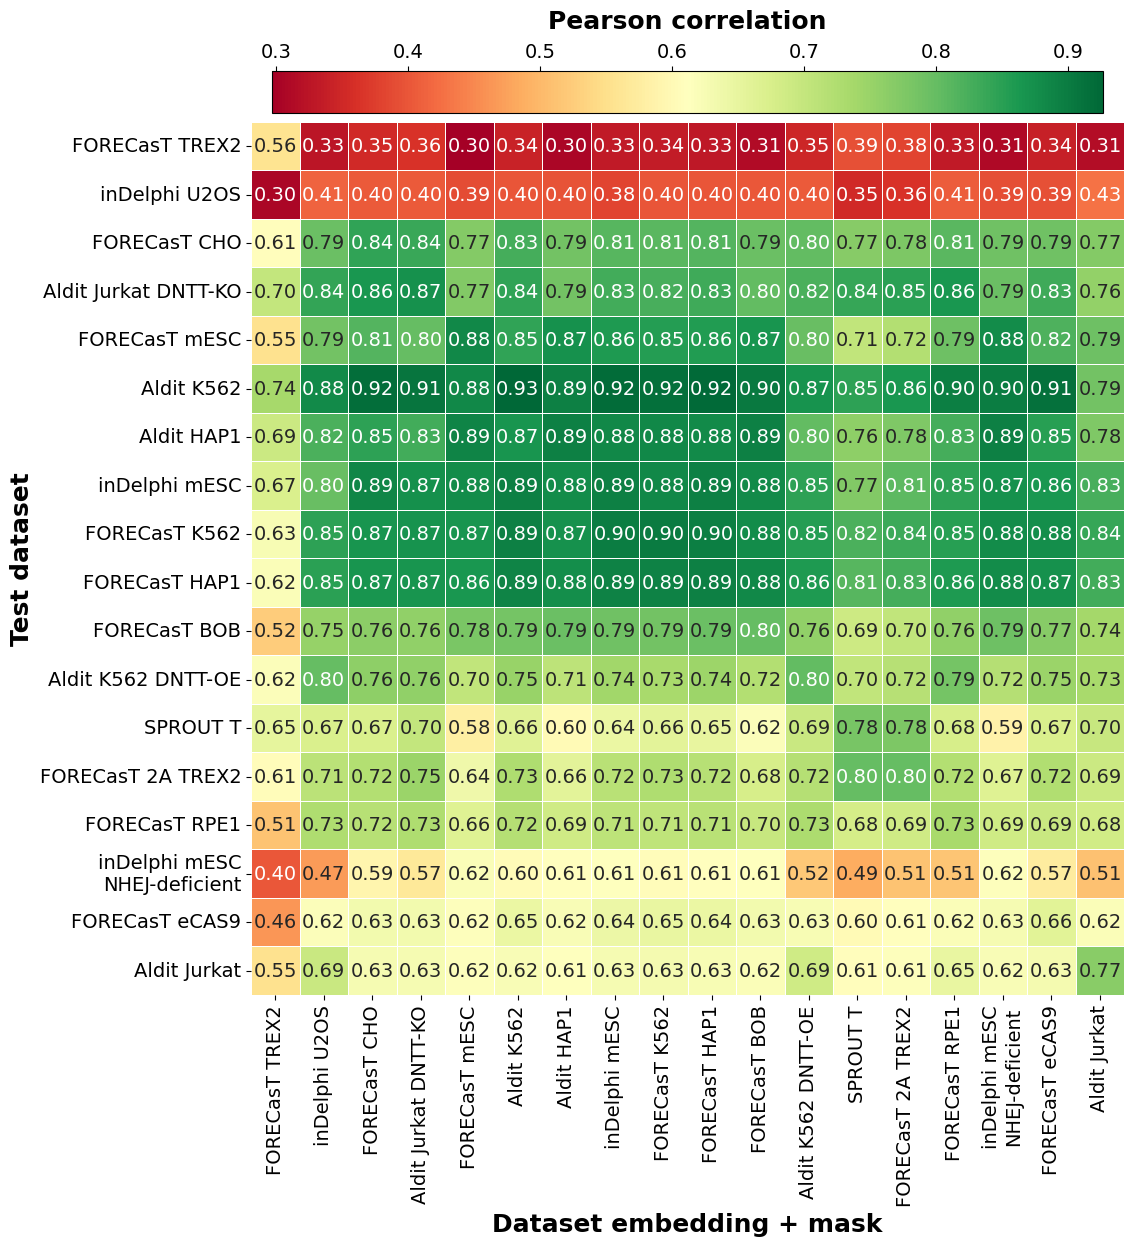

--- Plot saved to output/experiment_1_clean_heatmap.pdf ---


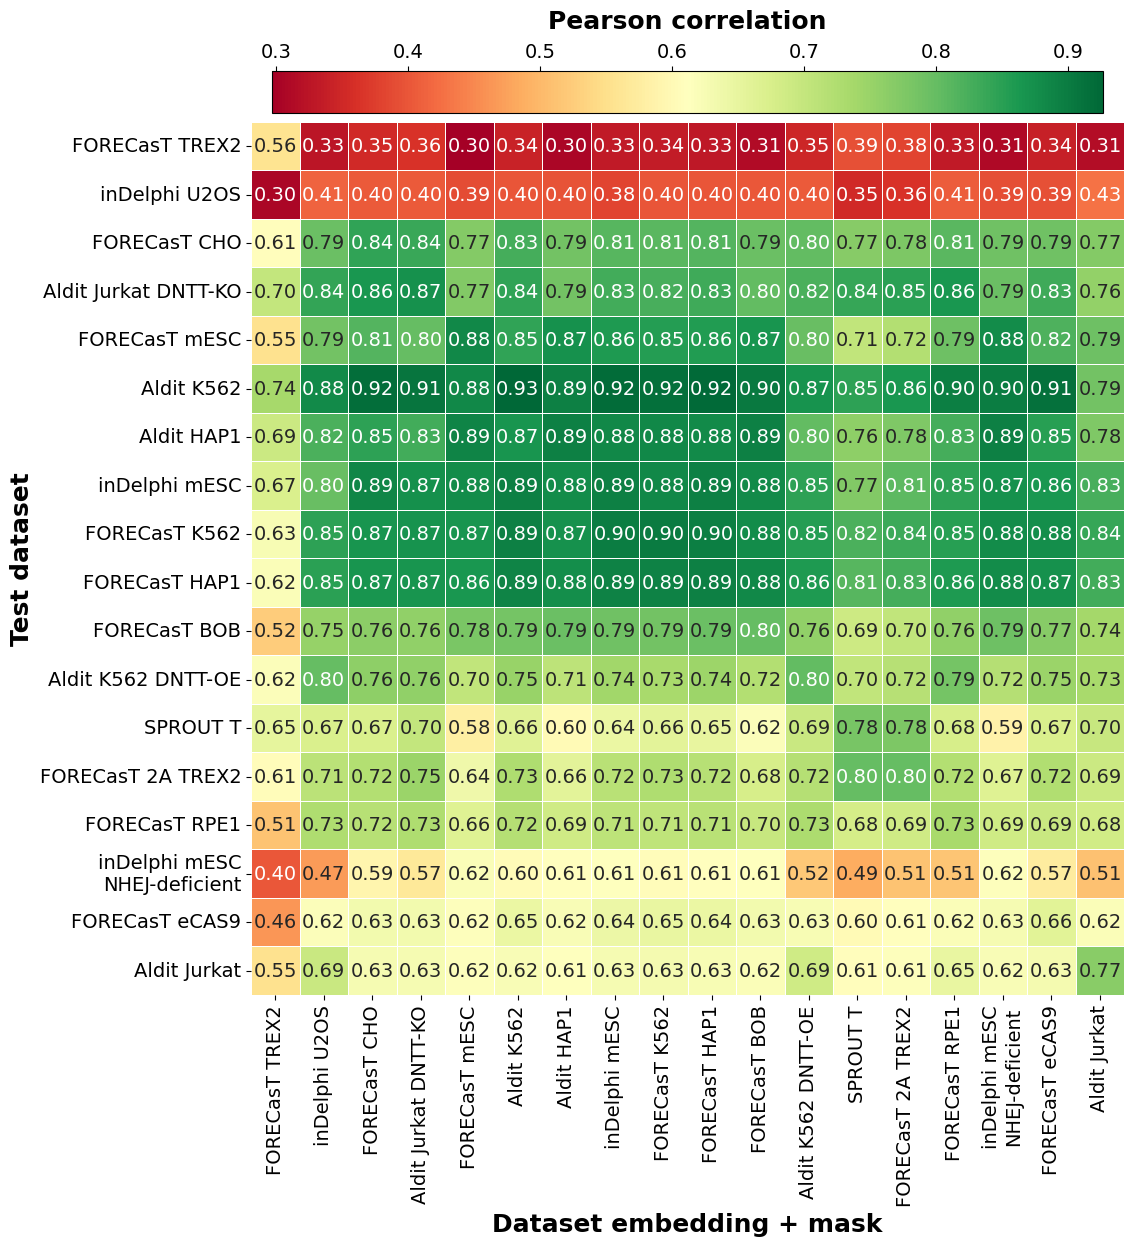

--- Plot saved to output/experiment_1_clean_heatmap.svg ---


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial import distance

def plot_ordered_pearson_heatmap(csv_path, output_filename='output/ordered_pearson_matrix.pdf'):
    """
    Plots a clean Pearson matrix using sns.heatmap (removes clustermap whitespace).
    """
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Define Manual Selection
    manual_selection = [
        'FORECasT K562', 'FORECasT eCAS9', 'FORECasT TREX2', 'FORECasT 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        'SPROUT T', 
        'Aldit K562', 'Aldit K562 DNTTOE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTTKO',
        'InDelphi mESC', 'InDelphi mESC NHEJdeficient', 'InDelphi U2OS'
    ]

    # 3. Filter DataFrame
    existing_order = [x for x in manual_selection if x in df.index]
    df_subset = df.loc[existing_order, existing_order]
    
    df_subset.rename(index={'InDelphi mESC NHEJdeficient': 'InDelphi mESC\nNHEJ-deficient'},
                     columns={'InDelphi mESC NHEJdeficient': 'InDelphi mESC\nNHEJ-deficient'}, inplace=True)
    
    df_subset.rename(index={'Aldit Jurkat DNTTKO': 'Aldit Jurkat DNTT-KO'},
                     columns={'Aldit Jurkat DNTTKO': 'Aldit Jurkat DNTT-KO'}, inplace=True)
    
    df_subset.rename(index={'Aldit K562 DNTTOE': 'Aldit K562 DNTT-OE'},
                     columns={'Aldit K562 DNTTOE': 'Aldit K562 DNTT-OE'}, inplace=True)
    

    # rename all InDelphi to inDelphi

    df_subset.rename(index=lambda x: x.replace('InDelphi', 'inDelphi'),
                     columns=lambda x: x.replace('InDelphi', 'inDelphi'), inplace=True)

    # 4. Compute Row Linkage (To find the correct order)
    row_linkage = hierarchy.linkage(distance.pdist(df_subset), method='average')
    
    # 5. Get the order of leaves
    dendro = hierarchy.dendrogram(row_linkage, no_plot=True)
    row_leaf_order = dendro['leaves']

    col_leaf_order = row_leaf_order  # Since we want the same order for columns
    # reverse it (DONT)
    # col_leaf_order = col_leaf_order[::-1]
    
    # 6. Reorder BOTH Rows and Columns manually
    df_final = df_subset.iloc[row_leaf_order, col_leaf_order]

    # 7. Generate the Heatmap (Using sns.heatmap instead of clustermap)
    plt.figure(figsize=(14, 12)) # Control the size directly here
    
# Capture the axes object to modify labels later
    ax = sns.heatmap(
        df_final, 
        cmap='RdYlGn',       
        annot=True, 
        fmt=".2f", 
        linewidths=.5,
        cbar=False,
        square=True,
        # --- CHANGE 1: Increase font size inside the cells ---
        annot_kws={"size": 14}  # Adjust this number to fit your preference
    )

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    # 8. Label the axes
    plt.xlabel('Dataset embedding + mask', fontsize=18, fontweight='bold')
    plt.ylabel('Test dataset', fontsize=18, fontweight='bold')

    # remove labels for cleaner look
    #plt.xlabel('')
    #plt.ylabel('')

    # add colorbar with label
    cbar = ax.figure.colorbar(
        ax.collections[0], 
        ax=ax, 
        location='top', 
        orientation='horizontal', 
        fraction=0.045, 
        pad=0.01
    )
    cbar.set_label('Pearson correlation', fontsize=18, fontweight='bold', labelpad=10)
    cbar.ax.tick_params(labelsize=14)

    

    # 9. Save and export
    # bbox_inches='tight' works much better with simple heatmaps
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"--- Plot saved to {output_filename} ---")



# Execute the function
plot_ordered_pearson_heatmap('CD/experiment_1_pearson_matrix.csv', output_filename='output/experiment_1_clean_heatmap.pdf')
plot_ordered_pearson_heatmap('CD/experiment_1_pearson_matrix.csv', output_filename='output/experiment_1_clean_heatmap.svg')


In [93]:
import pandas as pd
import numpy as np

def get_off_diagonal_median(csv_path):
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Filter to the specific datasets used in your study
    manual_selection = [
        'FORECasT K562', 'FORECasT eCAS9', 'FORECasT TREX2', 'FORECasT 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        'SPROUT T', 
        'Aldit K562', 'Aldit K562 DNTTOE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTTKO',
        'InDelphi mESC', 'InDelphi mESC NHEJdeficient', 'InDelphi U2OS'
    ]
    existing_order = [x for x in manual_selection if x in df.index]
    df_subset = df.loc[existing_order, existing_order]

    # 3. Extract the underlying numpy array
    matrix_values = df_subset.values
    
    # 4. Create a mask for all elements EXCEPT the diagonal
    # np.eye creates a matrix of 1s on the diagonal; ~ flips it to select everything else
    off_diag_mask = ~np.eye(matrix_values.shape[0], dtype=bool)
    
    # 5. Extract those values and calculate the median
    off_diag_values = matrix_values[off_diag_mask]
    median_val = np.median(off_diag_values)
    
    return median_val

# Execute and print
csv_file = 'CD/experiment_1_pearson_matrix.csv'
median = get_off_diagonal_median(csv_file)

print(f"Median Pearson (Off-Diagonal): {median:.4f}")

Median Pearson (Off-Diagonal): 0.7337


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

def analyze_dataset_correlations(csv_path):
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Define Manual Selection (Matching your heatmap code)
    manual_selection = [
        'FORECasT K562', 'FORECasT eCAS9', 'FORECasT TREX2', 'FORECasT 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        'SPROUT T', 
        'Aldit K562', 'Aldit K562 DNTTOE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTTKO',
        'InDelphi mESC', 'InDelphi mESC NHEJdeficient', 'InDelphi U2OS'
    ]

    # 3. Filter and Rename
    existing_order = [x for x in manual_selection if x in df.index]
    df_subset = df.loc[existing_order, existing_order]
    
    rename_map = {
        'InDelphi mESC NHEJdeficient': 'InDelphi mESC NHEJ-deficient',
        'Aldit Jurkat DNTTKO': 'Aldit Jurkat DNTT-KO',
        'Aldit K562 DNTTOE': 'Aldit K562 DNTT-OE'
    }
    df_subset.rename(index=rename_map, columns=rename_map, inplace=True)

    # 4. Calculate Mean and STD for all columns
    column_means = df_subset.mean()
    column_stds = df_subset.std()
    
    # Create a summary table
    summary_stats = pd.DataFrame({
        'Mean': column_means,
        'STD': column_stds
    }).sort_values(by='Mean', ascending=False)

    print("--- Summary Statistics per Column (Ordered by Mean) ---")
    print(summary_stats)
    print("\n" + "="*50 + "\n")

    # 5. Identify the Best Column
    best_dataset = summary_stats.index[0]
    best_vals = df_subset[best_dataset]
    
    print(f"Reference Dataset (Best Avg): {best_dataset}")
    print(f"Stats: {summary_stats.loc[best_dataset, 'Mean']:.4f} ± {summary_stats.loc[best_dataset, 'STD']:.4f}")
    print("-" * 50)

    # 6. Wilcoxon Rank Sum Tests (Pairwise: Best vs Each Other)
    stats_results = []
    others = [col for col in summary_stats.index if col != best_dataset]

    for other_col in others:
        other_vals = df_subset[other_col]
        # Perform Wilcoxon rank-sum test
        stat, p_val = ranksums(best_vals, other_vals)
        
        stats_results.append({
            'Comparison': f"{best_dataset} vs {other_col}",
            'Other_Mean': summary_stats.loc[other_col, 'Mean'],
            'Other_STD': summary_stats.loc[other_col, 'STD'],
            'Statistic': stat,
            'P_Value': p_val
        })

    # 7. Multiple Comparisons Correction (Benjamini-Hochberg)
    results_df = pd.DataFrame(stats_results)
    if not results_df.empty:
        rejected, p_corrected, _, _ = multipletests(results_df['P_Value'], method='fdr_bh')
        results_df['P_Value_Corrected'] = p_corrected
        results_df['Significant (alpha=0.05)'] = rejected

    # Display results
    print("--- Wilcoxon Test Results (Ordered by Mean) ---")
    pd.set_option('display.max_colwidth', None)
    # Added Other_STD to the display columns
    display_cols = ['Comparison', 'Other_Mean', 'Other_STD', 'P_Value', 'P_Value_Corrected', 'Significant (alpha=0.05)']
    print(results_df[display_cols].to_string(index=False))

# Execute
analyze_dataset_correlations('CD/experiment_1_pearson_matrix.csv')

--- Summary Statistics per Column (Ordered by Mean) ---
                                  Mean       STD
Aldit K562                    0.735896  0.166942
FORECasT HAP1                 0.734433  0.169585
FORECasT K562                 0.732876  0.167087
InDelphi mESC                 0.732772  0.171084
Aldit Jurkat DNTT-KO          0.730424  0.158879
FORECasT CHO                  0.730409  0.161365
FORECasT eCAS9                0.723369  0.160986
FORECasT BOB                  0.722054  0.170337
FORECasT RPE1                 0.718976  0.161520
Aldit K562 DNTT-OE            0.718788  0.154375
InDelphi mESC NHEJ-deficient  0.716771  0.172009
Aldit HAP1                    0.714564  0.171573
InDelphi U2OS                 0.711274  0.159618
FORECasT mESC                 0.706085  0.172702
FORECasT 2A TREX2             0.701405  0.151196
Aldit Jurkat                  0.697592  0.144316
SPROUT T                      0.690224  0.149236
FORECasT TREX2                0.577873  0.109401


Reference D

# Perf bar

CROP bar #0 (plot_idx=0, dataset='inDelphi U2OS'): y_start=0.000000 y_mid=0.400000 y_end=0.800000 | x_start=0.000000 x_end=0.424217 | std=0.022173 | errorbar_at=(x=0.424217, y=0.400000) y_adj=-0.050 => (x=0.424217, y=0.350000)
CROP bar #1 (plot_idx=1, dataset='inDelphi mESC NHEJ-deficient'): y_start=6.600000 y_mid=7.000000 y_end=7.400000 | x_start=0.000000 x_end=0.665699 | std=0.031093 | errorbar_at=(x=0.665699, y=7.000000) y_adj=-0.050 => (x=0.665699, y=6.950000)
CROP bar #2 (plot_idx=2, dataset='inDelphi mESC'): y_start=13.200000 y_mid=13.600000 y_end=14.000000 | x_start=0.000000 x_end=0.891194 | std=0.005301 | errorbar_at=(x=0.891194, y=13.600000) y_adj=-0.050 => (x=0.891194, y=13.550000)
CROP bar #3 (plot_idx=3, dataset='Aldit Jurkat DNTT-KO'): y_start=19.800000 y_mid=20.200000 y_end=20.600000 | x_start=0.000000 x_end=0.876740 | std=0.007819 | errorbar_at=(x=0.876740, y=20.200000) y_adj=-0.100 => (x=0.876740, y=20.100000)
CROP bar #4 (plot_idx=4, dataset='Aldit Jurkat'): y_start=27

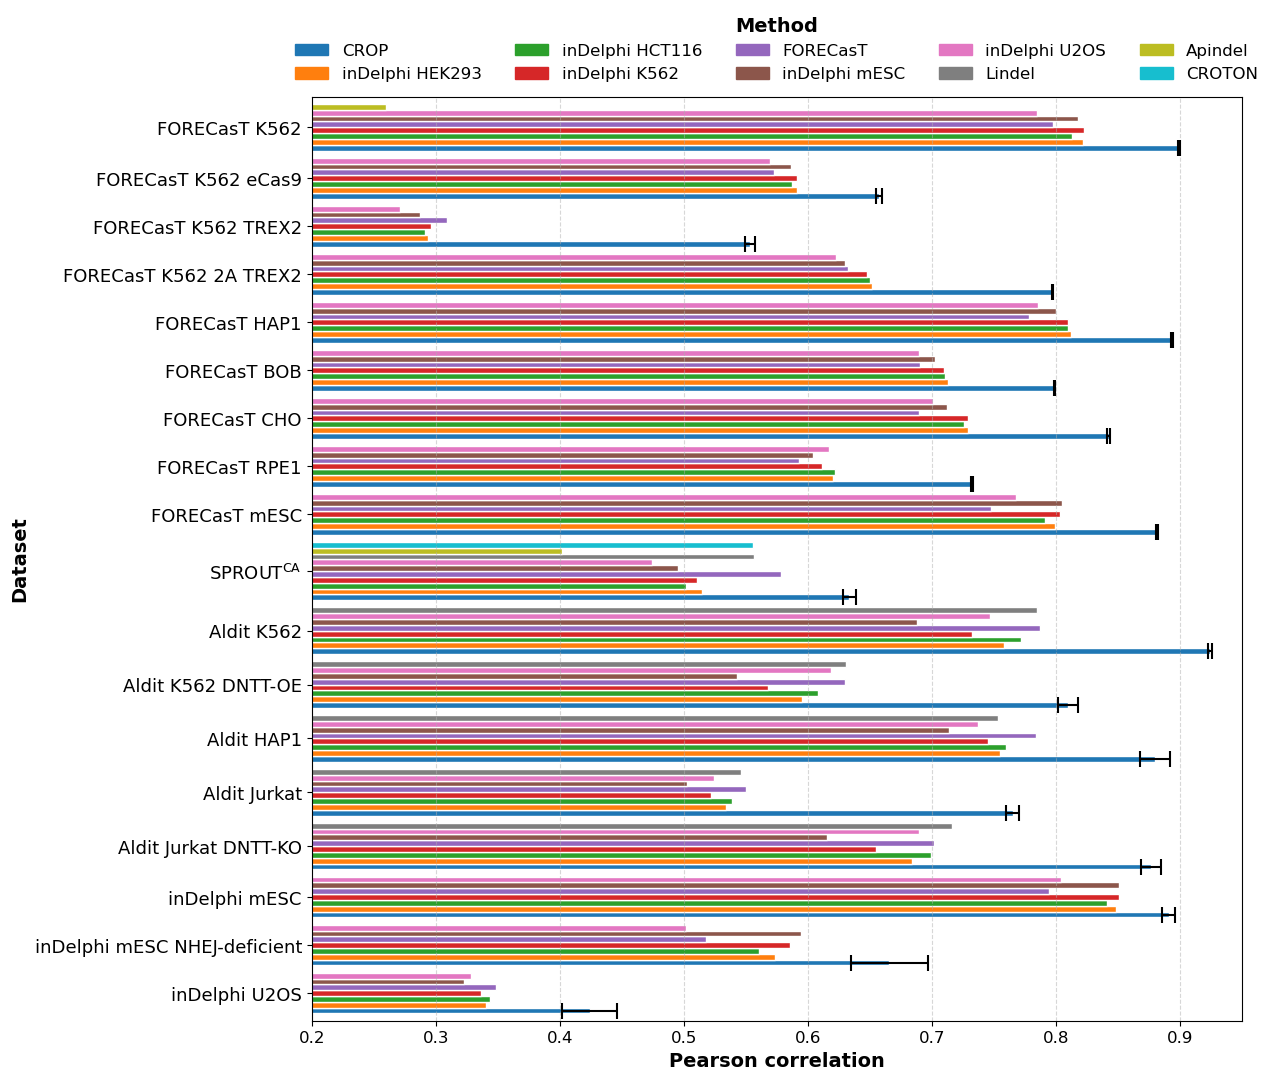


CROP Mean and STD for each dataset:
FORECasT K562: Mean = 0.8999, STD = 0.0008
FORECasT K562 eCas9: Mean = 0.6576, STD = 0.0021
FORECasT K562 TREX2: Mean = 0.5533, STD = 0.0042
FORECasT K562 2A TREX2: Mean = 0.7975, STD = 0.0007
FORECasT HAP1: Mean = 0.8940, STD = 0.0007
FORECasT BOB: Mean = 0.7991, STD = 0.0007
FORECasT CHO: Mean = 0.8430, STD = 0.0012
FORECasT RPE1: Mean = 0.7324, STD = 0.0009
FORECasT mESC: Mean = 0.8816, STD = 0.0009
SPROUT$^{\mathrm{CA}}$: Mean = 0.6337, STD = 0.0049
Aldit K562: Mean = 0.9245, STD = 0.0019
Aldit K562 DNTT-OE: Mean = 0.8101, STD = 0.0082
Aldit HAP1: Mean = 0.8803, STD = 0.0124
Aldit Jurkat: Mean = 0.7654, STD = 0.0053
Aldit Jurkat DNTT-KO: Mean = 0.8767, STD = 0.0078
inDelphi mESC: Mean = 0.8912, STD = 0.0053
inDelphi mESC NHEJ-deficient: Mean = 0.6657, STD = 0.0311
inDelphi U2OS: Mean = 0.4242, STD = 0.0222

Success: Plot saved as output/pearson_bar_plot_custom.pdf


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_pearson_bar_custom(csv_path, output_name='pearson_bar_plot.png', crop_errorbar_y_offsets=None):
    """
    Plots the Pearson correlation matrix as a grouped bar chart.
    - SORTING: Models ordered by Frequency (Count) -> Average Pearson.
    - LAYOUT: Variable row height (datasets with missing models take less space).
    - FORMATTING: Uses LaTeX formatting for SPROUT.

    crop_errorbar_y_offsets: dict[int, float] | None
        Per-CROP-errorbar vertical offsets (in data y-units) keyed by the
        dataset plot order index (0 = first dataset plotted). If None, defaults are used.
    """
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Cleanup
    df = df.dropna(axis=1, how='all')
    df.index = [str(i).replace('.csv', '') for i in df.index]

    # --- STEP A: Rename DATASETS (Rows) ---
    dataset_rename_map = {
        'FORECasT_K562':           'FORECasT K562',
        'FORECasT_K562_eCAS9':     'FORECasT K562 eCas9',
        'FORECasT_K562_TREX2':     'FORECasT K562 TREX2',
        'FORECasT_K562_2A_TREX2':  'FORECasT K562 2A TREX2',
        'FORECasT_HAP1':           'FORECasT HAP1',
        'FORECasT_BOB':            'FORECasT BOB',
        'FORECasT_CHO':            'FORECasT CHO',
        'FORECasT_RPE1':           'FORECasT RPE1',
        'FORECasT_mESC':           'FORECasT mESC',
        'SPROUT_T_CROTON_VERSION': r'SPROUT$^{\mathrm{CA}}$',
        'ALDIT_K562':              'Aldit K562',
        'ALDIT_K562_DNTTOE':       'Aldit K562 DNTT-OE',
        'ALDIT_HAP1':              'Aldit HAP1',
        'ALDIT_Jurkat':            'Aldit Jurkat',
        'ALDIT_Jurkat_DNTTKO':     'Aldit Jurkat DNTT-KO',
        'XCRISP_inDelphi_mESC':                'inDelphi mESC',
        'XCRISP_inDelphi_mESC_NHEJdeficient':  'inDelphi mESC NHEJ-deficient',
        'XCRISP_inDelphi_U2OS':                'inDelphi U2OS'
    }
    df = df.rename(index=dataset_rename_map)

    # --- STEP B: Rename MODELS (Columns) ---
    model_rename_map = {
        'FORECasT_FS_ratio':  'FORECasT',
        'Lindel_FS_ratio':    'Lindel',
        'inDelphi_FS_HCT116': 'inDelphi HCT116',
        'inDelphi_FS_HEK293': 'inDelphi HEK293',
        'inDelphi_FS_K562':   'inDelphi K562',
        'inDelphi_FS_U2OS':   'inDelphi U2OS',
        'inDelphi_FS_mESC':   'inDelphi mESC',
        'Apindel':            'Apindel',
        'CROTON':             'CROTON',
        'CROP':               'CROP'
    }
    df = df.rename(columns=model_rename_map)

    # --- STEP C: Get CROP values from seed reruns ---
    import os
    import numpy as np
    crop_values = {d: [] for d in df.index}
    
    dataset_to_forced_embed = {
        'FORECasT K562': 'FORECasT K562',
        'FORECasT K562 eCas9': 'FORECasT eCAS9',
        'FORECasT K562 TREX2': 'FORECasT TREX2',
        'FORECasT K562 2A TREX2': 'FORECasT 2A TREX2',
        'FORECasT HAP1': 'FORECasT HAP1',
        'FORECasT BOB': 'FORECasT BOB',
        'FORECasT CHO': 'FORECasT CHO',
        'FORECasT RPE1': 'FORECasT RPE1',
        'FORECasT mESC': 'FORECasT mESC',
        r'SPROUT$^{\mathrm{CA}}$': 'FORECasT K562',
        'Aldit K562': 'Aldit K562',
        'Aldit K562 DNTT-OE': 'Aldit K562 DNTTOE',
        'Aldit HAP1': 'Aldit HAP1',
        'Aldit Jurkat': 'Aldit Jurkat',
        'Aldit Jurkat DNTT-KO': 'Aldit Jurkat DNTTKO',
        'inDelphi mESC': 'InDelphi mESC',
        'inDelphi mESC NHEJ-deficient': 'InDelphi mESC NHEJdeficient',
        'inDelphi U2OS': 'InDelphi U2OS'
    }
    
    for seed in [2, 3, 4, 5]:
        seed_path = f'VOM/reruns/seed_{seed}/pearson_matrix.csv'
        if os.path.exists(seed_path):
            seed_df = pd.read_csv(seed_path, index_col=0)
            for df_idx, embed_name in dataset_to_forced_embed.items():
                if df_idx not in df.index:
                    continue
                seed_idx = df_idx
                if df_idx == r'SPROUT$^{\mathrm{CA}}$': seed_idx = 'SPROUT T'
                elif df_idx == 'FORECasT K562 eCas9': seed_idx = 'FORECasT eCAS9'
                elif df_idx == 'FORECasT K562 TREX2': seed_idx = 'FORECasT TREX2'
                elif df_idx == 'FORECasT K562 2A TREX2': seed_idx = 'FORECasT 2A TREX2'
                elif df_idx == 'Aldit K562 DNTT-OE': seed_idx = 'Aldit K562 DNTTOE'
                elif df_idx == 'Aldit Jurkat DNTT-KO': seed_idx = 'Aldit Jurkat DNTTKO'
                elif df_idx == 'inDelphi mESC NHEJ-deficient': seed_idx = 'InDelphi mESC NHEJdeficient'
                elif df_idx == 'inDelphi mESC': seed_idx = 'InDelphi mESC'
                elif df_idx == 'inDelphi U2OS': seed_idx = 'InDelphi U2OS'
                
                if seed_idx in seed_df.index and embed_name in seed_df.columns:
                    val = seed_df.loc[seed_idx, embed_name]
                    if not pd.isna(val):
                        crop_values[df_idx].append(val)
                        
    for idx, val in df['CROP'].items():
        if not pd.isna(val):
            crop_values[idx].append(val)

    crop_errors = {}
    for idx in df.index:
        if crop_values[idx]:
            df.at[idx, 'CROP'] = np.mean(crop_values[idx])
            crop_errors[idx] = np.std(crop_values[idx])
        else:
            df.at[idx, 'CROP'] = np.nan
            crop_errors[idx] = 0

    # --- STEP D: Enforce Dataset Order ---
    dataset_order = [
        'FORECasT K562', 'FORECasT K562 eCas9', 'FORECasT K562 TREX2', 'FORECasT K562 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        r'SPROUT$^{\mathrm{CA}}$',
        'Aldit K562', 'Aldit K562 DNTT-OE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTT-KO',
        'inDelphi mESC', 'inDelphi mESC NHEJ-deficient', 'inDelphi U2OS'
    ]
    # Filter to only datasets present in the file
    existing_dataset_order = [x for x in dataset_order if x in df.index]
    df = df.reindex(existing_dataset_order)

    # --- STEP E: DATA-DRIVEN MODEL SORTING ---
    # 1. Calculate Count (Frequency of non-NaNs)
    model_counts = df.count()
    # 2. Calculate Average Pearson
    model_means = df.mean(skipna=True)
    
    # Create a temporary sorting dataframe
    sort_df = pd.DataFrame({'count': model_counts, 'mean': model_means})
    
    # Sort by Count (Descending), then Mean (Descending)
    sort_df = sort_df.sort_values(by=['count', 'mean'], ascending=[False, False])
    
    # Extract the new sorted list of models
    sorted_models = list(sort_df.index)
    
    # Reorder DataFrame columns
    df = df[sorted_models]

    # --- STEP F: MANUAL PLOTTING (For Variable Height) ---
    # We cannot use sns.barplot easily for variable heights. 
    # We will iterate and plot bars manually using plt.barh
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Define colors
    palette = sns.color_palette("tab10", n_colors=len(sorted_models))
    color_map = dict(zip(sorted_models, palette))
    
    bar_height = 0.8  # Thickness of individual bars
    group_gap = 1.0   # Space between dataset groups
    
    # Precompute total height and set ylim first so bar and error-bar coords stay consistent
    total_height = 0
    for dataset in reversed(existing_dataset_order):
        row_data = df.loc[dataset]
        valid_models_pre = [m for m in sorted_models if m in row_data.dropna().index]
        if valid_models_pre:
            total_height += len(valid_models_pre) * bar_height + group_gap
    ax.set_ylim(-1, total_height)
    ax.set_xlim(0.2, 0.95)
    
    y_cursor = 0
    y_ticks_pos = []
    y_ticks_labels = []
    crop_error_bars = []  # (plot_dataset_idx, dataset, patch, std) for second-pass drawing
    plot_dataset_idx = 0   # 0 = first dataset we plot
    
    # Pass 1: draw all bars; record CROP bar patches for error bars
    for dataset in reversed(existing_dataset_order):
        # Get valid data for this dataset
        row_data = df.loc[dataset]
        valid_models = row_data.dropna().index.tolist()
        
        # Ensure valid models follow our sorted global order
        valid_models = [m for m in sorted_models if m in valid_models]
        
        if not valid_models:
            continue # Skip empty datasets

        current_plot_idx = plot_dataset_idx
        plot_dataset_idx += 1
            
        # Bar layout: bar i has bottom at (y_cursor + i*bar_height), top at (y_cursor + (i+1)*bar_height)
        num_bars = len(valid_models)
        
        for i, model in enumerate(valid_models):
            bar_bottom = y_cursor + i * bar_height
            value = row_data[model]
            bc = ax.barh(
                bar_bottom, value, height=bar_height, left=0,
                align='edge', color=color_map[model], edgecolor='white', linewidth=1.0
            )
            if model == 'CROP' and crop_errors.get(dataset, 0) > 0:
                crop_error_bars.append((current_plot_idx, dataset, bc.patches[0], float(crop_errors[dataset])))
        
        # Store label position (center of the group)
        center_y = y_cursor + (num_bars * bar_height) / 2
        y_ticks_pos.append(center_y)
        y_ticks_labels.append(dataset)
        
        # Update cursor for the next group
        y_cursor += (num_bars * bar_height) + group_gap
    
    # Pass 2: draw CROP error bars using each bar patch's actual center.
    # Robust to datasets with missing models: anchor both x and y to the patch geometry.
    # Ensure artists are fully realized before querying patch geometry.
    fig.canvas.draw()

    # Manual per-dataset y adjustments (data y-units) for the CROP error bar.
    # Keyed by plot order index: 0 = first dataset we plot, 1 = second, ...
    # Default: lower all by 0.05
    # Overrides requested:
    # - #14 lower by 0.10
    # - #15 lower by 0.10
    # - #17 no change (0.00)
    default_offsets = {
        "__default__": -0.05,
        14: -0.10,
        15: -0.10,
        17: 0.00,
    }
    offsets = default_offsets if crop_errorbar_y_offsets is None else {
        "__default__": crop_errorbar_y_offsets.get("__default__", -0.05),
        **{k: v for k, v in crop_errorbar_y_offsets.items() if k != "__default__"},
    }

    for j, (plot_idx, dataset, patch, std) in enumerate(crop_error_bars):
        # --- DEBUG: bar geometry vs errorbar anchor (no logic changes) ---
        y0 = patch.get_y()
        h = patch.get_height()
        y_mid = y0 + h / 2.0
        x0 = patch.get_x()
        w = patch.get_width()
        x_end = x0 + w

        cx = x_end
        cy = y_mid

        # Apply manual y adjustment (by dataset plot order index)
        y_adj = offsets.get(plot_idx, offsets.get("__default__", 0.0))
        cy_adj = cy + y_adj

        print(
            f"CROP bar #{j} (plot_idx={plot_idx}, dataset='{dataset}'): "
            f"y_start={y0:.6f} y_mid={y_mid:.6f} y_end={(y0 + h):.6f} | "
            f"x_start={x0:.6f} x_end={x_end:.6f} | std={std:.6f} | "
            f"errorbar_at=(x={cx:.6f}, y={cy:.6f}) y_adj={y_adj:+.3f} => (x={cx:.6f}, y={cy_adj:.6f})"
        )

        ax.errorbar(
            x=cx,
            y=cy_adj,
            xerr=std,
            fmt='none',
            ecolor='black',
            elinewidth=1.5,
            capsize=6,
            capthick=1.5,
            zorder=10,
        )

    # --- G. Aesthetics ---
    ax.set_xlabel('Pearson correlation', fontsize=14, fontweight='bold')
    ax.set_ylabel('Dataset', fontsize=14, fontweight='bold')
    ax.set_yticks(y_ticks_pos, y_ticks_labels, fontsize=13)
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    # Manual Legend Creation
    patches = [mpatches.Patch(color=color_map[m], label=m) for m in sorted_models]
    leg = ax.legend(
        handles=patches,
        loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=5, title='Method',
        frameon=False, fontsize=12, title_fontsize=14
    )
    plt.setp(leg.get_title(), fontweight='bold')
    plt.savefig(output_name, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # --- STEP G: Print CROP Statistics ---
    print("\nCROP Mean and STD for each dataset:")
    for dataset in dataset_order:
        if dataset in df.index:
            mean_val = df.loc[dataset, 'CROP']
            std_val = crop_errors.get(dataset, 0)
            print(f"{dataset}: Mean = {mean_val:.4f}, STD = {std_val:.4f}")

    print(f"\nSuccess: Plot saved as {output_name}")

# Execute
plot_pearson_bar_custom(
    'VOM/pearson_ex3_CROTON_APINDEL_with_CROP.csv',
    output_name='output/pearson_bar_plot_custom.pdf',
    # You can edit this dict to tweak alignment
    crop_errorbar_y_offsets={
        "__default__": -0.05,
        3: -0.1,
        4: -0.117,
        8: -0.025,
    },
)

In [3]:
from scipy.stats import ranksums
import pandas as pd

def calculate_rank_sum_test(csv_path):
    # Load data
    df = pd.read_csv(csv_path, index_col=0)
    
    # Clean column names to match your rename map logic
    model_rename_map = {
        'FORECasT_FS_ratio': 'FORECasT', 'Lindel_FS_ratio': 'Lindel',
        'inDelphi_FS_HCT116': 'inDelphi HCT116', 'inDelphi_FS_HEK293': 'inDelphi HEK293',
        'inDelphi_FS_K562': 'inDelphi K562', 'inDelphi_FS_U2OS': 'inDelphi U2OS',
        'inDelphi_FS_mESC': 'inDelphi mESC', 'Apindel': 'Apindel',
        'CROTON': 'CROTON', 'CROP': 'CROP'
    }
    df = df.rename(columns=model_rename_map)
    
    # We compare CROP against every other model
    target_model = 'CROP'
    results = []
    
    if target_model not in df.columns:
        print(f"Error: {target_model} not found in CSV.")
        return

    for model in df.columns:
        if model == target_model:
            continue
        
        # Drop NaNs to get paired samples where both models have results
        # or use all available data for independent rank-sum
        group_crop = df[target_model].dropna()
        group_other = df[model].dropna()
        
        # Perform Wilcoxon Rank-Sum (Mann-Whitney U)
        statistic, p_value = ranksums(group_crop, group_other, alternative='greater')
        
        results.append({
            'Comparison': f'{target_model} > {model}',
            'Rank-Sum Statistic': statistic,
            'p-value': p_value,
            'Significant (0.05)': 'Yes' if p_value < 0.05 else 'No'
        })
    
    # Display results
    results_df = pd.DataFrame(results)
    print("\n--- Wilcoxon Rank-Sum Test Results (Alternative: CROP > Other) ---")
    print(results_df.to_string(index=False))
    return results_df

# --- Baseline (keep this output) ---
BASELINE_CSV = 'VOM/pearson_ex3_CROTON_APINDEL_with_CROP.csv'

all_results = {}
all_results[BASELINE_CSV] = calculate_rank_sum_test(BASELINE_CSV)

# --- Augment: swap ONLY the CROP column using the new CROP result matrices ---
# Keep all other methods exactly as in the baseline VOM/pearson_ex3... dataframe.
# For each dataset, pick the forced-embedding cell from the new matrix.
# For SPROUT, use the FORECasT K562 forced embedding.

# Re-load + normalize baseline exactly like the plotting code (index + model names)
baseline_df = pd.read_csv(BASELINE_CSV, index_col=0)
baseline_df = baseline_df.dropna(axis=1, how='all')
baseline_df.index = [str(i).replace('.csv', '') for i in baseline_df.index]

# Dataset rename map (copied from plot code)
dataset_rename_map = {
    'FORECasT_K562':           'FORECasT K562',
    'FORECasT_K562_eCAS9':     'FORECasT K562 eCas9',
    'FORECasT_K562_TREX2':     'FORECasT K562 TREX2',
    'FORECasT_K562_2A_TREX2':  'FORECasT K562 2A TREX2',
    'FORECasT_HAP1':           'FORECasT HAP1',
    'FORECasT_BOB':            'FORECasT BOB',
    'FORECasT_CHO':            'FORECasT CHO',
    'FORECasT_RPE1':           'FORECasT RPE1',
    'FORECasT_mESC':           'FORECasT mESC',
    'SPROUT_T_CROTON_VERSION': r'SPROUT$^{\\mathrm{CA}}$',
    'ALDIT_K562':              'Aldit K562',
    'ALDIT_K562_DNTTOE':       'Aldit K562 DNTT-OE',
    'ALDIT_HAP1':              'Aldit HAP1',
    'ALDIT_Jurkat':            'Aldit Jurkat',
    'ALDIT_Jurkat_DNTTKO':     'Aldit Jurkat DNTT-KO',
    'XCRISP_inDelphi_mESC':                'inDelphi mESC',
    'XCRISP_inDelphi_mESC_NHEJdeficient':  'inDelphi mESC NHEJ-deficient',
    'XCRISP_inDelphi_U2OS':                'inDelphi U2OS'
}

model_rename_map = {
    'FORECasT_FS_ratio': 'FORECasT',
    'Lindel_FS_ratio': 'Lindel',
    'inDelphi_FS_HCT116': 'inDelphi HCT116',
    'inDelphi_FS_HEK293': 'inDelphi HEK293',
    'inDelphi_FS_K562': 'inDelphi K562',
    'inDelphi_FS_U2OS': 'inDelphi U2OS',
    'inDelphi_FS_mESC': 'inDelphi mESC',
    'Apindel': 'Apindel',
    'CROTON': 'CROTON',
    'CROP': 'CROP'
}

baseline_df = baseline_df.rename(index=dataset_rename_map)
baseline_df = baseline_df.rename(columns=model_rename_map)

# Dataset -> forced embedding selection (SPROUT uses FORECasT K562)
dataset_to_forced_embed = {
    'FORECasT K562': 'FORECasT K562',
    'FORECasT K562 eCas9': 'FORECasT eCAS9',
    'FORECasT K562 TREX2': 'FORECasT TREX2',
    'FORECasT K562 2A TREX2': 'FORECasT 2A TREX2',
    'FORECasT HAP1': 'FORECasT HAP1',
    'FORECasT BOB': 'FORECasT BOB',
    'FORECasT CHO': 'FORECasT CHO',
    'FORECasT RPE1': 'FORECasT RPE1',
    'FORECasT mESC': 'FORECasT mESC',
    r'SPROUT$^{\\mathrm{CA}}$': 'FORECasT K562',
    'Aldit K562': 'Aldit K562',
    'Aldit K562 DNTT-OE': 'Aldit K562 DNTTOE',
    'Aldit HAP1': 'Aldit HAP1',
    'Aldit Jurkat': 'Aldit Jurkat',
    'Aldit Jurkat DNTT-KO': 'Aldit Jurkat DNTTKO',
    'inDelphi mESC': 'InDelphi mESC',
    'inDelphi mESC NHEJ-deficient': 'InDelphi mESC NHEJdeficient',
    'inDelphi U2OS': 'InDelphi U2OS'
}

NEW_CROP_CSVS = [
    'VOM/reruns/seed_2/pearson_matrix.csv',
    'VOM/reruns/seed_3/pearson_matrix.csv',
    'VOM/reruns/seed_4/pearson_matrix.csv',
    'VOM/reruns/seed_5/pearson_matrix.csv',
]

for new_csv in NEW_CROP_CSVS:
    seed_df = pd.read_csv(new_csv, index_col=0)

    # Create new CROP column values from the forced-embed matrix
    new_crop = pd.Series(index=baseline_df.index, dtype=float)

    for df_idx, embed_name in dataset_to_forced_embed.items():
        if df_idx not in baseline_df.index:
            continue

        seed_idx = df_idx
        if df_idx == r'SPROUT$^{\\mathrm{CA}}$': seed_idx = 'SPROUT T'
        elif df_idx == 'FORECasT K562 eCas9': seed_idx = 'FORECasT eCAS9'
        elif df_idx == 'FORECasT K562 TREX2': seed_idx = 'FORECasT TREX2'
        elif df_idx == 'FORECasT K562 2A TREX2': seed_idx = 'FORECasT 2A TREX2'
        elif df_idx == 'Aldit K562 DNTT-OE': seed_idx = 'Aldit K562 DNTTOE'
        elif df_idx == 'Aldit Jurkat DNTT-KO': seed_idx = 'Aldit Jurkat DNTTKO'
        elif df_idx == 'inDelphi mESC NHEJ-deficient': seed_idx = 'InDelphi mESC NHEJdeficient'
        elif df_idx == 'inDelphi mESC': seed_idx = 'InDelphi mESC'
        elif df_idx == 'inDelphi U2OS': seed_idx = 'InDelphi U2OS'

        if seed_idx in seed_df.index and embed_name in seed_df.columns:
            val = seed_df.loc[seed_idx, embed_name]
            if not pd.isna(val):
                new_crop.loc[df_idx] = val

    swapped = baseline_df.copy()
    swapped['CROP'] = new_crop

    print("\n" + "=" * 100)
    print(f"AUGMENTED: baseline methods + CROP swapped using {new_csv}")
    print("=" * 100)

    print(f"DEBUG: DATAFRAME USED:")
    print(swapped.to_string(index=True))
    print("=" * 100)
    

    # Run the same rank-sum code on the swapped dataframe
    target_model = 'CROP'
    results = []
    for model in swapped.columns:
        if model == target_model:
            continue
        group_crop = swapped[target_model].dropna()
        group_other = swapped[model].dropna()
        statistic, p_value = ranksums(group_crop, group_other, alternative='greater')
        results.append({
            'Comparison': f'{target_model} > {model}',
            'Rank-Sum Statistic': statistic,
            'p-value': p_value,
            'Significant (0.05)': 'Yes' if p_value < 0.05 else 'No'
        })

    results_df = pd.DataFrame(results)
    print("\n--- Wilcoxon Rank-Sum Test Results (Alternative: CROP > Other) ---")
    print(results_df.to_string(index=False))
    all_results[new_csv] = results_df

# all_results is a dict: path -> DataFrame


--- Wilcoxon Rank-Sum Test Results (Alternative: CROP > Other) ---
            Comparison  Rank-Sum Statistic  p-value Significant (0.05)
       CROP > FORECasT            2.815835 0.002433                Yes
         CROP > Lindel            1.933333 0.026598                Yes
CROP > inDelphi HCT116            2.562727 0.005193                Yes
CROP > inDelphi HEK293            2.531088 0.005685                Yes
  CROP > inDelphi K562            2.562727 0.005193                Yes
  CROP > inDelphi U2OS            2.847474 0.002203                Yes
  CROP > inDelphi mESC            2.752558 0.002957                Yes
        CROP > Apindel            2.267787 0.011671                Yes
         CROP > CROTON            1.460593 0.072064                 No
    CROP > Unnamed: 11                 NaN      NaN                 No

AUGMENTED: baseline methods + CROP swapped using VOM/reruns/seed_2/pearson_matrix.csv
DEBUG: DATAFRAME USED:
                              FORECasT   

C:\Users\tzion\AppData\Local\Temp\ipykernel_6804\3791411215.py:36: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  statistic, p_value = ranksums(group_crop, group_other, alternative='greater')


# Val plots

In [35]:
import re
import collections
import pandas as pd

file_path = 'VLT/ex0.log'

# Data storage: all_data[run_id][epoch][metric_or_dataset] = value
all_data = collections.defaultdict(lambda: collections.defaultdict(dict))
current_run = None
current_epoch = 0
epoch_offset = 0
last_raw_epoch = 0

# Regex Patterns
RE_RUN = r'=== SPLIT WITH VAL BUCKET (\d+) ==='
RE_EPOCH_HEAD = r'={16} EPOCH (\d+) ={17}'
RE_PEARSON = r'^(.*?)\s+\|\s+Pearson:\s+([0-9\.]+|nan)'
RE_VAL_LOSS = r'.*?val_val_loss:\s+([0-9\.]+)'

with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        
        # 1. Detect Split/Run
        run_match = re.search(RE_RUN, line)
        if run_match:
            current_run = int(run_match.group(1))
            epoch_offset = 0
            last_raw_epoch = 0
            continue

        # 2. Detect Epoch header and handle 50 + 10 logic
        epoch_match = re.search(RE_EPOCH_HEAD, line)
        if epoch_match:
            raw_epoch = int(epoch_match.group(1))
            # If counter resets to 1 after being at 50, we are in the +10 phase
            if raw_epoch == 1 and last_raw_epoch >= 50:
                epoch_offset = 50
            
            current_epoch = raw_epoch + epoch_offset
            last_raw_epoch = raw_epoch
            continue

        # 3. Detect Dataset Pearson lines (Table lines)
        data_match = re.search(RE_PEARSON, line)
        if data_match and current_run is not None:
            ds_name = data_match.group(1).strip()
            val = data_match.group(2)
            pearson = float(val) if val != 'nan' else None
            all_data[current_run][current_epoch][ds_name] = pearson
            continue

        # 4. Detect the specific progress line for Val Loss
        loss_match = re.search(RE_VAL_LOSS, line)
        if loss_match and current_run is not None:
            # Storing val_loss alongside the pearson metrics
            all_data[current_run][current_epoch]['FULL_VAL_LOSS'] = float(loss_match.group(1))

# --- OUTPUT GENERATION ---

# 1. Print Separate Runs
for run in sorted(all_data.keys()):
    print(f"\n>>> RUN {run} (1-60 Epochs) <<<")
    df_run = pd.DataFrame(all_data[run]).T.sort_index()
    # Ensure columns are organized (Val Loss first, then datasets)
    cols = ['FULL_VAL_LOSS'] + [c for c in df_run.columns if c != 'FULL_VAL_LOSS']
    print(df_run[cols].to_string())

# 2. Calculate and Print Averages
print("\n" + "="*50)
print("AVERAGED METRICS OVER ALL RUNS")
print("="*50)

# Build list for aggregation
flat_records = []
for run, epochs in all_data.items():
    for ep, metrics in epochs.items():
        row = {'epoch': ep, **metrics}
        flat_records.append(row)

if flat_records:
    avg_df = pd.DataFrame(flat_records).groupby('epoch').mean().sort_index()
    print(avg_df.to_string())
else:
    print("No data found matching the specific patterns.")


>>> RUN 0 (1-60 Epochs) <<<
    FULL_VAL_LOSS  FORECasT K562  FORECasT mESC  FORECasT BOB  FORECasT CHO  FORECasT HAP1  FORECasT RPE1  FORECasT TREX2  FORECasT 2A TREX2  FORECasT eCAS9  SPROUT T  Aldit K562  Aldit Jurkat  Aldit HAP1  Aldit K562 DNTTOE  Aldit Jurkat DNTTKO  InDelphi mESC  InDelphi mESC NHEJdeficient  InDelphi U2OS
1          0.5855          0.382          0.339         0.362         0.402          0.411          0.369           0.174              0.406           0.269       NaN       0.656         0.469       0.493              0.572                0.698          0.419                        0.248          0.340
2          0.5439          0.495          0.506         0.479         0.491          0.524          0.438           0.244              0.449           0.334       NaN       0.762         0.573       0.635              0.640                0.749          0.598                        0.353          0.411
3          0.5030          0.603          0.610         0.5

In [36]:
import matplotlib.pyplot as plt
import os

# 3. Plotting and Saving to PDFs
output_folder = 'output/val_plots/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

if not avg_df.empty:
    print(f"\nGenerating plots in /{output_folder}...")
    
    for column in avg_df.columns:
        plt.figure(figsize=(10, 6))
        
        # Plot the data
        plt.plot(avg_df.index, avg_df[column], marker='o', linestyle='-', linewidth=1.5, markersize=4)
        
        # Remove Title and Set Labels
        # Determine if label should be "Loss" or "Pearson"
        y_label = "Validation loss" if "LOSS" in column.upper() else "Pearson correlation"
        
        plt.xlabel('Epoch', fontsize=20)
        plt.ylabel(y_label, fontsize=20)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Formatting filename (replacing spaces/slashes for safety)
        safe_filename = column.replace(' ', '_').replace('/', '_')
        pdf_path = os.path.join(output_folder, f"{safe_filename}.pdf")
        
        # Save as PDF
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        plt.close()  # Close plot to save memory
        print(f"Saved: {pdf_path}")
        
    print("\nAll plots have been saved successfully.")
else:
    print("No data available to plot.")


Generating plots in /output/val_plots/...
Saved: output/val_plots/FORECasT_K562.pdf
Saved: output/val_plots/FORECasT_mESC.pdf
Saved: output/val_plots/FORECasT_BOB.pdf
Saved: output/val_plots/FORECasT_CHO.pdf
Saved: output/val_plots/FORECasT_HAP1.pdf
Saved: output/val_plots/FORECasT_RPE1.pdf
Saved: output/val_plots/FORECasT_TREX2.pdf
Saved: output/val_plots/FORECasT_2A_TREX2.pdf
Saved: output/val_plots/FORECasT_eCAS9.pdf
Saved: output/val_plots/SPROUT_T.pdf
Saved: output/val_plots/Aldit_K562.pdf
Saved: output/val_plots/Aldit_Jurkat.pdf
Saved: output/val_plots/Aldit_HAP1.pdf
Saved: output/val_plots/Aldit_K562_DNTTOE.pdf
Saved: output/val_plots/Aldit_Jurkat_DNTTKO.pdf
Saved: output/val_plots/InDelphi_mESC.pdf
Saved: output/val_plots/InDelphi_mESC_NHEJdeficient.pdf
Saved: output/val_plots/InDelphi_U2OS.pdf
Saved: output/val_plots/FULL_VAL_LOSS.pdf

All plots have been saved successfully.


# Ablation

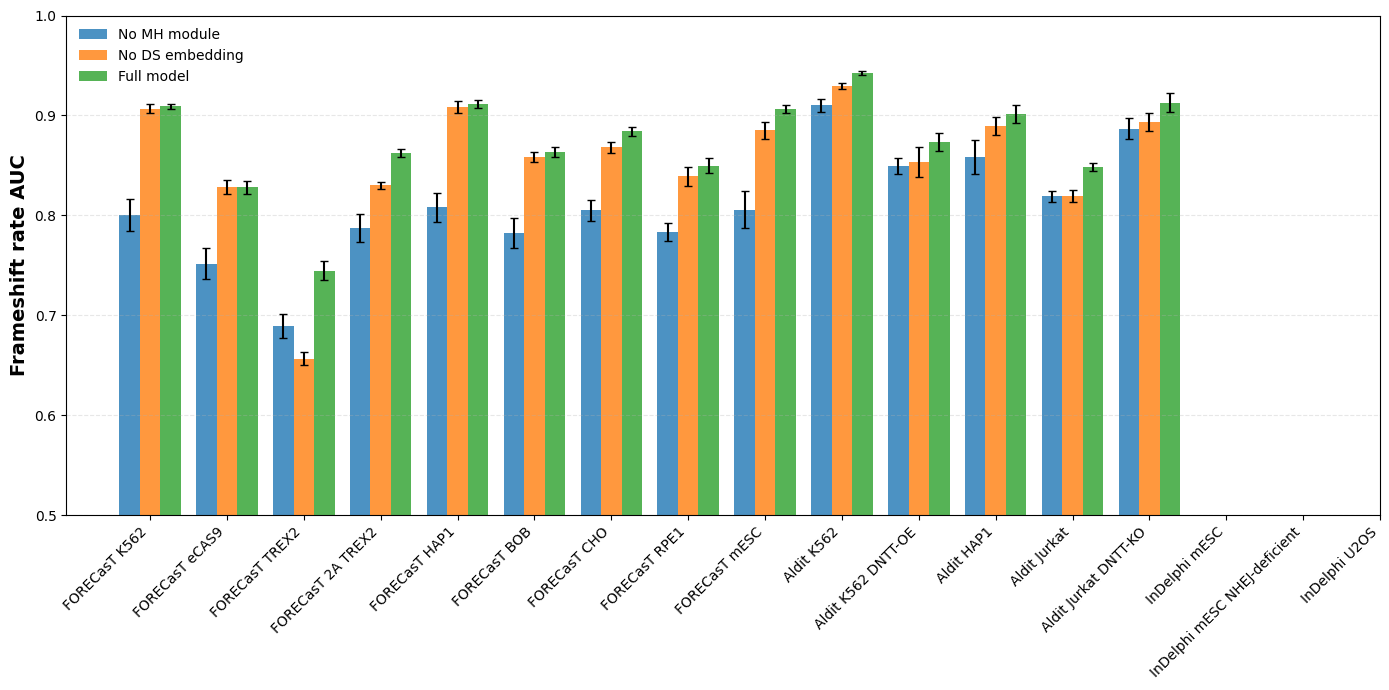

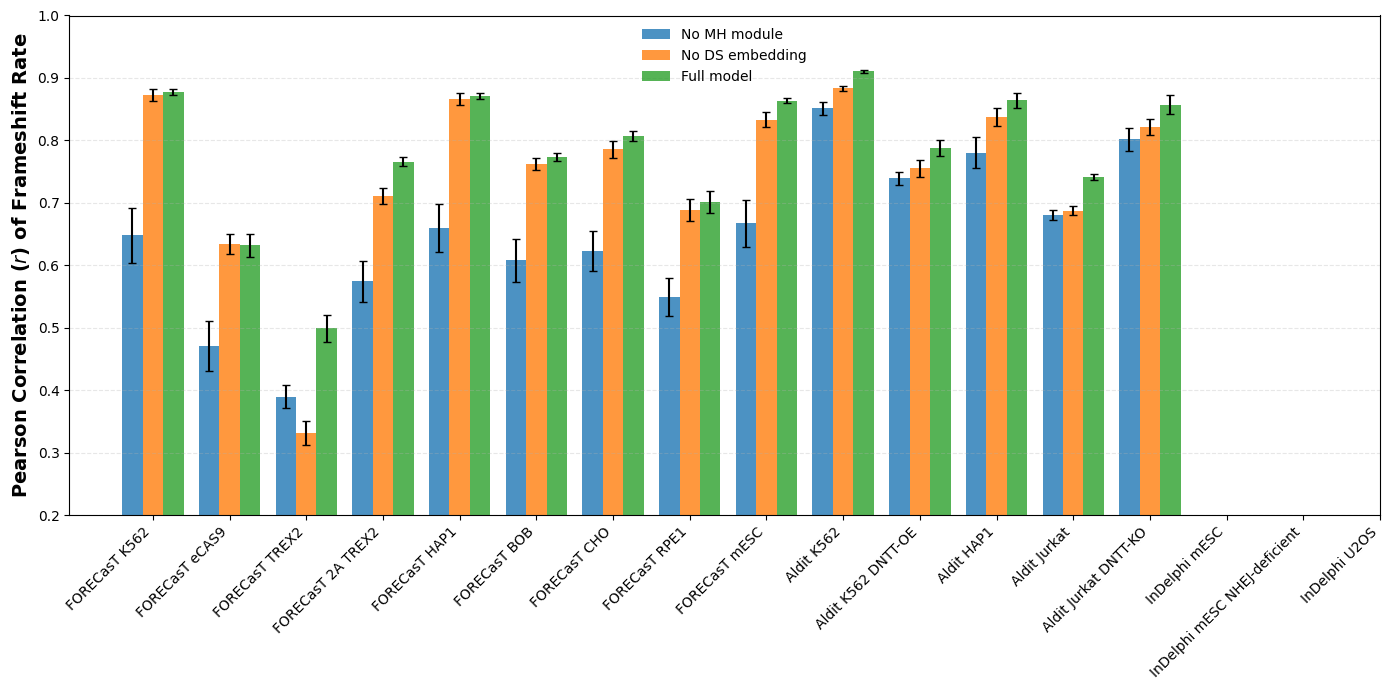

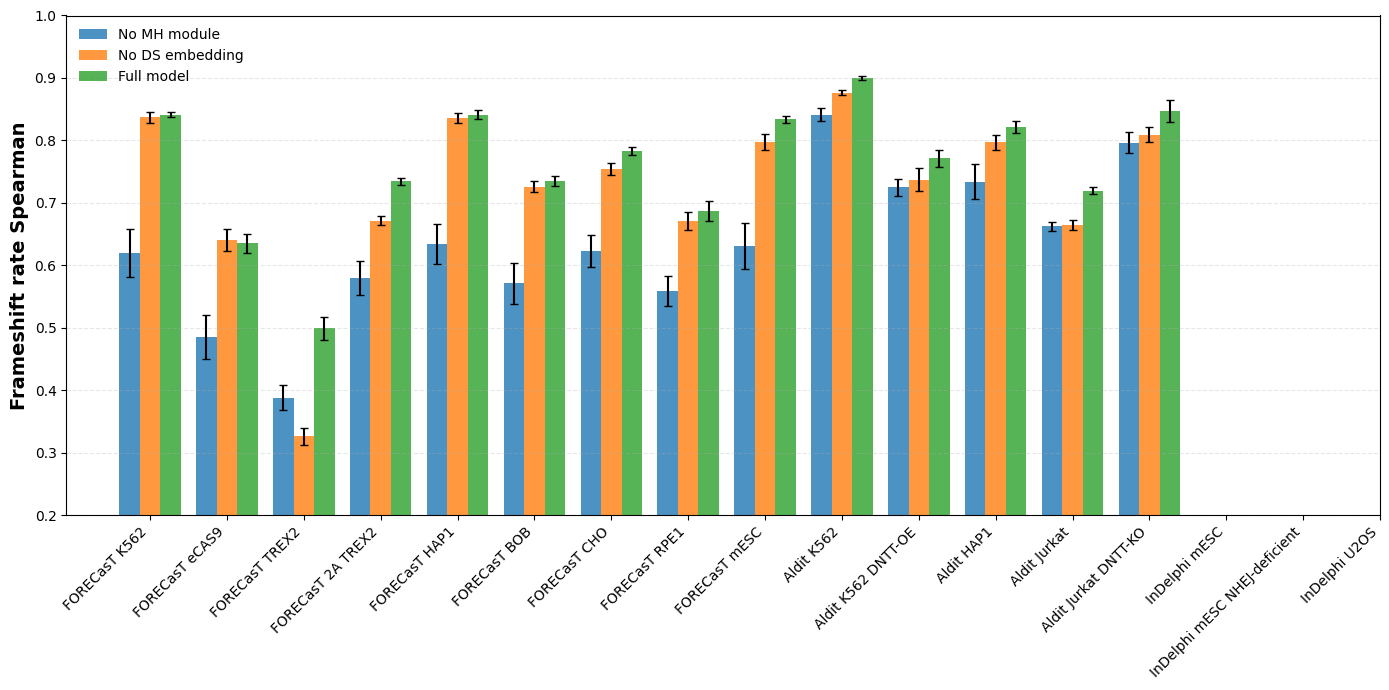

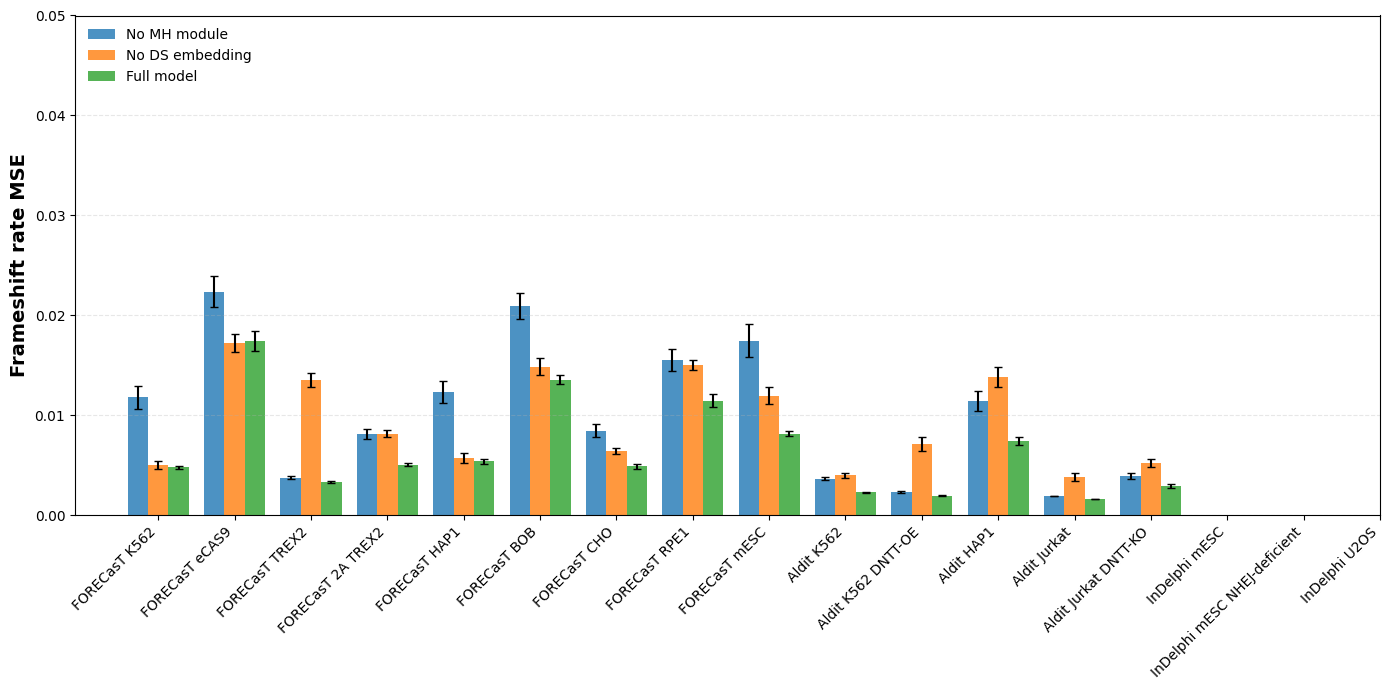

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon
from itertools import combinations

def generate_ablation_plots():
    # 1. Mapping of original CSV row indices to dataset names
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTT-KO",
        3: "Aldit K562", 4: "Aldit K562 DNTT-OE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "inDelphi U2OS",
        15: "inDelphi mESC", 16: "inDelphi mESC NHEJ-deficient"
    }

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }

    # 2. Target sort order
    target_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTT-OE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTT-KO",
        "InDelphi mESC", "InDelphi mESC NHEJ-deficient", "InDelphi U2OS"
    ]

    base_folder = 'AB'
    output_folder = os.path.join('output', 'abalation')
    metrics = ['AUC', 'Pearson', 'Spearman', 'MSE']
    
    y_lims_per_metric = {
        'AUC': (0.5, 1.0),
        'Pearson': (0.2, 1.0),
        'Spearman': (0.2, 1.0),
        'MSE': (0.0, 0.05)
    }


    os.makedirs(output_folder, exist_ok=True)
    
    study_folders = sorted([
        d for d in os.listdir(base_folder) 
        if os.path.isdir(os.path.join(base_folder, d))
    ])
    
    processed_data = {}
    processed_stds = {}

    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            # Process Means
            df_mean = pd.read_csv(mean_path)
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_mean = df_mean.set_index('dataset_name').reindex(target_order).reset_index()
            processed_data[study] = df_mean
            
            # Process STDs (Must follow the same reindexing)
            df_std = pd.read_csv(std_path)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            df_std = df_std.set_index('dataset_name').reindex(target_order).reset_index()
            processed_stds[study] = df_std

    if not processed_data:
        print("No valid CSV data found.")
        return

    # --- STATISTICAL ANALYSIS ---
    stats_summary = []
    for metric in metrics:
        is_higher_better = False if metric == 'MSE' else True
        for s1, s2 in combinations(study_folders, 2):
            data1 = processed_data[s1][metric].values
            data2 = processed_data[s2][metric].values
            try:
                stat, p = wilcoxon(data1, data2)
            except ValueError:
                p = 1.0
            
            mean1, mean2 = np.mean(data1), np.mean(data2)
            if is_higher_better:
                winner = s1 if mean1 > mean2 else s2
            else:
                winner = s1 if mean1 < mean2 else s2
            
            stats_summary.append({
                'Metric': metric, 'Comparison': f"{s1} vs {s2}",
                'P-Value': round(p, 4), 'Significant(0.05)': 'Yes' if p < 0.05 else 'No',
                'Better_Model': winner
            })

    pd.DataFrame(stats_summary).to_csv(os.path.join(output_folder, 'statistical_tests.csv'), index=False)

    # --- PLOTTING ---
    num_datasets = len(target_order)
    num_studies = len(processed_data)
    x = np.arange(num_datasets)
    total_width = 0.8
    bar_width = total_width / num_studies
    
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        for i, study in enumerate(study_folders):
            if study not in processed_data: continue
            
            means = processed_data[study][metric]
            stds = processed_stds[study][metric] # Re-introduced STD
            
            clean_label = legend_rename.get(study, study)
            pos = x - (total_width / 2) + (i * bar_width) + (bar_width / 2)
            
            # Added yerr and capsize to show STDs
            plt.bar(pos, means, bar_width, yerr=stds, capsize=3, label=clean_label, alpha=0.8)
        
        if metric == 'Pearson':
            plt.ylabel('Pearson Correlation ($r$) of Frameshift Rate', fontsize=14, fontweight='bold')
        else:
            plt.ylabel(f'Frameshift rate {metric}', fontsize=14, fontweight='bold')
            
        plt.xticks(x, target_order, rotation=45, ha='right')
        plt.legend(frameon=False)
        plt.ylim(y_lims_per_metric[metric])
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        
        file_path = os.path.join(output_folder, f'{metric.lower()}_comparison.pdf')
        plt.savefig(file_path, dpi=300)
        plt.show()
        plt.close()

if __name__ == "__main__":
    generate_ablation_plots()

In [3]:
import os
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def analyze_ablation_stats():
    # 1. Mappings
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTT-KO",
        3: "Aldit K562", 4: "Aldit K562 DNTT-OE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "inDelphi U2OS",
        15: "inDelphi mESC", 16: "inDelphi mESC NHEJ-deficient"
    }

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }

    base_folder = 'AB'
    metrics = ['AUC', 'Pearson', 'Spearman', 'MSE']
    
    # Identify folders
    study_folders = sorted([
        d for d in os.listdir(base_folder) 
        if os.path.isdir(os.path.join(base_folder, d))
    ])
    
    processed_data = {}

    # 2. Load and Align Data
    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        if os.path.exists(mean_path):
            df = pd.read_csv(mean_path)
            df['dataset_name'] = df.index.map(csv_row_to_name)
            processed_data[study] = df.set_index('dataset_name')

    if not processed_data:
        print("No valid CSV data found.")
        return

    # --- 3. CALCULATE GLOBAL SUMMARY (Mean ± SD) ---
    summary_results = []
    for study, df in processed_data.items():
        res = {'Model': legend_rename.get(study, study)}
        for m in metrics:
            avg = df[m].mean()
            std = df[m].std()
            res[f'{m} Summary'] = f"{avg:.3f} ± {std:.3f}"
        summary_results.append(res)
    
    print("--- Global Model Performance (Across all Datasets) ---")
    print(pd.DataFrame(summary_results).to_string(index=False))
    print("\n" + "="*80 + "\n")

    # --- 4. PAIRWISE WILCOXON (Full Model vs Ablations) ---
    stats_list = []
    full_model_key = 'experiment_twoORIG'
    
    if full_model_key not in processed_data:
        print(f"Error: {full_model_key} not found in data.")
        return

    # Compare Full Model against every other model for every metric
    for metric in metrics:
        full_vals = processed_data[full_model_key][metric].values
        
        for study in processed_data.keys():
            if study == full_model_key: continue
            
            abl_vals = processed_data[study][metric].values
            
            # Wilcoxon Signed-Rank Test (Paired)
            # We test if the 'Full Model' is significantly different from the ablation
            try:
                stat, p = wilcoxon(full_vals, abl_vals)
            except:
                p = 1.0 # In case of zero variance

            stats_list.append({
                'Metric': metric,
                'Comparison': f"{legend_rename[full_model_key]} vs {legend_rename[study]}",
                'Raw_P': p
            })

    # 5. Multiple Comparisons Correction (BH)
    stats_df = pd.DataFrame(stats_list)
    if not stats_df.empty:
        _, p_adj, _, _ = multipletests(stats_df['Raw_P'], method='fdr_bh')
        stats_df['Adj_P'] = p_adj
        stats_df['Sig'] = stats_df['Adj_P'] < 0.05

    print("--- Statistical Tests (Benjamini-Hochberg Corrected) ---")
    print(stats_df.sort_values(by=['Metric', 'Adj_P']).to_string(index=False))

if __name__ == "__main__":
    analyze_ablation_stats()

--- Global Model Performance (Across all Datasets) ---
          Model   AUC Summary Pearson Summary Spearman Summary   MSE Summary
   No MH module 0.800 ± 0.060   0.627 ± 0.136    0.614 ± 0.125 0.012 ± 0.010
No DS embedding 0.846 ± 0.072   0.727 ± 0.156    0.706 ± 0.149 0.012 ± 0.009
     Full model 0.862 ± 0.061   0.756 ± 0.140    0.737 ± 0.129 0.009 ± 0.009


--- Statistical Tests (Benjamini-Hochberg Corrected) ---
  Metric                    Comparison    Raw_P    Adj_P  Sig
     AUC    Full model vs No MH module 0.000015 0.000031 True
     AUC Full model vs No DS embedding 0.000839 0.000839 True
     MSE    Full model vs No MH module 0.000015 0.000031 True
     MSE Full model vs No DS embedding 0.000031 0.000049 True
 Pearson    Full model vs No MH module 0.000015 0.000031 True
 Pearson Full model vs No DS embedding 0.000381 0.000436 True
Spearman    Full model vs No MH module 0.000015 0.000031 True
Spearman Full model vs No DS embedding 0.000381 0.000436 True


In [13]:
import os
import pandas as pd

def analyze_dataset_level_stats():
    # 1. Mappings
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTT-KO",
        3: "Aldit K562", 4: "Aldit K562 DNTT-OE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC NHEJ-deficient"
    }

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }

    target_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTT-OE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTT-KO",
        "InDelphi mESC", "InDelphi mESC NHEJ-deficient", "InDelphi U2OS"
    ]

    base_folder = 'AB'
    metrics = ['AUC', 'Pearson', 'Spearman', 'MSE']
    
    study_folders = sorted([
        d for d in os.listdir(base_folder) 
        if os.path.isdir(os.path.join(base_folder, d))
    ])
    
    # Structure: data[study][metric] = pd.Series (indexed by dataset name)
    means_all = {}
    stds_all = {}

    # 2. Load Data
    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            df_mean = pd.read_csv(mean_path)
            df_std = pd.read_csv(std_path)
            
            # Map names and reindex
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            
            means_all[study] = df_mean.set_index('dataset_name').reindex(target_order)
            stds_all[study] = df_std.set_index('dataset_name').reindex(target_order)

    if not means_all:
        print("No valid CSV data found.")
        return

    # 3. Print Breakdown per Metric
    for metric in metrics:
        print(f"\n--- Detailed Breakdown for Metric: {metric} (Mean ± SD) ---")
        
        # Build a dataframe for this specific metric
        metric_table = pd.DataFrame(index=target_order)
        
        for study in study_folders:
            if study not in means_all: continue
            
            model_name = legend_rename.get(study, study)
            m_vals = means_all[study][metric]
            s_vals = stds_all[study][metric]
            
            # Combine into "Mean ± SD" string
            metric_table[model_name] = [
                f"{m:.3f} ± {s:.3f}" if pd.notnull(m) else "N/A" 
                for m, s in zip(m_vals, s_vals)
            ]
        
        # Display the table for this metric
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        print(metric_table)
        print("-" * 100)

if __name__ == "__main__":
    analyze_dataset_level_stats()


--- Detailed Breakdown for Metric: AUC (Mean ± SD) ---
                               No MH module No DS embedding     Full model
FORECasT K562                 0.801 ± 0.016   0.907 ± 0.005  0.909 ± 0.002
FORECasT eCAS9                0.752 ± 0.015   0.828 ± 0.007  0.828 ± 0.006
FORECasT TREX2                0.689 ± 0.012   0.657 ± 0.007  0.745 ± 0.009
FORECasT 2A TREX2             0.788 ± 0.014   0.830 ± 0.004  0.863 ± 0.004
FORECasT HAP1                 0.808 ± 0.015   0.909 ± 0.006  0.912 ± 0.004
FORECasT BOB                  0.782 ± 0.015   0.858 ± 0.005  0.863 ± 0.005
FORECasT CHO                  0.805 ± 0.011   0.868 ± 0.006  0.884 ± 0.005
FORECasT RPE1                 0.784 ± 0.009   0.839 ± 0.010  0.850 ± 0.007
FORECasT mESC                 0.806 ± 0.019   0.885 ± 0.008  0.906 ± 0.004
Aldit K562                    0.910 ± 0.006   0.929 ± 0.003  0.943 ± 0.002
Aldit K562 DNTT-OE            0.849 ± 0.008   0.853 ± 0.015  0.873 ± 0.009
Aldit HAP1                    0.858 ± 0.017 

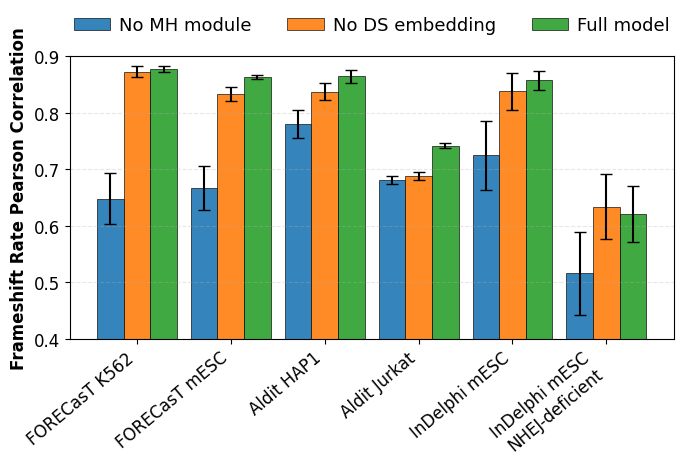

Saved: output\abalation\pearson_comparison_subset_specific.pdf


In [63]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def generate_ablation_plots(selected_datasets=None):
    """
    selected_datasets: List of strings.
    - Legend Renamed: No MH module, No DS embedding, Full model.
    - Narrower layout and larger labels for paper publication.
    """
    
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTTKO",
        3: "Aldit K562", 4: "Aldit K562 DNTTOE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC\nNHEJ-deficient"
    }

    default_table_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTTOE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTTKO",
        "InDelphi mESC", "InDelphi mESC\nNHEJ-deficient", "InDelphi U2OS"
    ]

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }
    
    plot_order = selected_datasets if selected_datasets is not None else default_table_order
    base_folder = 'AB'
    output_folder = os.path.join('output', 'abalation')
    os.makedirs(output_folder, exist_ok=True)
    
    study_folders = sorted([d for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))])
    
    processed_data = {}
    processed_stds = {}

    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            df_mean = pd.read_csv(mean_path)
            df_std = pd.read_csv(std_path)
            
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            
            processed_data[study] = df_mean.set_index('dataset_name').reindex(plot_order).reset_index()
            processed_stds[study] = df_std.set_index('dataset_name').reindex(plot_order).reset_index()

    # --- Plotting Adjustments ---
    num_datasets = len(plot_order)
    num_studies = len(processed_data)
    x = np.arange(num_datasets)
    total_width = 0.85
    bar_width = total_width / num_studies
    
    fig_width = max(6, num_datasets * 1.2) 
    plt.figure(figsize=(fig_width, 5))
    
    for i, study in enumerate(study_folders):
        if study not in processed_data: continue
        
        means = processed_data[study]['Pearson']
        stds = processed_stds[study]['Pearson']
        clean_label = legend_rename.get(study, study)
        
        pos = x - (total_width / 2) + (i * bar_width) + (bar_width / 2)
        plt.bar(pos, means, bar_width, yerr=stds, label=clean_label, capsize=4, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    # Text Formatting
    plt.ylabel('Frameshift Rate Pearson Correlation', fontsize=12, fontweight='bold')
    plt.xticks(x, plot_order, rotation=40, ha='right', fontsize=12, fontweight='medium')
    plt.yticks(fontsize=12)
    
    # --- FIXED LEGEND ---
    # ncol=3 makes it 1 row (shorter top-to-bottom)
    # bbox_to_anchor moves it above the plot
    plt.legend(
        fontsize=13, 
        frameon=False, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=3,
        labelspacing=0.1, # Reduces vertical padding between items (though ncol=3 already does this)
        handletextpad=0.5  # Controls distance between icon and text
    )
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.ylim(0.4, 0.9)
    
    # Added rect to tight_layout to ensure the legend above isn't cut off
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    suffix = "subset" if selected_datasets else "full"
    file_path = os.path.join(output_folder, f'pearson_comparison_{suffix}_specific.pdf')
    plt.savefig(file_path, bbox_inches='tight')
    file_path_2 = os.path.join(output_folder, f'pearson_comparison_{suffix}_specific.svg')
    plt.savefig(file_path_2, bbox_inches='tight')
    plt.show()
    print(f"Saved: {file_path}")

# Run
my_subset = ["FORECasT K562", "FORECasT mESC", "Aldit HAP1", "Aldit Jurkat", "InDelphi mESC", "InDelphi mESC\nNHEJ-deficient"]
generate_ablation_plots(selected_datasets=my_subset)

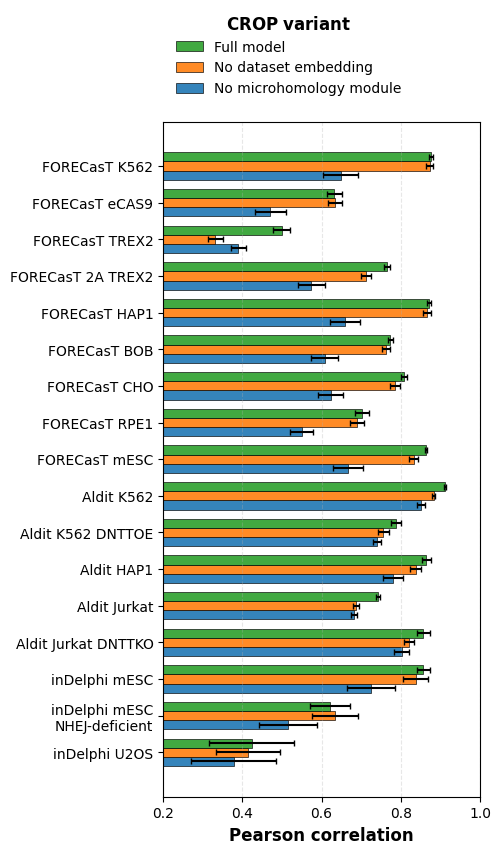

Saved: output\abalation\pearson_comparison_subset_horiz_narrow.svg


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def generate_ablation_plots(selected_datasets=None):
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTTKO",
        3: "Aldit K562", 4: "Aldit K562 DNTTOE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "inDelphi U2OS",
        15: "inDelphi mESC", 16: "inDelphi mESC\nNHEJ-deficient"
    }

    default_table_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTTOE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTTKO",
        "inDelphi mESC", "inDelphi mESC\nNHEJ-deficient", "inDelphi U2OS"
    ]

    legend_rename = {
        'experiment_twoA': 'No microhomology module',
        'experiment_twoB': 'No dataset embedding',
        'experiment_twoORIG': 'Full model'
    }
    
    plot_order = (selected_datasets if selected_datasets is not None else default_table_order)[::-1]
    
    base_folder = 'AB'
    output_folder = os.path.join('output', 'abalation')
    os.makedirs(output_folder, exist_ok=True)
    
    study_folders = sorted([d for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))])
    
    processed_data = {}
    processed_stds = {}

    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            df_mean = pd.read_csv(mean_path)
            df_std = pd.read_csv(std_path)
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            processed_data[study] = df_mean.set_index('dataset_name').reindex(plot_order).reset_index()
            processed_stds[study] = df_std.set_index('dataset_name').reindex(plot_order).reset_index()

    # --- Plotting Adjustments ---
    num_datasets = len(plot_order)
    num_studies = len(processed_data)
    y = np.arange(num_datasets)
    
    total_height = 0.75 
    bar_height = total_height / num_studies
    
    fig_height = max(6, num_datasets * 0.6) 
    plt.figure(figsize=(5, fig_height)) 
    
    for i, study in enumerate(study_folders):
        if study not in processed_data: continue
        
        means = processed_data[study]['Pearson']
        stds = processed_stds[study]['Pearson']
        clean_label = legend_rename.get(study, study)
        
        pos = y - (total_height / 2) + (i * bar_height) + (bar_height / 2)
        plt.barh(pos, means, bar_height, xerr=stds, label=clean_label, capsize=2, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    # Text Formatting
    plt.xlabel('Pearson correlation', fontsize=12, fontweight='bold')
    plt.yticks(y, plot_order, fontsize=10)
    plt.xticks(fontsize=10)
    
    # Get handles and labels to reverse them
    handles, labels = plt.gca().get_legend_handles_labels()

    # --- Legend Above Plot with Title ---
    leg = plt.legend(
        handles[::-1],           # Reverse to match top-to-bottom plot order
        labels[::-1],            # Reverse to match top-to-bottom plot order
        title=r"$\bf{CROP\ variant}$", # Bold title using LaTeX
        fontsize=10, 
        frameon=False, 
        loc='lower left',        
        bbox_to_anchor=(0.0, 1.02), 
        ncol=1                   
    )
    # Alternatively set title font properties explicitly:
    leg.get_title().set_fontsize('12')

    # Important: Increase the top margin so the legend doesn't get cut off
    plt.tight_layout(rect=[0, 0, 1, 0.85])
    
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.xlim(0.2, 1.0)
    
    suffix = "subset_horiz_narrow" if selected_datasets else "full_horiz_narrow"
    file_path = os.path.join(output_folder, f'pearson_comparison_{suffix}.svg')
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {file_path}")

# Run
my_subset = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTTOE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTTKO",
        "inDelphi mESC", "inDelphi mESC\nNHEJ-deficient", "inDelphi U2OS"
    ]
generate_ablation_plots(selected_datasets=my_subset)